[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.pt/cap04/cap04_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:19%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 4 Morfologia Matemática e Segmentação de Imagens

Este capítulo apresenta dois temas fundamentais do Processamento Digital de Imagens (PDI): a **morfologia matemática** e a **segmentação de imagens**. A morfologia matemática fornece um arcabouço teórico baseado na teoria dos conjuntos para analisar, refinar e quantificar a forma de objetos em imagens binárias e em tons de cinza, por meio de operadores fundamentais como **erosão** e **dilatação**. A segmentação, por sua vez, tem como objetivo particionar a imagem em regiões de interesse, separando objetos do fundo e produzindo representações adequadas para análise e interpretação.

O capítulo inicia com a **limiarização**, uma das técnicas mais importantes de segmentação, introduzindo o método automático de **Otsu** e revisitando a análise de histogramas por meio da variância interclasses, apresentada no Capítulo 1. Em seguida, são estudados os principais operadores da morfologia matemática, incluindo erosão, dilatação, abertura, fechamento e reconstrução morfológica, que permitem refinar máscaras binárias e preservar estruturas relevantes dos objetos. Por fim, são apresentadas técnicas de segmentação baseada em regiões, como a **rotulação de componentes conexos**, a **transformada de distância** e o algoritmo ***watershed*** baseado em marcadores, culminando na extração de descritores geométricos e na geração de *bounding boxes* compatíveis com sistemas modernos de detecção de objetos.

## 4.1 Objetivos

Ao final deste capítulo, você será capaz de:

* **Aplicar limiarização:** Compreender o critério automático de Otsu por maximização da variância interclasses ($\sigma_B^2$) e selecionar estratégias adequadas de pré-processamento para facilitar a segmentação;
* **Dominar morfologia binária:** Compreender e aplicar erosão ($A\ominus B$) e dilatação ($A\oplus B$) como operadores fundamentais, derivando abertura ($A\circ B$), fechamento ($A\bullet B$) e operações baseadas em reconstrução morfológica, como `mm.clohole` e `mm.edgeoff`;
* **Aplicar morfologia em tons de cinza:** Utilizar gradiente morfológico e filtros *top-hat* para realce e análise de estruturas locais;
* **Rotular componentes conexos:** Identificar e separar regiões conectadas em imagens binárias por meio de algoritmos de rotulação;
* **Aplicar transformada de distância:** Interpretar e calcular distâncias ao fundo utilizando abordagens morfológicas e métricas geométricas;
* **Segmentar por regiões:** Construir *pipelines* de segmentação baseados em marcadores utilizando Transformada de Distância e o algoritmo ***watershed***;
* **Extrair descritores geométricos:** Calcular propriedades como área, perímetro, centróide, circularidade e *bounding boxes* por meio de `cv2.connectedComponentsWithStats` e `cv2.findContours`;
* **Relacionar PDI e visão computacional:** Compreender como descritores extraídos por segmentação podem ser convertidos para formatos utilizados por detectores modernos, como YOLO.

In [4]:
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup()
from morph import mm
import numpy as np

✅ Ambiente pronto. Morph: 1.1.8 | OpenCV: 5.0.0


## 4.2 Limiarização

A **limiarização** (*thresholding*) é uma das formas mais simples e eficientes de segmentação de imagens. Seu objetivo é classificar cada pixel em duas classes de intensidade, normalmente associadas a *objeto* e *fundo*:

<a id="eq-04-limiar"></a>
$$
g(x,y) =
\begin{cases}
255, & \text{se } f(x,y) > T \\
0,   & \text{caso contrário}
\end{cases} \tag{4.1}
$$


em que $f(x,y)$ representa a intensidade do pixel na imagem original e $g(x,y)$ a imagem binária resultante.

A escolha do limiar $T$ é importante para a qualidade da segmentação. O método de **Otsu** determina automaticamente o limiar ótimo ao maximizar a **variância interclasses** $\sigma_B^2$ e definida por:

<a id="eq-04-otsu"></a>
$$
\sigma_B^2(T) =
w_0(T)\,w_1(T)\,
\bigl[\mu_0(T)-\mu_1(T)\bigr]^2 \tag{4.2}
$$


em que:

- $w_0(T)$ e $w_1(T)$ são as probabilidades acumuladas das classes fundo e objeto;
- $\mu_0(T)$ e $\mu_1(T)$ são as médias de intensidade dessas classes;
- $\sigma_B^2(T)$ representa a variância interclasses para um dado limiar $T$.

O método funciona melhor quando o histograma apresenta dois grupos de intensidades relativamente separados. Para isso, o algoritmo avalia todos os limiares possíveis da imagem — tipicamente no intervalo $[0,255]$ para imagens de 8 bits — e seleciona o valor que maximiza a variância entre classes, denotada por $\sigma_B^2$:

$$
T^* =
\arg\max_{T \in [0,255]}
\sigma_B^2(T)
$$

> ### 📝 Otsu assume histogramas bimodais
>
> O método de Otsu produz melhores resultados quando o histograma apresenta dois picos bem definidos (*bimodalidade*), correspondentes ao fundo e ao objeto. Quanto maior a separação entre esses picos e mais pronunciado o máximo de $\sigma_B^2$, mais confiável tende a ser o limiar obtido.
>
> Em imagens com iluminação não uniforme ou múltiplas regiões de intensidade, técnicas de **limiarização adaptativa** — nas quais o limiar é calculado localmente — costumam produzir segmentações mais robustas.
>
> O índice $B$ em $\sigma_B^2$ significa ***between classes*** (*entre classes*). Assim, $\sigma_B^2$ representa a **variância entre as classes** (*between-class variance*).

### 4.2.1 Imagem de Moedas

A imagem utilizada para praticar a segmentação é uma fotografia de coleção de moedas de diferentes países e épocas ([Figura 4.1](#fig-04-coins)). Crédito: GAZI.MD.AHAD (CC BY-SA 4.0). Ela apresenta objetos circulares com bordas bem definidas, sendo ideal para demonstrar limiarização, operadores morfológicos, transformada de distância, *watershed* e descritores de forma.

Dimensões [y,x,c]: (2560, 1920, 3)


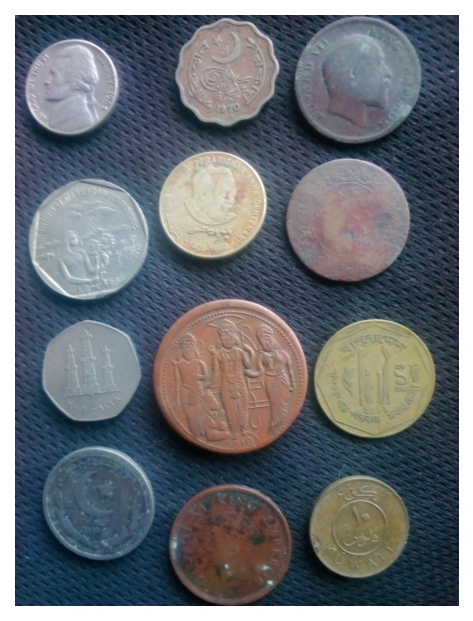

**Figura 4.1:** Imagem com moedas de vários tipos. Crédito: GAZI.MD.AHAD (CC BY-SA 4.0).


In [5]:
import os

url     = "https://upload.wikimedia.org/wikipedia/commons/2/25/GAZI.MD.AHAD_11.jpg"
caminho = "imagens/coins.jpg"

if not os.path.exists(caminho):
    os.makedirs("imagens", exist_ok=True)
    img_obj = mm.read(url, pil=True)
    mm.write(img_obj, caminho)
else:
    img_obj = mm.read(caminho, pil=True)

img_coins_color = np.array(img_obj)
img_coins_gray  = mm.gray(img_coins_color)

print(f"Dimensões [y,x,c]: {img_coins_color.shape}")
mm.show(img_coins_color, scale=30)

### 4.2.2 Escolha do Pré-processamento para o Otsu

A qualidade do método de Otsu depende diretamente de quão **bimodal** é o histograma da imagem de entrada. A imagem original das moedas apresenta iluminação não uniforme e moedas escuras (cobre oxidado) com intensidades próximas às do fundo escuro, tornando o histograma pouco bimodal.

Para minimizar essas limitações, serão avaliadas duas técnicas clássicas de pré-processamento, apresentadas no capítulo anterior, aplicadas antes da etapa de limiarização. A [Tabela 4.1](#tbl-preproc-otsu) resume as características de cada abordagem. Essas técnicas buscam aumentar a separação entre objeto e fundo, tornando o histograma mais próximo de uma distribuição bimodal.

<a id="tbl-preproc-otsu"></a>

**Tabela 4.1:** Técnicas de pré-processamento avaliadas para melhorar a separação entre moedas e fundo antes da aplicação do método de Otsu.

| Técnica | O que faz | Quando usar |
|:--------|:----------|:------------|
| **CLAHE** | Equalização de histograma adaptativa local | Baixo contraste global ou regional |
| **Gaussiano** | Suavização por convolução com gaussiana | Ruído de alta frequência (textura do fundo) |


A função `cv2.createCLAHE(clipLimit, tileGridSize)` divide a imagem em blocos e aplica equalização de histograma em cada um deles, limitando a amplificação de ruído por meio do parâmetro `clipLimit`. Já o filtro Gaussiano (`cv2.GaussianBlur`) suaviza texturas finas que poderiam criar falsos picos no histograma.

Para comparar objetivamente qual pré-processamento produz a melhor entrada para o método de Otsu, serão apresentados, para cada versão da imagem, a própria imagem, o histograma com o limiar ótimo $T^*$ destacado, a curva $\sigma_B^2(T)$ e o resultado da binarização.

> ### 📝 Critério de comparação
>
> A versão que apresentar o maior valor de $\sigma_B^2$ em seu pico fornece a melhor separação entre as classes de fundo e objeto e, consequentemente, a melhor entrada para o método de Otsu ([Figura 4.2](#fig-04-otsu-comparacao-histogramas)).

In [ ]:
import cv2, io
import matplotlib.pyplot as plt

def otsu_criterio(img):
    h=mm.hist(img); p=h/h.sum();                  # histograma e probabilidades
    sigma2=np.zeros(len(p)) 
    for T in range(1,len(p)):                     # percorre limiares
        w0,w1=p[:T].sum(),p[T:].sum()             # probabilidades das classes
        if w0*w1==0: continue                     # evita divisão por zero
        mu0=(np.arange(T)*p[:T]).sum()/w0         # média fundo
        mu1=(np.arange(T,len(p))*p[T:]).sum()/w1  # média objeto
        sigma2[T]=w0*w1*(mu0-mu1)**2              # σ²B(T)
    return sigma2,np.argmax(sigma2)               # curva e T ótimo

def fig2img(fig):
    b=io.BytesIO(); fig.savefig(b,format='png',dpi=100)   # figura → buffer
    plt.close(fig); b.seek(0)
    return np.array(plt.imread(b))                        # buffer → array

def plot_curve(y,T,title,ylabel,color):
    fig,ax=plt.subplots(figsize=(4,3))
    ax.plot(y,color=color) if ylabel=="σ²B" else ax.bar(range(len(y)),y,color=color,width=1)
    ax.axvline(T,color='red',lw=2,label=f"T*={T}")       # limiar ótimo
    ax.set(xlabel="T" if ylabel=="σ²B" else "Intensidade",ylabel=ylabel)
    ax.legend(fontsize=8); plt.tight_layout()
    return fig2img(fig)

# ── Pré-processamentos ───────────────────────────────────────────────────────
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
img_clahe = clahe.apply(img_coins_gray)
img_gauss = cv2.GaussianBlur(img_clahe,(5,5),0)
imgs0=[("Original",img_coins_gray),
       ("CLAHE",img_clahe),
       ("CLAHE+Gauss",img_gauss)]

# ── Tabela comparativa ───────────────────────────────────────────────────────
print(f"{'Versão':<18}{'T*':>6}{'σ²B pico':>14}")
print("-"*40)

imgs,titles=[],[]
for nome,img in imgs0:
    sigma2,T=otsu_criterio(img)                           # calcula σ²B(T)
    print(f"{nome:<18}{T:>6}{sigma2[T]:>14.4e}")
    imgs += [
        img,                                              # imagem
        plot_curve(mm.hist(img),T,f"Hist T*={T}","Freq.","steelblue"),
        plot_curve(sigma2,T,"σ²B(T)","σ²B","darkorange"),
        mm.threshold(img)                                # Otsu final
    ]
    titles += [nome,f"Hist T*={T}","σ²B(T)",f"Otsu T*={T}"]

# ── Exibição final ───────────────────────────────────────────────────────────
mm.show(imgs,titles=titles,cols=4,figsize=(12,12),dpi=200)

**Figura 4.2:** Comparação dos pré-processamentos: imagem | histograma+T* | σ²B(T) | Otsu. A melhor separação bimodal indica o limiar mais confiável.


### 4.2.3 Resultado: CLAHE como Melhor Pré-processamento

A análise da [Figura 4.2](#fig-04-otsu-comparacao-histogramas) indica que o **CLAHE** obteve o maior valor da variância inter-classes ($\sigma_B^2 \approx 2{,}47 \times 10^3$), com limiar ótimo $T^* = 122$. Embora a combinação **CLAHE+Gaussiano** tenha produzido resultado muito semelhante ($\sigma_B^2 \approx 2{,}43 \times 10^3$, $T^* = 123$), o critério quantitativo do método de Otsu favorece ligeiramente o uso do CLAHE isoladamente.

Em termos visuais, as imagens binarizadas obtidas com CLAHE e CLAHE+Gaussiano são praticamente equivalentes. A diferença entre as duas abordagens torna-se mais evidente na análise dos histogramas e dos valores de $\sigma_B^2(T)$ do que na inspeção direta das segmentações resultantes. Assim, a escolha do CLAHE baseia-se principalmente na maximização da separação estatística entre as classes de fundo e objeto.


> ### 💡 Interpretação dos resultados
>
> Observe que os pré-processamentos com CLAHE e CLAHE+Gaussiano produzem histogramas e limiares ótimos muito próximos ($T^*=122$ e $T^*=123$). Consequentemente, as imagens binarizadas resultantes também são bastante semelhantes. Nesse caso, a decisão não é baseada em diferenças visuais marcantes, mas no critério objetivo do método de Otsu: o maior valor de $\sigma_B^2$ indica a melhor separação entre as classes.

## 4.3 Morfologia Matemática

A **morfologia matemática** é uma teoria baseada em conjuntos utilizada para analisar a forma e a estrutura de objetos em imagens. Diferentemente dos filtros lineares apresentados no Capítulo 3, os operadores morfológicos são **não lineares**, pois se baseiam em operações de mínimo, máximo e inclusão espacial, em vez de combinações lineares de intensidades. Esses operadores atuam sobre a vizinhança de cada pixel por meio de um **elemento estruturante** $\mathbb{B}$, responsável por definir a forma e o tamanho da região analisada.

Em imagens binárias e em tons de cinza com elementos planos, o elemento estruturante transladado para a posição $x$ é definido espacialmente como:

$$
\mathbb{B}_x = \{ x + b \mid b \in \mathbb{B} \}
$$

Nas regiões de borda da imagem, parte do conjunto $\mathbb{B}_x$ pode extrapolar o domínio físico da cena ($\mathbb{E}$). Para garantir a consistência matemática dos operadores primitivos nessas fronteiras, assume-se teoricamente que o espaço exterior ao domínio da imagem é preenchido com o **elemento neutro** da operação correspondente (infinito positivo para a erosão e infinito negativo para a dilatação), impedindo que o ambiente externo corrompa as estruturas internas do objeto.

Quando o elemento estruturante associa pesos a seus elementos — isto é, $b: \mathbb{B} \to \mathbb{Z}$ — ele é denominado **função estruturante** ou **elemento estruturante não plano**.

Desenvolvida por Matheron e Serra na década de 1960 para imagens binárias e posteriormente estendida a tons de cinza, a morfologia matemática fundamenta operadores como gradiente morfológico, *top-hat*, *watershed* e transformada de distância, todos derivados de dois primitivos: **erosão** e **dilatação** (MATHERON, 1975; SERRA, 1982).

### 4.3.1 Erosão e Dilatação

Os dois operadores primitivos são definidos de forma unificada para imagens em tons de cinza ($f: \mathbb{E} \to \mathbb{Z}$) e, por restrição ao domínio $\{0,1\}$, também para imagens binárias.


#### 4.3.1.1 Erosão

A **Erosão** de uma imagem $f$ por uma função estruturante $b: \mathbb{B} \to \mathbb{Z}$ é definida formalmente por:

<a id="eq-04-erosao"></a>
$$
\varepsilon_b(f)(x) = (f \ominus b)(x) = \min_{z \in \mathbb{B}}\{\, f(x + z) - b(z) \,\}, \quad \forall\, x \in \mathbb{E} \tag{4.3}
$$


Na prática, a erosão substitui a intensidade do pixel $x$ pelo mínimo valor resultante da diferença entre a imagem e o elemento estruturante na vizinhança definida pelo domínio $\mathbb{B}$. Valores positivos nos pesos de $b(z)$ forçam o resultado local para baixo, "cavando" o relevo da imagem mais profundamente e intensificando a erosão. 

No caso **plano** (onde os pesos são nulos dentro do domínio, ou seja, $b \equiv 0$), a expressão simplifica-se para o mínimo local puro:

$$
\varepsilon_B(f)(x) = \min\{\, f(y) : y \in \mathbb{B}_x \,\}
$$

Em imagens binárias, essa operação equivale a exigir que o conjunto $\mathbb{B}$, transladado para a coordenada $x$, esteja **completamente contido** no objeto $A$:

$$
A \ominus \mathbb{B} = \{\, z \in \mathbb{E} \mid \mathbb{B}_z \subseteq A \,\}
$$

**Efeito Visual:** *Encolhe* objetos e estruturas claras, eliminando protuberâncias, picos brilhantes ou ruídos que sejam geometricamente menores que o domínio $\mathbb{B}$.



#### 4.3.1.2 Implementação da erosão

A versão didática `mm.ero0` implementa o caso particular de erosão com **elemento estruturante plano**. Para cada pixel $(y,x)$, a função percorre os vizinhos espaciais permitidos por $B$ e armazena o menor valor encontrado na imagem de entrada $f$, reproduzindo diretamente a operação de mínimo local descrita na [Equação 4.3](#eq-04-erosao) para $b \equiv 0$.

Observe que os valores dos vizinhos são sempre lidos de forma estática da imagem original $f$; a matriz de saída $g$ é utilizada exclusivamente para registrar o mínimo acumulado da vizinhança corrente. Dessa forma, o resultado final é invariante em relação à ordem de varredura dos pixels (seja por linhas ou colunas).

A função auxiliar `_viz` calcula as coordenadas dos vizinhos válidos dentro dos limites físicos da imagem. Nas bordas, a inicialização do acumulador em `255` emula com exatidão o preenchimento por elemento neutro exigido pela teoria. Já a função de interface `mm.ero` recorre à implementação nativa e otimizada do OpenCV (`cv2.erode`) quando o elemento estruturante é plano, chaveando para a rotina geral `mm.ero1` caso o elemento possua pesos topográficos.

O exemplo computacional a seguir ilustra a aplicação de um elemento estruturante em cruz (`mm.secross()`) em destaque na [Figura 4.3](#fig-04-elemento-cruz), comparando a execução da variante didática em laço (`mm.ero0`) com o motor computacional do OpenCV (`mm.ero`).

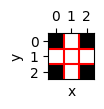

**Figura 4.3:** Elemento estruturante em formato de cruz ($B_{\\text{cruz}}$) utilizado para conectividade-4.


In [ ]:
B_cruz = mm.secross()
mm.drawImgPlt(B_cruz, scale=20)

In [ ]:
def _viz(f, B, y, x):
    """Gera (vy, vx, b_val) para cada vizinho válido de (y,x)."""
    H, W = f.shape
    Bh, Bw = B.shape
    oh, ow = -Bh/2 + 0.5, -Bw/2 + 0.5  # offsets fixos
    for by, bx in np.ndindex(Bh, Bw):
        vy, vx = int(y + by + oh), int(x + bx + ow)
        if 0 <= vy < H and 0 <= vx < W:
            yield vy, vx, B[by, bx]

def ero(f, Bc=np.zeros((3,3),dtype='uint8')):
    """Erosão (OpenCV ou com pesos)."""
    try:    return cv2.erode(f, Bc)
    except: return mm.ero1(f, Bc)

def ero0(f, Bc=np.ones((3,3),dtype='uint8')):
    """Erosão clássica sem pesos."""
    g = np.empty_like(f)
    for y in range(f.shape[0]):
        for x in range(f.shape[1]):
            g[y,x] = 255
            for vy,vx,bv in mm._viz(f,Bc,y,x):
                if bv and g[y,x] > f[vy,vx]: g[y,x] = f[vy,vx]
    return g

# Script de Teste e Validação
B = mm.secross()
print("Elemento estruturante B:")
print(mm.drawImage(B))

f = mm.randomImage(5,5)
print("Imagem original f:")
print(mm.drawImage(f))

print("Erosão Plana Didática (ero0):")
print(mm.drawImage(ero0(f, B)))

print("Erosão Otimizada OpenCV (ero):")
print(mm.drawImage(ero(f, B)))

Elemento estruturante B:
0 1 0 
1 1 1 
0 1 0 

Imagem original f:
7 9 2 7 3 
1 9 1 9 4 
6 2 9 3 5 
4 5 4 9 0 
8 3 1 8 5 

Erosão Plana Didática (ero0):
1 2 1 2 3 
1 1 1 1 3 
1 2 1 3 0 
4 2 1 0 0 
3 1 1 1 0 

Erosão Otimizada OpenCV (ero):
1 2 1 2 3 
1 1 1 1 3 
1 2 1 3 0 
4 2 1 0 0 
3 1 1 1 0 



A função `_viz` utiliza `yield` para gerar cada vizinho sob demanda, sem armazenar todos os resultados em memória em uma lista. No experimento abaixo, uma janela de 3000×3000 produz 9 milhões de vizinhos. A implementação baseada em lista consumiu mais de 1 GB de RAM e levou aproximadamente 46 s, enquanto a versão com `yield` consumiu memória desprezível e executou em 38 s. Em processamento de imagens, geradores são especialmente úteis para percorrer grandes vizinhanças de forma eficiente.

In [ ]:
import tracemalloc

def lista(n): return [(i, i) for i in range(n)]
def gera(n):
    for i in range(n): yield i, i

for nome, f in [("LISTA", lista), ("YIELD", gera)]:
    tracemalloc.start()
    sum(x+y for x,y in f(9_000_000))
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"{nome}: {pico/1024/1024:.1f} MB")

LISTA: 830.8 MB
YIELD: 0.0 MB


#### 4.3.1.3 Dilatação

A **Dilatação** de uma imagem $f$ por uma função estruturante $b: \mathbb{B} \to \mathbb{Z}$ é definida formalmente por:

<a id="eq-04-dilatacao"></a>
$$
\delta_b(f)(x) = (f \oplus b)(x) = \max_{z \in \mathbb{B}}\{\, f(x - z) + b(z) \,\}, \quad \forall\, x \in \mathbb{E} \tag{4.4}
$$


Na prática, a dilatação substitui a intensidade do pixel $x$ pelo maior valor resultante da soma entre a imagem e o elemento estruturante na vizinhança definida. O argumento de inversão espacial ($x - z$) indica que a dilatação avalia implicitamente o elemento transposto (refletido) $\hat{b}$, propriedade fundamental para assegurar a dualidade matemática em relação à erosão.

No caso **plano** (onde os pesos são nulos dentro do domínio, ou seja, $b \equiv 0$), a expressão reduz-se ao máximo local puro:

$$
\delta_B(f)(x) = \max\{\, f(y) : y \in \mathbb{B}_x \,\}
$$

Em imagens binárias, essa operação equivale a exigir que o conjunto refletido $\hat{\mathbb{B}}$, transladado para a coordenada $x$, possua **interseção não vazia** com o objeto $A$:

$$
A \oplus \mathbb{B} = \{\, z \in \mathbb{E} \mid \hat{\mathbb{B}}_z \cap A \neq \varnothing \,\}
$$

**Efeito Visual:** *Expande* as estruturas claras da imagem, aumentando o preenchimento de objetos, conectando componentes próximos e eliminando canais, fossas escuras ou vales que sejam geometricamente menores que o domínio $\mathbb{B}$.




#### 4.3.1.4 Implementação da dilatação

A versão didática `mm.dil0` implementa o caso particular de dilatação com **elemento estruturante plano**. Para cada pixel $(y,x)$, a função percorre os vizinhos espaciais permitidos por $B$ e armazena o maior valor encontrado na imagem de entrada $f$, reproduzindo diretamente a operação de máximo local para $b \equiv 0$.

Antes de iniciar a varredura espacial, o elemento estruturante sofre uma reflexão geométrica por meio da instrução `np.flip(Bc)` para construir explicitamente a matriz transposta $\hat{B}$ exigida pela teoria. Em máscaras perfeitamente simétricas (como cruzes, quadrados e discos centrados na origem), essa reflexão não altera o arranjo dos pixels; contudo, para elementos assimétricos, tal etapa é estritamente necessária para garantir a equivalência com as definições formais e salvaguardar as leis de dualidade.

Assim como verificado no operador de erosão, os valores dos vizinhos são sempre lidos de forma estática a partir da matriz original $f$, enquanto a matriz de saída $g$ atua puramente como o registrador do máximo acumulado da vizinhança. Nas fronteiras da imagem, a inicialização do acumulador em `0` emula com exatidão o preenchimento externo por elemento neutro ($-\infty$, ou zero em representações de 8 bits), garantindo que as bordas físicas da cena sejam dilatadas em perfeita conformidade com o padrão adotado pelo OpenCV.

O exemplo computacional abaixo ilustra a aplicação prática de um elemento em cruz (`mm.secross()`), validando a consistência entre a lógica em laços (`mm.dil0`) e o método nativo industrial (`mm.dil`).

In [ ]:
def dil(f, Bc=np.zeros((3,3),dtype='uint8')):
    """Dilatação (OpenCV ou com pesos)."""
    try:    return cv2.dilate(f, Bc)
    except: return mm.dil1(f, Bc)

def dil0(f, Bc=np.zeros((3,3),dtype='uint8')):
    """Dilatação plana seguindo rigorosamente a teoria."""
    g = np.empty_like(f) 
    Bc = np.flip(Bc)     # reflexão explícita: B̂
    for y in range(f.shape[0]):
        for x in range(f.shape[1]):
            g[y,x] = 0 # Inicializa com o valor mínimo para buscar o máximo
            for vy,vx,bv in mm._viz(f,Bc,y,x):
                if bv and g[y,x] < f[vy,vx]:
                    g[y,x] = f[vy,vx]
    return g

# Script de Teste e Validação
B = mm.secross()
print("Elemento estruturante B:")
print(mm.drawImage(B))

f = mm.randomImage(5,5)
print("Imagem original f:")
print(mm.drawImage(f))

print("Dilatação Plana Didática (dil0):")
print(mm.drawImage(dil0(f, B)))

print("Dilatação Otimizada OpenCV (dil):")
print(mm.drawImage(dil(f, B)))

Elemento estruturante B:
0 1 0 
1 1 1 
0 1 0 

Imagem original f:
4 1 9 3 3 
4 8 2 3 4 
1 0 1 1 2 
2 8 1 2 2 
9 7 5 6 3 

Dilatação Plana Didática (dil0):
4 9 9 9 4 
8 8 9 4 4 
4 8 2 3 4 
9 8 8 6 3 
9 9 7 6 6 

Dilatação Otimizada OpenCV (dil):
4 9 9 9 4 
8 8 9 4 4 
4 8 2 3 4 
9 8 8 6 3 
9 9 7 6 6 



> ### 📝 Nota: O Confronto dos Sinais ($f(x+z)$ vs $f(x-z)$)
>
> Compare as definições formais da erosão ([Equação 4.3](#eq-04-erosao)) e da dilatação ([Equação 4.4](#eq-04-dilatacao)). Considere um elemento estruturante assimétrico à direita $\mathbb{B}=\{0,1\}$ (origem e um pixel à direita) aplicado na posição $x=10$.
>
> 1. **Na Erosão** ([Equação 4.3](#eq-04-erosao)):
>
>    $$
>    \min\{f(x+z)-b(z)\}
>    $$
>
>    * $z=0 \Rightarrow f(10+0)=\mathbf{f(10)}$
>    * $z=1 \Rightarrow f(10+1)=\mathbf{f(11)}$
>
>    O operador consulta o pixel atual ($10$) e o pixel à direita ($11$), preservando a orientação original de $\mathbb{B}$.
>
> 2. **Na Dilatação** ([Equação 4.4](#eq-04-dilatacao)):
>
>    $$
>    \max\{f(x-z)+b(z)\}
>    $$
>
>    * $z=0 \Rightarrow f(10-0)=\mathbf{f(10)}$
>    * $z=1 \Rightarrow f(10-1)=\mathbf{f(9)}$
>
>    Devido ao sinal negativo ($-z$), avançar no elemento estruturante corresponde a recuar na imagem, fazendo com que a dilatação consulte o pixel à esquerda ($9$).
>
> A função `_viz`, utilizada em `morph.py`, gera vizinhos por deslocamentos aditivos da forma $x+z$. Por esse motivo, a implementação de `mm.dil0` reflete previamente o elemento estruturante por meio de `np.flip(B)`. Após a reflexão, a varredura baseada em $x+z$ passa a acessar exatamente os mesmos pontos definidos pela expressão teórica $f(x-z)$ da dilatação em [Equação 4.4](#eq-04-dilatacao).
>
> Para elementos estruturantes simétricos (como discos, quadrados e cruzes centradas), a reflexão não altera a máscara. Já para elementos assimétricos, essa etapa é indispensável para que a implementação reproduza corretamente a definição matemática da dilatação e preserve a dualidade erosão–dilatação.

> ### 📝 Dualidade erosão–dilatação
>
> Erosão e dilatação são **duais pelo complemento**. Isso significa que um operador pode ser completamente obtido a partir do outro, desde que se atue sobre o complemento da imagem utilizando o elemento estruturante refletido $\hat{B}$:
>
> $$
> (A \ominus B)^c = A^c \oplus \hat{B} \quad \Longleftrightarrow \quad A \ominus B = (A^c \oplus \hat{B})^c
> $$
>
> De forma análoga, a **dilatação também pode ser obtida a partir da erosão**:
>
> $$
> (A \oplus B)^c = A^c \ominus \hat{B} \quad \Longleftrightarrow \quad A \oplus B = (A^c \ominus \hat{B})^c
> $$
>
> Em termos práticos, a erosão de um objeto pode ser obtida pela dilatação de seu complemento, seguida da complementação do resultado (e vice-versa). Na implementação do pacote `morph.py`, as versões didáticas `mm.ero0` e `mm.dil0` tornam explícita essa estrutura por meio de laços (*loops*), enquanto `mm.ero` e `mm.dil` delegam as operações ao OpenCV visando maior eficiência computacional.

> ### 📝 Condições de contorno e imagens finitas
>
> Na morfologia matemática clássica, definida sobre um domínio infinito (tipicamente $\mathbb{Z}^2$), essa dualidade é exata. Em imagens digitais, entretanto, trabalha-se com matrizes finitas, e o resultado passa a depender da forma como são tratados os pixels localizados fora da imagem.
>
> Para que as identidades de dualidade permaneçam válidas, o complemento deve ser definido em relação ao mesmo universo e as condições de contorno adotadas para a erosão e para a dilatação devem ser complementares entre si. Por exemplo, se a erosão assume que os pixels externos pertencem ao objeto ($255$), então a dilatação aplicada ao complemento deve assumir que esses mesmos pixels externos pertencem ao fundo ($0$).
>
> Quando diferentes estratégias de preenchimento são utilizadas (replicação, reflexão, valor constante etc.), a dualidade teórica pode deixar de ser satisfeita exatamente nas regiões próximas às bordas da imagem.

Para ilustrar numericamente os operadores morfológicos e a dualidade erosão–dilatação, a [Figura 4.4](#fig-04-ero-dil-didatico) apresenta uma imagem binária 10×10 processada com um elemento estruturante em formato de "L". Na implementação de `morph.py`, a origem de $B$ é fixada no centro geométrico da máscara — posição $(1,1)$ para um *kernel* 3×3 — e deve corresponder a um elemento ativo para que a erosão se comporte corretamente (conforme discutido anteriormente). O elemento estruturante $B_L$ definido a seguir satisfaz essa condição. A [Figura 4.5](#fig-04-sim-04-erosao) complementa a análise com um simulador interativo da erosão, permitindo visualizar o deslocamento do elemento estruturante sobre a imagem e identificar as posições em que ele permanece completamente contido no objeto.

Elemento estruturante B_L:
1 0 0 
1 1 0 
1 1 0 

Elemento estruturante refletido B̂:
0 1 1 
0 1 1 
0 0 1 

Dualidade (A ⊖ B)^c == A^c ⊕ B̂ : True


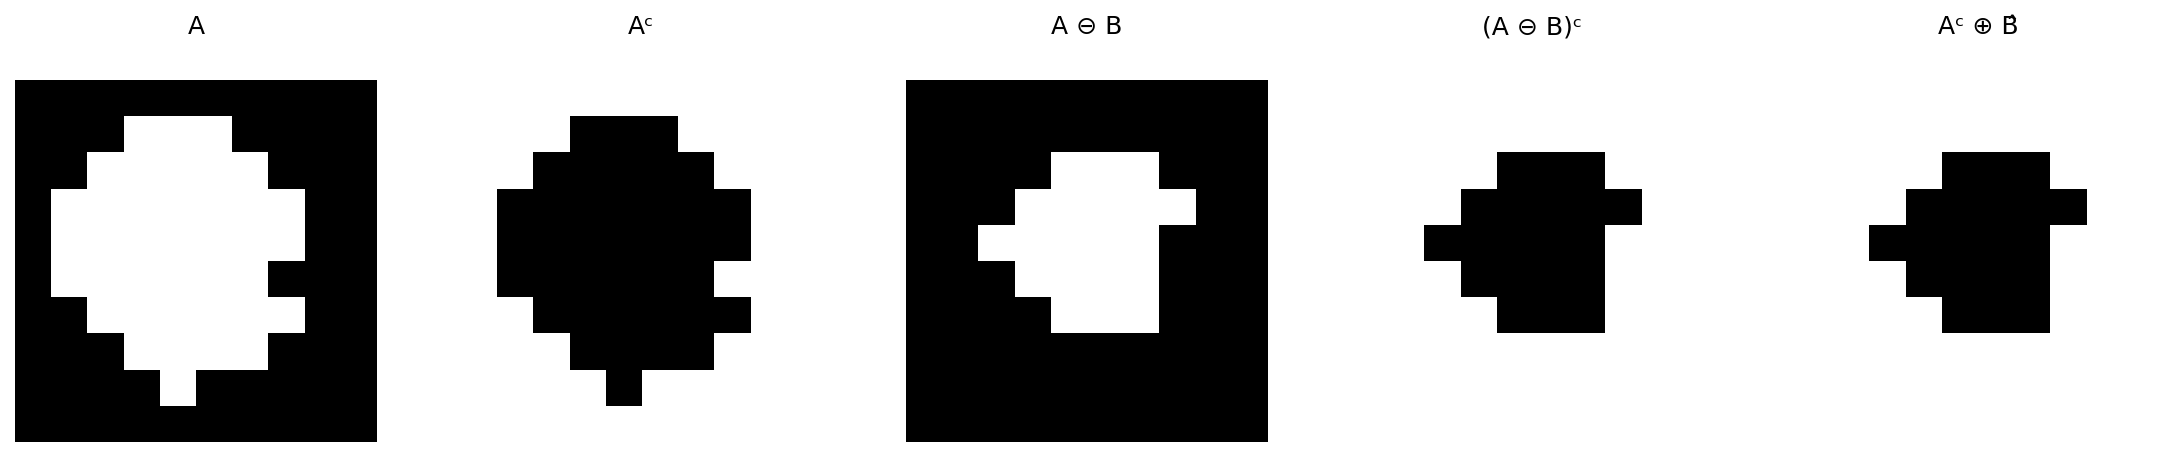

**Figura 4.4:** Erosão e dilatação em imagem binária 10×10 com elemento estruturante 


In [ ]:
A = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0,0],
    [0,0,1,1,1,1,1,0,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

B_L = np.array([[1,0,0],
                [1,1,0],
                [1,1,0]], dtype=np.uint8)   # origem no centro (1,1), elemento ativo

# Elemento estruturante refletido B̂
B_hat = np.flip(B_L)
print("Elemento estruturante B_L:")
print(mm.drawImg(B_L))
print("Elemento estruturante refletido B̂:")
print(mm.drawImg(B_hat))    

# Erosão de A por B_L
img_ero0 = mm.ero0(A, B_L)

# Validação da dualidade: (A ⊖ B)^c = A^c ⊕ B̂
A_c   = 255 - A           # complemento de A
ero_c = 255 - img_ero0    # complemento da erosão — lado esquerdo
dil_Ac = mm.dil0(A_c, B_hat)             # lado direito

dualidade_ok = np.array_equal(ero_c, dil_Ac)
print(f"Dualidade (A ⊖ B)^c == A^c ⊕ B̂ : {dualidade_ok}")
# Transposto (reflexão em ambos os eixos): B̂ usado na dilatação da dualidade
B_hat = np.flip(B_L)
mm.show(
    [A, A_c, img_ero0, ero_c, dil_Ac],
    titles=["A", "Aᶜ", "A ⊖ B", "(A ⊖ B)ᶜ", "Aᶜ ⊕ B̂"],
    cols=5,
    figsize=(15, 3)
)

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-erosao" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🪨 Simulador: Erosão Morfológica</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">A ⊖ B_L · offsets via _viz</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    <p style="font-size:11px;color:#777;margin-bottom:12px;text-align:center;">Clique numa célula do canvas para mover o kernel B_L ou utilize os controles deslizantes para testar a inclusão de contidos.</p>

    <!-- Estatísticas Principais -->
    <div style="display:grid;grid-template-columns:repeat(3, minmax(0, 1fr));gap:10px;margin-bottom:16px;text-align:center;">
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:8px;padding:8px 10px;">
        <div style="font-size:9.5px;color:#8a8371;text-transform:uppercase;margin-bottom:2px;">Posição X (col)</div>
        <div id="sim-04-erosao_mX" style="font-size:16px;font-weight:700;font-family:monospace;color:#2980b9;">4</div>
      </div>
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:8px;padding:8px 10px;">
        <div style="font-size:9.5px;color:#8a8371;text-transform:uppercase;margin-bottom:2px;">Posição Y (lin)</div>
        <div id="sim-04-erosao_mY" style="font-size:16px;font-weight:700;font-family:monospace;color:#2980b9;">4</div>
      </div>
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:8px;padding:8px 10px;">
        <div style="font-size:9.5px;color:#8a8371;text-transform:uppercase;margin-bottom:2px;">Pixel Erosão</div>
        <div id="sim-04-erosao_mEro" style="font-size:16px;font-weight:700;font-family:monospace;color:#27ae60;">255</div>
      </div>
    </div>

    <!-- Área Gráfica e Controles Lado a Lado -->
    <div style="display:grid;grid-template-columns:repeat(auto-fit, minmax(260px, 1fr));gap:16px;align-items:start;margin-bottom:14px;">
      
      <!-- Canvas Interativo -->
      <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
        <canvas id="sim-04-erosao_Canvas" style="display:block;max-width:100%;height:auto;border-radius:8px;border:1px solid #e4dcc8;cursor:crosshair;background:#ffffff;margin:0 auto;"></canvas>
        <div style="font-size:10px;color:#8a8371;margin-top:8px;">🖱️ Clique numa célula para mover o kernel B_L</div>
      </div>

      <!-- Painel de Controles e Status -->
      <div style="display:flex;flex-direction:column;gap:12px;">
        
        <!-- Status de Inclusão -->
        <div id="sim-04-erosao_stBox" style="border-radius:10px;border:1.5px solid #27ae60;padding:10px 12px;background:#eafaf1;transition:all 0.15s ease;">
          <div style="display:flex;align-items:center;gap:8px;margin-bottom:4px;">
            <span style="font-size:16px;">🟢</span>
            <div id="sim-04-erosao_stTitle" style="font-size:11px;font-weight:700;color:#27ae60;">Sucesso: contido!</div>
          </div>
          <div id="sim-04-erosao_stDesc" style="font-size:10.5px;color:#27ae60;line-height:1.4;">Pixel recebe 1 (255) na imagem erodida.</div>
        </div>

        <!-- Sliders de Posição -->
        <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:10px;padding:10px 12px;">
          <span style="font-size:10px;font-weight:700;color:#5e5a4a;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:8px;">Controles de Coordenada</span>
          <div style="display:flex;align-items:center;gap:8px;margin-bottom:6px;">
            <label for="sim-04-erosao_slX" style="font-size:10.5px;color:#8a8371;width:40px;flex-shrink:0;">X (col)</label>
            <input type="range" id="sim-04-erosao_slX" min="0" max="9" step="1" value="4" style="flex:1;cursor:pointer;">
            <span id="sim-04-erosao_vX" style="font-size:11px;font-family:monospace;font-weight:700;min-width:14px;text-align:right;">4</span>
          </div>
          <div style="display:flex;align-items:center;gap:8px;">
            <label for="sim-04-erosao_slY" style="font-size:10.5px;color:#8a8371;width:40px;flex-shrink:0;">Y (lin)</label>
            <input type="range" id="sim-04-erosao_slY" min="0" max="9" step="1" value="4" style="flex:1;cursor:pointer;">
            <span id="sim-04-erosao_vY" style="font-size:11px;font-family:monospace;font-weight:700;min-width:14px;text-align:right;">4</span>
          </div>
        </div>

        <button id="sim-04-erosao_rstBtn" style="padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:9px;width:100%;transition:all 0.15s ease;">↩ Resetar Posição (4, 4)</button>

        <!-- Kernel B_L Informativo -->
        <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:10px;padding:10px 12px;text-align:center;">
          <span style="font-size:10px;font-weight:700;color:#5e5a4a;letter-spacing:.3px;text-transform:uppercase;display:block;margin-bottom:8px;">Kernel B_L (3×3)</span>
          <div style="display:inline-grid;grid-template-columns:repeat(3, 30px);gap:2px;margin-bottom:6px;justify-content:center;">
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fef5e7;border:1px solid #f8c471;border-radius:4px;color:#b9770e;">1</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fafaf7;border:1px solid #e4dcc8;border-radius:4px;color:#8a8371;">0</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fafaf7;border:1px solid #e4dcc8;border-radius:4px;color:#8a8371;">0</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fef5e7;border:1px solid #f8c471;border-radius:4px;color:#b9770e;">1</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#ebf4fd;border:1px solid #2980b9;border-radius:4px;color:#2980b9;">★</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fafaf7;border:1px solid #e4dcc8;border-radius:4px;color:#8a8371;">0</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fef5e7;border:1px solid #f8c471;border-radius:4px;color:#b9770e;">1</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fef5e7;border:1px solid #f8c471;border-radius:4px;color:#b9770e;">1</div>
            <div style="width:30px;height:30px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:700;background:#fafaf7;border:1px solid #e4dcc8;border-radius:4px;color:#8a8371;">0</div>
          </div>
          <div id="sim-04-erosao_offsetInfo" style="font-size:10px;font-family:monospace;color:#5e5a4a;line-height:1.5;background:#ffffff;border:1px solid #e4dcc8;border-radius:6px;padding:6px 8px;margin-top:6px;text-align:left;"></div>
        </div>

      </div>

    </div>

  </div>
</div>

<script>
(function(){
  function initSim04Ero(root){
    if (!root || root.dataset.sim04EroInit) return;
    root.dataset.sim04EroInit = "1";

    const ero_COLS = 10, ero_ROWS = 10, ero_CELL = 32, ero_PAD = 14;
    const ero_W = ero_COLS * ero_CELL + ero_PAD * 2, ero_H = ero_ROWS * ero_CELL + ero_PAD * 2;
    const ero_cv = root.querySelector('#sim-04-erosao_Canvas');
    ero_cv.width = ero_W; 
    ero_cv.height = ero_H;
    const ero_ctx = ero_cv.getContext('2d');

    const ero_A = [
      [0,0,0,0,0,0,0,0,0,0],
      [0,0,0,1,1,1,0,0,0,0],
      [0,0,1,1,1,1,1,0,0,0],
      [0,1,1,1,1,1,1,1,0,0],
      [0,1,1,1,1,1,1,1,0,0],
      [0,1,1,1,1,1,1,0,0,0],
      [0,0,1,1,1,1,1,1,0,0],
      [0,0,0,1,1,1,1,0,0,0],
      [0,0,0,0,1,0,0,0,0,0],
      [0,0,0,0,0,0,0,0,0,0]
    ];

    const ero_B = [
      [1,0,0],
      [1,1,0],
      [1,1,0]
    ];
    const ero_Bh = 3, ero_Bw = 3;

    function ero_vizOffsets(){
      const offs = [];
      for(let by=0; by<ero_Bh; by++) {
        for(let bx=0; bx<ero_Bw; bx++){
          const dr = by - Math.floor(ero_Bh/2);
          const dc = bx - Math.floor(ero_Bw/2);
          offs.push({dr, dc, bv: ero_B[by][bx], by, bx});
        }
      }
      return offs;
    }
    
    const ero_OFFSETS = ero_vizOffsets();
    const ero_ACTIVE  = ero_OFFSETS.filter(o => o.bv === 1);
    const ero_INACTIVE= ero_OFFSETS.filter(o => o.bv === 0);

    function ero_computeEro(){
      const e = Array.from({length:ero_ROWS}, () => new Array(ero_COLS).fill(0));
      for(let y=0; y<ero_ROWS; y++) {
        for(let x=0; x<ero_COLS; x++) {
          let ok = true;
          for(const {dr,dc,bv} of ero_OFFSETS){
            if(!bv) continue;
            const vy = y + dr, vx = x + dc;
            if(vy < 0 || vy >= ero_ROWS || vx < 0 || vx >= ero_COLS || !ero_A[vy][vx]) { 
              ok = false; 
              break; 
            }
          }
          e[y][x] = ok ? 1 : 0;
        }
      }
      return e;
    }
    
    const ero_ERO = ero_computeEro();
    let ero_cx = 4, ero_cy = 4;

    function ero_updateOffsetInfo(){
      const lines = ero_ACTIVE.map(o => {
        const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
        const inBounds = vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS;
        const inA = inBounds && ero_A[vy][vx];
        const mark = inA ? '✓' : '✗';
        return 'B[' + o.by + '][' + o.bx + '] → (' + vy + ',' + vx + ') ' + mark;
      });
      
      root.querySelector('#sim-04-erosao_offsetInfo').innerHTML =
        '<span style="color:#8a8371; font-size:9.5px">offsets ativos @ (y=' + ero_cy + ', x=' + ero_cx + '):</span><br>' +
        lines.map(l => '<span style="color:' + (l.endsWith('✓') ? '#27ae60' : '#c0392b') + '">' + l + '</span>').join('<br>');
    }

    function ero_draw(){
      ero_ctx.clearRect(0, 0, ero_W, ero_H);

      const activeMap = new Map();
      for(const o of ero_ACTIVE){
        const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
        if(vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS) activeMap.set(vy + ',' + vx, ero_A[vy][vx]);
      }
      const inactiveSet = new Set();
      for(const o of ero_INACTIVE){
        const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
        if(vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS) inactiveSet.add(vy + ',' + vx);
      }

      const contained = ero_ACTIVE.every(o => {
        const vy = ero_cy + o.dr, vx = ero_cx + o.dc;
        return vy >= 0 && vy < ero_ROWS && vx >= 0 && vx < ero_COLS && ero_A[vy][vx];
      });

      for(let r=0; r<ero_ROWS; r++) {
        for(let c=0; c<ero_COLS; c++) {
          const x = ero_PAD + c * ero_CELL, y = ero_PAD + r * ero_CELL;
          const key = r + ',' + c;
          const isActive = activeMap.has(key);
          const isInactive = !isActive && inactiveSet.has(key);
          const isCenter = r === ero_cy && c === ero_cx;
          const inA = ero_A[r][c];
          const inE = ero_ERO[r][c];
          
          let fill, stroke, lw=0.5, dash=[];

          if(isActive){
            const inside = activeMap.get(key);
            fill = inside ? 'rgba(243, 156, 18, 0.35)' : 'rgba(192, 57, 43, 0.35)';
            stroke = inside ? '#b9770e' : '#c0392b';
            lw = 2;
          } else if(isCenter){
            fill = 'rgba(41, 128, 185, 0.25)';
            stroke = '#2980b9'; lw = 2; dash = [4,3];
          } else if(isInactive){
            fill = 'rgba(235, 244, 253, 0.4)';
            stroke = '#b9770e'; lw = 1; dash = [3,3];
          } else if(inE){
            fill = 'rgba(39, 174, 96, 0.15)';
            stroke = '#27ae60';
          } else if(inA){
            fill = 'rgba(142, 68, 173, 0.15)';
            stroke = '#8e44ad';
          } else {
            fill = '#fafaf7';
            stroke = '#e4dcc8';
          }

          ero_ctx.setLineDash(dash);
          ero_ctx.fillStyle = fill; 
          ero_ctx.fillRect(x+1, y+1, ero_CELL-2, ero_CELL-2);
          ero_ctx.strokeStyle = stroke; 
          ero_ctx.lineWidth = lw; 
          ero_ctx.strokeRect(x+0.5, y+0.5, ero_CELL-1, ero_CELL-1);
          ero_ctx.setLineDash([]);

          ero_ctx.textAlign = 'center'; 
          ero_ctx.textBaseline = 'middle';
          
          if(isCenter && !isActive){
            ero_ctx.fillStyle = '#2980b9';
            ero_ctx.font = '13px monospace';
            ero_ctx.fillText('★', x+ero_CELL/2, y+ero_CELL/2);
          } else if(isActive){
            const inside = activeMap.get(key);
            ero_ctx.fillStyle = inside ? '#7d5a00' : '#78281f';
            ero_ctx.font = 'bold 11px monospace';
            ero_ctx.fillText(inA ? '1' : '0', x+ero_CELL/2, y+ero_CELL/2);
          } else if(inA){
            ero_ctx.fillStyle = '#4a235a';
            ero_ctx.font = '11px monospace';
            ero_ctx.fillText('1', x+ero_CELL/2, y+ero_CELL/2);
          } else {
            ero_ctx.fillStyle = '#8a8371';
            ero_ctx.font = '11px monospace';
            ero_ctx.fillText('0', x+ero_CELL/2, y+ero_CELL/2);
          }

          if(r===0){ero_ctx.fillStyle='#8a8371'; ero_ctx.font='9px monospace'; ero_ctx.textAlign='center'; ero_ctx.fillText(c, x+ero_CELL/2, ero_PAD/2);}
          if(c===0){ero_ctx.fillStyle='#8a8371'; ero_ctx.font='9px monospace'; ero_ctx.textAlign='center'; ero_ctx.fillText(r, ero_PAD/2, y+ero_CELL/2);}
        }
      }

      root.querySelector('#sim-04-erosao_mX').textContent = ero_cx;
      root.querySelector('#sim-04-erosao_mY').textContent = ero_cy;
      const ev = ero_ERO[ero_cy][ero_cx];
      const mEro = root.querySelector('#sim-04-erosao_mEro');
      mEro.textContent = ev ? '255' : '0';
      mEro.style.color = ev ? '#27ae60' : '#c0392b';
      root.querySelector('#sim-04-erosao_vX').textContent = ero_cx;
      root.querySelector('#sim-04-erosao_vY').textContent = ero_cy;
      root.querySelector('#sim-04-erosao_slX').value = ero_cx;
      root.querySelector('#sim-04-erosao_slY').value = ero_cy;

      const box = root.querySelector('#sim-04-erosao_stBox');
      const title = root.querySelector('#sim-04-erosao_stTitle');
      const desc = root.querySelector('#sim-04-erosao_stDesc');
      
      if(contained){
        box.style.background = '#eafaf1'; box.style.borderColor = '#27ae60';
        title.textContent = 'Sucesso: contido!'; title.style.color = '#27ae60';
        desc.textContent = 'Pixel recebe 1 (255) na imagem erodida.'; desc.style.color = '#27ae60';
      } else {
        box.style.background = '#fdecea'; box.style.borderColor = '#c0392b';
        title.textContent = 'Aviso: B_L sai do objeto!'; title.style.color = '#c0392b';
        desc.textContent = 'Pixel recebe 0 na imagem erodida.'; desc.style.color = '#c0392b';
      }
      
      ero_updateOffsetInfo();
    }

    ero_cv.addEventListener('click', function(e){
      const rect = ero_cv.getBoundingClientRect();
      const sx = ero_W / rect.width, sy = ero_H / rect.height;
      const c = Math.floor(((e.clientX - rect.left) * sx - ero_PAD) / ero_CELL);
      const r = Math.floor(((e.clientY - rect.top) * sy - ero_PAD) / ero_CELL);
      if(c >= 0 && c < ero_COLS && r >= 0 && r < ero_ROWS){
        ero_cx = c; ero_cy = r; 
        ero_draw();
      }
    });
    
    root.querySelector('#sim-04-erosao_slX').addEventListener('input', function(){ ero_cx = +this.value; ero_draw(); });
    root.querySelector('#sim-04-erosao_slY').addEventListener('input', function(){ ero_cy = +this.value; ero_draw(); });
    root.querySelector('#sim-04-erosao_rstBtn').addEventListener('click', function(){ ero_cx = 4; ero_cy = 4; ero_draw(); });
    
    ero_draw();
  }

  function tryInitSim04Ero(){
    var root = document.getElementById('sim-04-erosao');
    if (root) initSim04Ero(root); else setTimeout(tryInitSim04Ero, 200);
  }
  tryInitSim04Ero();
})();
</script>
</div>
""")

**Figura 4.5:** Simulador: Erosão Morfológica (A ⊖ B_L)


### 4.3.2 Abertura e Fechamento

Combinando erosão e dilatação obtêm-se dois operadores de grande utilidade prática: a **abertura** e o **fechamento**, definidos pelas Equações [Equação 4.5](#eq-04-abertura) e [Equação 4.6](#eq-04-fechamento). Seus principais efeitos são resumidos na [Tabela 4.2](#tbl-04-open-close).

**Abertura** (*opening*) — erosão seguida de dilatação pelo mesmo $B$:

<a id="eq-04-abertura"></a>
$$
A \circ B = (A \ominus B) \oplus B \tag{4.5}
$$


**Fechamento** (*closing*) — dilatação seguida de erosão pelo mesmo $B$:

<a id="eq-04-fechamento"></a>
$$
A \bullet B = (A \oplus B) \ominus B \tag{4.6}
$$


Na prática, o OpenCV aplica o mesmo elemento estruturante nas duas etapas. Para elementos estruturantes simétricos (os mais comuns), essa implementação coincide com a definição matemática apresentada acima.

<a id="tbl-04-open-close"></a>

**Tabela 4.2:** Propriedades de abertura e fechamento.

| Operador | Sequência | Efeito principal |
|:--------:|:----------|:-----------------|
| Abertura $A \circ B$ | erosão → dilatação | Remove estruturas incapazes de conter o elemento estruturante; suaviza contornos externos |
| Fechamento $A \bullet B$ | dilatação → erosão | Preenche buracos menores que $B$; suaviza contornos internos |


**Propriedade importante:** ambos são **idempotentes**. Por exemplo,

$$
(A \circ B) \circ B = A \circ B,
$$

ou seja, após a primeira aplicação, novas aplicações do mesmo operador não alteram mais o resultado.

#### 4.3.2.1 Implementação da abertura e do fechamento

Diferentemente da erosão e da dilatação, abertura e fechamento não introduzem
novos mecanismos computacionais. Ambos são obtidos pela composição sequencial
dos operadores primitivos já apresentados:

```python
def open0(f, B):
    return mm.dil0(mm.ero0(f, B), B)

def close0(f, B):
    return mm.ero0(mm.dil0(f, B), B)
```

A função `mm.open` delega a operação para `cv2.morphologyEx(..., MORPH_OPEN, B)`,
enquanto `mm.close` utiliza `cv2.morphologyEx(..., MORPH_CLOSE, B)`, produzindo
o mesmo resultado de forma mais eficiente.

A abertura herda da erosão a capacidade de remover estruturas menores que o
elemento estruturante e da dilatação a restauração parcial das regiões
preservadas. O fechamento realiza o processo inverso: primeiro expande os
objetos e depois restaura suas dimensões originais, preenchendo lacunas e
buracos menores que o elemento estruturante.

#### 4.3.2.2 Filtro Sequencial Alternado

Na prática, abertura e fechamento são frequentemente aplicados em sequência para remover simultaneamente ruído externo e preencher buracos internos. A função `mm.asf` (*Alternating Sequential Filter*) generaliza essa estratégia ao aplicar aberturas e fechamentos alternadamente com elementos estruturantes progressivamente maiores. As sequências disponíveis são apresentadas na [Tabela 4.3](#tbl-04-asf).

<a id="tbl-04-asf"></a>

**Tabela 4.3:** Sequências do filtro sequencial alternado `mm.asf`.

| Sequência | Ordem                              | Uso típico                                               |
| :-------: | :--------------------------------- | :------------------------------------------------------- |
|   `'OC'`  | abertura → fechamento              | remove ruído externo antes de preencher pequenos buracos |
|   `'CO'`  | fechamento → abertura              | preenche pequenos buracos antes de remover ruído externo |
|  `'OCO'`  | abertura → fechamento → abertura   | enfatiza a remoção de ruído externo                      |
|  `'COC'`  | fechamento → abertura → fechamento | enfatiza o preenchimento de buracos e lacunas            |


O parâmetro `n` controla o número de escalas utilizadas pelo filtro. Em cada iteração $i$, o elemento estruturante é ampliado por soma de Minkowski (`mm.sesum(b, i)`), produzindo uma sequência de filtros morfológicos cada vez mais abrangentes. Diferentemente de uma única abertura ou fechamento com um elemento estruturante grande, o ASF realiza uma suavização progressiva em múltiplas escalas, preservando melhor a geometria dos objetos relevantes enquanto elimina estruturas menores. A [Figura 4.6](#fig-04-open-close) apresenta um exemplo de aplicação da abertura, do fechamento e do ASF na imagem das moedas.

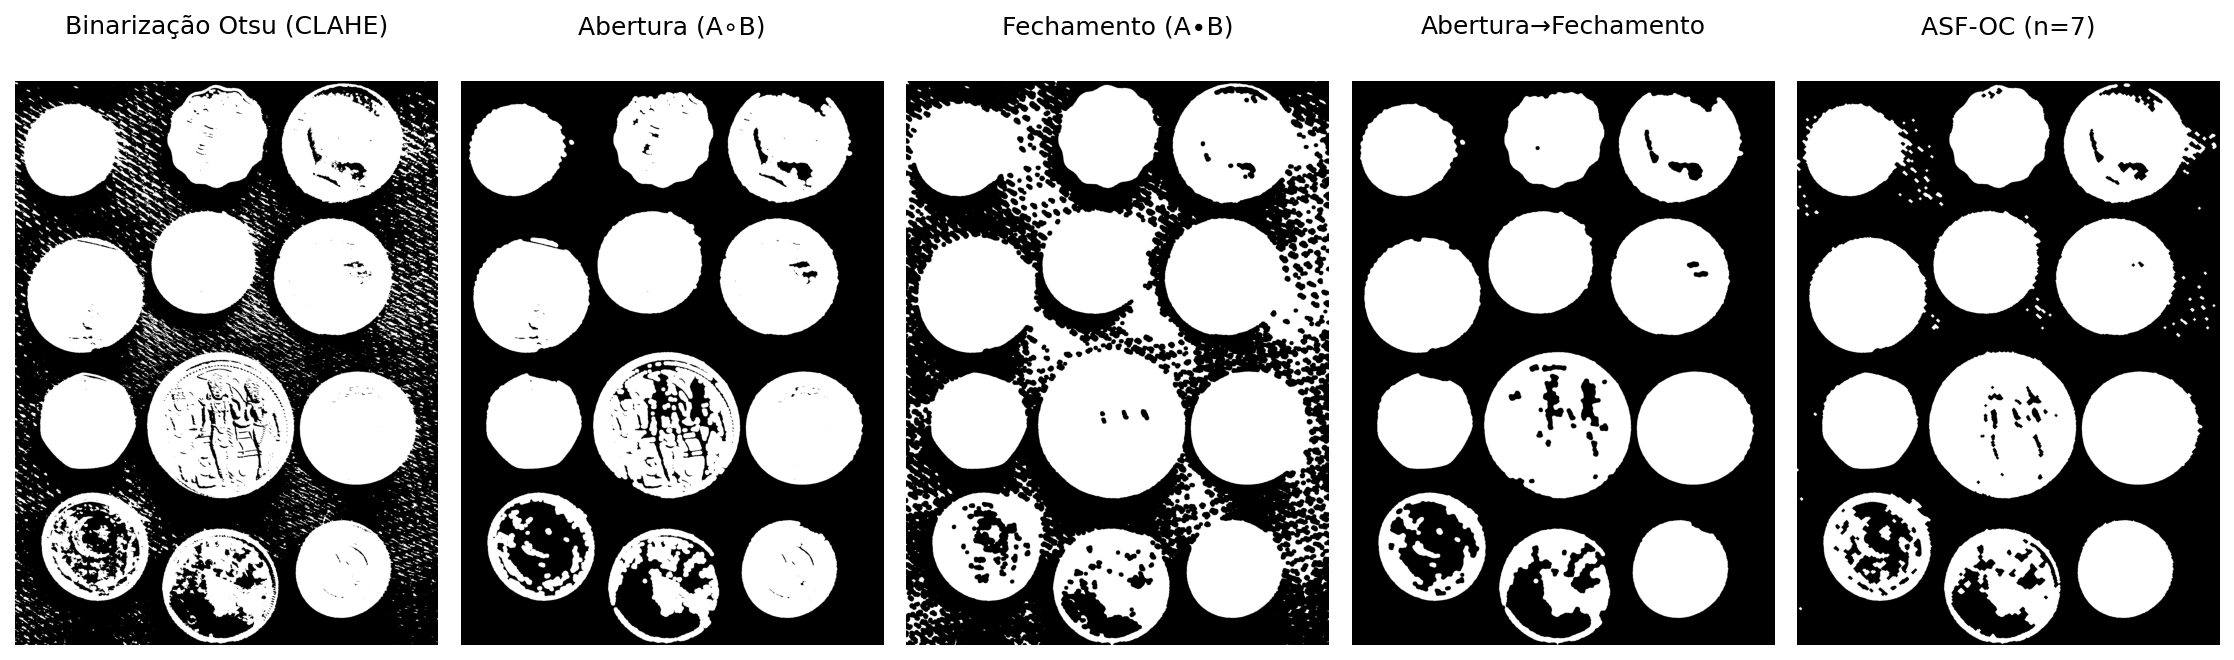

**Figura 4.6:** Abertura, fechamento, composição e filtro sequencial alternado aplicados à binarização Otsu das moedas com CLAHE. Elemento estruturante: disco 13×13.


In [ ]:
img_bin    = mm.threshold(img_clahe)
B_disk     = mm.sedisk(19)

img_open  = mm.open(img_bin, B_disk)             # erosão → dilatação
img_close = mm.close(img_bin, B_disk)            # dilatação → erosão
img_oc    = mm.close(img_open, B_disk)           # abertura seguida de fechamento
img_asf   = mm.asf(img_bin, 'OC', mm.sedisk(3), n=7)  
# ASF: disco base 3×3, cresce a cada iteração

mm.show(
    [img_bin, img_open, img_close, img_oc, img_asf],
    titles=["Binarização Otsu (CLAHE)", "Abertura (A∘B)", "Fechamento (A∙B)",
            "Abertura→Fechamento", "ASF-OC (n=7)"],
    cols=5, figsize=(15, 12)
)

### 4.3.3 Operadores Geodésicos

Os operadores geodésicos introduzem uma restrição adicional aos operadores morfológicos clássicos por meio de uma imagem de controle denominada **máscara** $g$. Em vez de permitir que a erosão ou a dilatação se propaguem livremente pela imagem, o resultado de cada iteração é limitado ponto a ponto pelos valores da máscara, restringindo a evolução da operação às regiões permitidas.


#### 4.3.3.1 Dilatação Geodésica

A **dilatação geodésica** de uma imagem marcador $f$ sob uma imagem máscara $g$, utilizando um elemento estruturante plano $b$, é definida por:

<a id="eq-04-cdil"></a>
$$
f \oplus_g b = (f \oplus b) \wedge g, \tag{4.7}
$$


onde $\wedge$ representa o mínimo ponto a ponto.

Em outras palavras, realiza-se inicialmente uma dilatação convencional sobre o marcador e, em seguida, o resultado é restringido pela máscara $g$. Dessa forma, a propagação nunca pode ultrapassar as regiões permitidas pela máscara.

A formulação clássica da dilatação geodésica pressupõe que o marcador esteja contido na máscara, isto é, $f \le g$, garantindo que a evolução da operação permaneça sempre limitada pela máscara.


#### 4.3.3.2 Implementação da dilatação geodésica

A função `mm.cdil` implementa diretamente esse operador e permite executar múltiplas iterações consecutivas:

```python
def cdil(f, g, b=np.zeros((3,3),dtype='uint8'), n=1):
    """Dilatação geodésica do marcador f sob a máscara g."""
    y = f.copy()
    for _ in range(n):
        y = np.minimum(cv2.dilate(y, b), g)
    return y
```

A instrução `np.minimum(cv2.dilate(y, b), g)` implementa exatamente a definição matemática da dilatação geodésica, isto é, $(y \oplus b)\wedge g$.

Quando $n=1$, a função executa uma única dilatação geodésica. Para $n>1$, o resultado de cada etapa torna-se o marcador da etapa seguinte, produzindo uma propagação progressiva controlada pela máscara.

O simulador interativo [Figura 4.7](#fig-04-sim-04-cdil) permite acompanhar, passo a passo, a propagação do marcador $f$ ao longo dos corredores do labirinto. A cada iteração de `mm.cdil`, a frente de dilatação avança para as células vizinhas livres — aquelas em que $g = 1$ —, enquanto as paredes ($g = 0$) permanecem intransponíveis. O número de passos necessários para que o marcador alcance a saída corresponde exatamente ao comprimento geodésico do caminho mais curto dentro da máscara, evidenciando a conexão direta entre a dilatação geodésica iterada e a noção de distância em grafos.

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-cdil" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <!-- Cabeçalho -->
  <div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241d;">🗺️ Simulador: Dilatação Geodésica no Labirinto</span>
    <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">δ_g^(n)(f)</span>
  </div>

  <div style="padding:16px;background:#ffffff;">
    
    <!-- Legenda -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:10px;padding:10px 14px;display:flex;gap:14px;align-items:center;flex-wrap:wrap;justify-content:center;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:5px;"><div style="width:14px;height:14px;background:#2c2c2a;border-radius:3px;"></div><span style="font-size:11px;color:#8a8371;">Parede</span></div>
      <div style="display:flex;align-items:center;gap:5px;"><div style="width:14px;height:14px;background:#eafaf1;border:1px solid #a3e4d7;border-radius:3px;"></div><span style="font-size:11px;color:#8a8371;">Caminho livre (g)</span></div>
      <div style="display:flex;align-items:center;gap:5px;"><div style="width:14px;height:14px;background:#27ae60;border-radius:3px;"></div><span style="font-size:11px;color:#8a8371;">Marcador f</span></div>
      <div style="display:flex;align-items:center;gap:5px;"><div style="width:14px;height:14px;background:#a3e4d7;border-radius:3px;"></div><span style="font-size:11px;color:#8a8371;">Propagação</span></div>
      <div style="display:flex;align-items:center;gap:5px;"><div style="width:14px;height:14px;background:#fef9e7;border:1px solid #f8c471;border-radius:3px;"></div><span style="font-size:11px;color:#8a8371;">Saída</span></div>
    </div>

    <!-- Canvas Centralizado -->
    <div style="display:flex;justify-content:center;margin-bottom:14px;">
      <canvas id="sim-04-cdil_Canvas" width="435" height="435" style="width:100%;max-width:435px;display:block;border-radius:12px;border:1px solid #e4dcc8;background:#ffffff;"></canvas>
    </div>

    <!-- Controles e Informações do Passo -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;display:flex;align-items:center;gap:12px;flex-wrap:wrap;justify-content:space-between;">
      <div style="display:flex;gap:6px;flex-wrap:wrap;">
        <button id="sim-04-cdil_btnReset" style="padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:8px;transition:all 0.15s ease;">↺ Reiniciar</button>
        <button id="sim-04-cdil_btnPrev" disabled style="padding:6px 12px;font-size:11px;font-weight:600;border:1px solid #e4dcc8;background:#f1ead7;color:#5e5a4a;cursor:pointer;border-radius:8px;transition:all 0.15s ease;">‹ Anterior</button>
        <button id="sim-04-cdil_btnNext" style="padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #2980b9;background:#ebf4fd;color:#2980b9;cursor:pointer;border-radius:8px;transition:all 0.15s ease;">Avançar ›</button>
        <button id="sim-04-cdil_btnPlay" style="padding:6px 12px;font-size:11px;font-weight:700;border:1px solid #26241d;background:#26241d;color:#7ee7c6;cursor:pointer;border-radius:8px;transition:all 0.15s ease;">▶ Animar</button>
      </div>
      <div id="sim-04-cdil_info" style="font-size:11px;font-family:monospace;color:#26241d;flex:1;min-width:180px;text-align:right;">Passo 0 — marcador inicial f (entrada)</div>
    </div>

  </div>
</div>

<script>
(function() {
  function initSim04Cdil(root){
    if (!root || root.dataset.sim04CdilInit) return;
    root.dataset.sim04CdilInit = "1";

    const G = [
      [0,0,0,0,0,0,0,0,0,0,0,0],
      [0,1,1,1,0,1,1,1,1,1,1,0],
      [0,0,0,1,0,1,0,0,0,0,1,0],
      [0,1,0,1,0,1,0,1,1,0,1,0],
      [0,1,0,1,1,1,0,1,0,0,1,0],
      [0,1,0,0,0,0,0,1,0,1,1,0],
      [0,1,1,1,1,1,1,1,0,1,0,0],
      [0,0,0,0,0,0,1,0,0,1,0,0],
      [0,1,1,1,1,0,1,1,1,1,0,0],
      [0,1,0,0,1,0,0,0,0,1,0,0],
      [0,1,1,1,1,1,1,1,1,1,0,0],
      [0,0,0,0,0,0,0,0,0,0,0,0]
    ];
    const ROWS = G.length, COLS = G[0].length;
    const START = [1,1];
    const EXIT  = [10,9];

    function dilate(prev, mask) {
      const next = prev.map(r => [...r]);
      const dirs = [[-1,0],[1,0],[0,-1],[0,1]];
      for (let r=0; r<ROWS; r++)
        for (let c=0; c<COLS; c++)
          if (prev[r][c]) {
            for (const [dr,dc] of dirs) {
              const nr=r+dr, nc=c+dc;
              if (nr>=0&&nr<ROWS&&nc>=0&&nc<COLS&&mask[nr][nc])
                next[nr][nc]=1;
            }
          }
      return next;
    }

    function emptyGrid() { return Array.from({length:ROWS},()=>new Array(COLS).fill(0)); }

    let steps = [];
    function buildSteps() {
      steps = [];
      let cur = emptyGrid();
      cur[START[0]][START[1]] = 1;
      steps.push(cur.map(r=>[...r]));
      let prev = null;
      while (JSON.stringify(cur) !== JSON.stringify(prev)) {
        prev = cur.map(r=>[...r]);
        cur = dilate(cur, G);
        steps.push(cur.map(r=>[...r]));
        if (steps.length > 80) break;
      }
    }

    buildSteps();
    let idx = 0, playing = false, timer = null;

    const cv = root.querySelector('#sim-04-cdil_Canvas');
    const ctx = cv.getContext('2d');

    const C = {
      wall:    '#2c2c2a',
      free:    '#eafaf1',
      freeBd:  '#a3e4d7',
      marker:  '#27ae60',
      trail:   '#a3e4d7',
      exit:    '#fef9e7',
      exitBd:  '#f8c471',
      bg:      '#fafaf7',
      text:    '#5e5a4a',
      grid:    '#e4dcc8',
    };

    function draw() {
      const W = cv.width, H = cv.height;
      const cw = W / COLS, ch = H / ROWS;
      ctx.clearRect(0,0,W,H);
      ctx.fillStyle = C.bg;
      ctx.fillRect(0,0,W,H);

      const cur = steps[idx];
      const prev = idx > 0 ? steps[idx-1] : null;

      for (let r=0; r<ROWS; r++) {
        for (let c=0; c<COLS; c++) {
          const x = c*cw, y = r*ch;
          const isExit = r===EXIT[0]&&c===EXIT[1];

          if (!G[r][c]) {
            ctx.fillStyle = C.wall;
            ctx.fillRect(x+0.5,y+0.5,cw-1,ch-1);
          } else {
            if (isExit) {
              ctx.fillStyle = C.exit;
              ctx.fillRect(x+0.5,y+0.5,cw-1,ch-1);
              ctx.strokeStyle = C.exitBd;
              ctx.lineWidth = 1.5;
              ctx.strokeRect(x+1.5,y+1.5,cw-3,ch-3);
            } else {
              ctx.fillStyle = C.free;
              ctx.fillRect(x+0.5,y+0.5,cw-1,ch-1);
              ctx.strokeStyle = C.freeBd;
              ctx.lineWidth = 0.5;
              ctx.strokeRect(x+0.5,y+0.5,cw-1,ch-1);
            }
            if (prev && prev[r][c]) {
              ctx.fillStyle = C.trail;
              ctx.fillRect(x+0.5,y+0.5,cw-1,ch-1);
            }
            if (cur[r][c]) {
              ctx.fillStyle = C.marker;
              ctx.fillRect(x+2,y+2,cw-4,ch-4);
            }
          }
        }
      }

      ctx.strokeStyle = C.grid;
      ctx.lineWidth = 0.5;
      for (let r=0; r<=ROWS; r++) { ctx.beginPath(); ctx.moveTo(0,r*ch); ctx.lineTo(W,r*ch); ctx.stroke(); }
      for (let c=0; c<=COLS; c++) { ctx.beginPath(); ctx.moveTo(c*cw,0); ctx.lineTo(c*cw,H); ctx.stroke(); }

      ctx.fillStyle = '#ffffff';
      ctx.font = 'bold 11px monospace';
      ctx.textAlign = 'center';
      ctx.textBaseline = 'middle';
      const [sr,sc] = START;
      ctx.fillText('E', (sc+0.5)*cw, (sr+0.5)*ch);
      const [er,ec] = EXIT;
      ctx.fillStyle = '#b9770e';
      ctx.fillText('S', (ec+0.5)*cw, (er+0.5)*ch);

      const reached = steps[idx][EXIT[0]][EXIT[1]];
      let msg = '';
      if (idx === 0) msg = 'Passo 0 — marcador inicial f (entrada)';
      else if (reached) msg = 'Passo ' + idx + ' — saída alcançada! 🎉';
      else msg = 'Passo ' + idx + ' — propagação geodésica';

      root.querySelector('#sim-04-cdil_info').textContent = msg;
      root.querySelector('#sim-04-cdil_btnPrev').disabled = idx === 0;
      root.querySelector('#sim-04-cdil_btnNext').disabled = idx === steps.length-1;
    }

    function step(d) {
      idx = Math.max(0, Math.min(steps.length-1, idx+d));
      draw();
    }

    function reset() {
      stopPlay();
      idx = 0;
      draw();
    }

    function togglePlay() {
      playing ? stopPlay() : startPlay();
    }

    function startPlay() {
      playing = true;
      root.querySelector('#sim-04-cdil_btnPlay').textContent = '⏸ Pausar';
      timer = setInterval(() => {
        if (idx >= steps.length-1) { stopPlay(); return; }
        idx++;
        draw();
      }, 350);
    }

    function stopPlay() {
      playing = false;
      clearInterval(timer);
      root.querySelector('#sim-04-cdil_btnPlay').textContent = '▶ Animar';
    }

    root.querySelector('#sim-04-cdil_btnReset').addEventListener('click', reset);
    root.querySelector('#sim-04-cdil_btnPrev').addEventListener('click', () => step(-1));
    root.querySelector('#sim-04-cdil_btnNext').addEventListener('click', () => step(1));
    root.querySelector('#sim-04-cdil_btnPlay').addEventListener('click', togglePlay);

    draw();
  }

  function tryInitSim04Cdil(){
    var root = document.getElementById('sim-04-cdil');
    if (root) initSim04Cdil(root); else setTimeout(tryInitSim04Cdil, 200);
  }
  tryInitSim04Cdil();
})();
</script>
""")

**Figura 4.7:** Simulador interativo de dilatação geodésica: o marcador f (verde) propaga-se passo a passo pelos caminhos livres da máscara g, sem atravessar paredes.


#### 4.3.3.3 Erosão Geodésica

De forma dual, a **erosão geodésica** de uma imagem marcador $f$ sob uma imagem máscara $g$ é definida por:

<a id="eq-04-cero"></a>
$$
f \ominus_g b = (f \ominus b) \vee g, \tag{4.8}
$$


onde $\vee$ representa o operador de máximo ponto a ponto.

Nesse caso, a erosão convencional do marcador é seguida por uma restrição inferior imposta pela máscara. Assim, nenhum pixel do resultado pode assumir valor inferior ao correspondente pixel da máscara.

A formulação clássica da erosão geodésica pressupõe a condição dual

$$
f \ge g,
$$

de modo que a máscara atue como limite inferior durante todo o processo.

#### 4.3.3.4 Implementação da erosão geodésica

A função estática `mm.cero` materializa esse operador:

```python
?staticmethod
def cero(f, g, b=np.zeros((3,3),dtype='uint8'), n=1):
    """Erosão geodésica do marcador f sob a máscara g."""
    y = f.copy()
    for _ in range(n):
        y = np.maximum(cv2.erode(y, b), g)
    return y
```

A instrução `np.maximum(cv2.erode(y, b), g)` implementa diretamente a expressão $(y \ominus b)\vee g$.

Assim como na dilatação geodésica, o parâmetro $n$ define quantas erosões geodésicas sucessivas serão computadas antes de retornar a imagem final.

> ### 📝 Relação com a reconstrução morfológica
>
> A reconstrução morfológica apresentada na próxima seção é obtida pela aplicação iterativa da dilatação geodésica (`mm.cdil`) até que um ponto fixo seja alcançado, isto é, até que nenhuma célula mude de valor entre duas iterações consecutivas. Em outras palavras, a reconstrução consiste em uma sequência de dilatações geodésicas sucessivas que se propagam dentro da máscara até não haver mais alterações.
>
> De forma dual, também é possível definir reconstruções baseadas em erosão geodésica por meio de aplicações sucessivas de `mm.cero`.

#### 4.3.3.5 Exemplo: propagação em um labirinto via dualidade

A [Figura 4.8](#fig-04-cero-labirinto) ilustra a resolução do problema de conectividade de um labirinto utilizando a dualidade morfológica por meio das funções `mm.cero` e `mm.suprec`.

Em vez de propagar um marcador pelos corredores livres através de dilatações geodésicas, o problema é formulado no domínio complementar. Inicialmente, a máscara original é invertida,

$$
g = 1 - g_{orig},
$$

fazendo com que as paredes passem a assumir valor 1 e os corredores valor 0. De forma análoga, o marcador é construído nesse mesmo domínio complementar, contendo um único valor 0 na posição de entrada do labirinto e valor 1 nos demais pixels.

Utilizando o elemento estruturante em cruz (`mm.secross()`), a erosão geodésica atua sobre o marcador complementado. A cada iteração de `mm.cero`, a região conectada ao marcador inicial sofre erosões sucessivas, enquanto a máscara impõe um limite inferior que impede a propagação através das paredes do labirinto.

As imagens intermediárias mostram estados da evolução após diferentes números de iterações (`n=5`, `n=12` e `n=22`). O resultado final é obtido pela reconstrução geodésica por erosão (`mm.suprec`), que aplica erosões geodésicas sucessivas até atingir um ponto fixo, isto é, uma situação em que nenhuma alteração adicional ocorre entre duas iterações consecutivas.

No domínio complementar, a região reconstruída corresponde exatamente ao conjunto de corredores conectados à entrada do labirinto. Assim, a conectividade entre entrada e saída pode ser determinada diretamente a partir da imagem reconstruída.

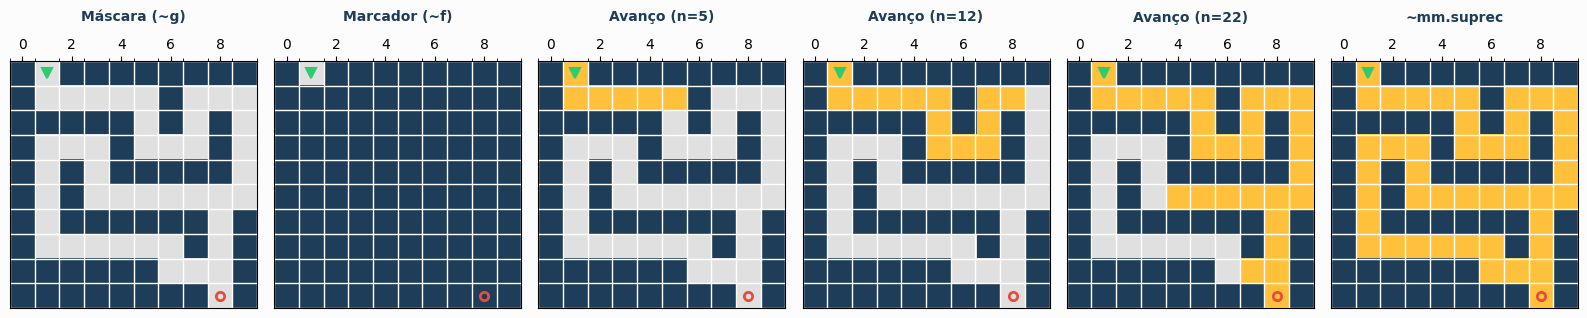

**Figura 4.8:** Resolução de labirinto via Operações Complementares: Invertendo a máscara e o marcador no início do *pipeline*, o fluxo é resolvido diretamente no domínio complementar através de mm.cero e mm.suprec, eliminando re-inversões redundantes.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Máscara original g (0 = Parede, 1 = Corredor)
g_orig = np.array([
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]], dtype=np.uint8)

# Inversão global no início (Dualidade Morfológica)
g = 1 - g_orig  # Agora: 1 = Parede, 0 = Corredor
f = np.ones((10, 10), dtype=np.uint8)
f[0, 1] = 0     # Semente injetada como 0 no corredor

# Elemento estruturante em cruz
B_cruz = mm.secross()

# Processamento direto usando mm.cero e mm.suprec no domínio invertido
passo_5    = mm.cero(f, g, B_cruz, n=5)
passo_12   = mm.cero(f, g, B_cruz, n=12)
passo_22   = mm.cero(f, g, B_cruz, n=22)
ponto_fixo = mm.suprec(f, g, B_cruz)

# --- CONFIGURAÇÃO DA EXIBIÇÃO GRÁFICA ---

titles = [
    "Máscara (~g)", "Marcador (~f)", 
    "Avanço (n=5)", "Avanço (n=12)", 
    "Avanço (n=22)", "~mm.suprec"
]
images = [g, f, passo_5, passo_12, passo_22, ponto_fixo]

fig, axes = plt.subplots(1, 6, figsize=(16, 4), facecolor='#fcfcfc')

# Mapa de cores adaptado para o domínio complementar:
# No domínio invertido: 1 = Parede (Azul Escuro)
# Onde g == 0 e imagem == 1 = Corredor Livre (Cinza Claro)
# Onde g == 0 e imagem == 0 = Onda Geodésica Ativa (Ouro)
cmap_pipeline = mcolors.ListedColormap(['#ffc13b', '#e0e0e0', '#1e3d59'])

for i, ax in enumerate(axes):
    if i == 0 or i == 1:
        # Para as condições iniciais (~g e ~f)
        cmap_init = mcolors.ListedColormap(['#e0e0e0', '#1e3d59'])
        ax.imshow(images[i], cmap=cmap_init, vmin=0, vmax=1)
    else:
        # Renderização baseada nos estados complementares
        render_step = np.zeros_like(g, dtype=np.uint8)
        render_step[g == 1] = 2           # Parede (1 original do mapa de cores)
        render_step[g == 0] = 1           # Corredor padrão
        render_step[images[i] == 0] = 0   # Onda ativa (0 original do mapa de cores)
        ax.imshow(render_step, cmap=cmap_pipeline, vmin=0, vmax=2)
    
    ax.set_title(titles[i], fontsize=10, fontweight='bold', color='#1e3d59', pad=12)
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='#ffffff', linestyle='-', linewidth=1)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    # Indicadores gráficos de Entrada e Saída
    ax.plot(1, 0, marker='v', color='#2ecc71', markersize=7, markeredgewidth=1.5)
    ax.plot(8, 9, marker='o', color='#e74c3c', markersize=6, fillstyle='none', markeredgewidth=2)

plt.tight_layout()
plt.show()

### 4.3.4 Reconstrução Morfológica

A **reconstrução morfológica** propaga uma imagem **marcador** $f$ dentro de uma imagem **máscara** $g$, garantindo que o resultado nunca ultrapasse os valores de intensidade impostos pela máscara. O operador fundamental que viabiliza essa propagação contida é a **dilatação geodésica**, definida pela [Equação 4.7](#eq-04-cdil).

A reconstrução é obtida pela aplicação iterativa dessa dilatação condicionada. Inicialmente, o marcador é limitado pela máscara para estabelecer o estado inicial:

<a id="eq-04-infrec"></a>
$$
X^{(0)} = f \wedge g,
$$

e as iterações subsequentes são definidas de forma recursiva por:

$$
X^{(k)} = (X^{(k-1)} \oplus b) \wedge g.
$$

A sequência cresce monotonicamente até atingir um ponto fixo, produzindo a **reconstrução morfológica por dilatação** (também conhecida na literatura como *inf-reconstrução*):

$$
R_g^\delta(f) = \lim_{k\to\infty} X^{(k)} = X^{(k)} \quad \text{quando} \quad X^{(k)} = X^{(k-1)}. \tag{4.9}
$$


A subida iterativa é interrompida assim que a estabilidade é alcançada, isto é, quando duas iterações consecutivas produzem matrizes com valores absolutamente idênticos.


#### 4.3.4.1 Implementação da reconstrução morfológica

A rotina didática `mm.infrec` implementa diretamente o algoritmo iterativo de ponto fixo. Inicialmente, o marcador efetivo inicial $X^{(0)}$ é determinado pela operação `np.minimum(f, g)`. Para garantir que o laço de verificação execute a primeira passada sem disparar falsas convergências prematuras, a variável de controle da iteração anterior (`y1`) é inicializada preenchida com um valor sentinela fora do domínio de dados (ou simplesmente com uma matriz que force a primeira execução).

```python
def infrec(f, g, b=np.zeros((3,3), dtype='uint8')):
    """Inf-reconstrução: dilata o marcador (f ∧ g) até convergir sob a máscara g."""
    y = np.minimum(f, g)
    # Inicializa y1 com valores impossíveis para forçar a entrada no laço
    y1 = np.full_like(f, 256, dtype=np.int16) 
    while not np.array_equal(y, y1):
        y1 = y.copy()
        # Aplica a dilatação geodésica: (y ⊕ b) ∧ g
        y = np.minimum(cv2.dilate(y, b), g)
    return y.astype('uint8')
```

No interior do laço `while`, a variável `y` armazena a estimativa corrente da reconstrução $X^{(k)}$, enquanto `y1` preserva a imagem do estágio imediatamente anterior $X^{(k-1)}$. A instrução de controle condicional `np.minimum(cv2.dilate(y, b), g)` traduz fielmente a dilatação geodésica teórica, onde a expansão morfológica convencional comandada pelo OpenCV é imediatamente "podada" e limitada pelas barreiras de intensidade da máscara $g$. O laço cessa quando nenhuma modificação de pixel é registrada entre os passos.


#### 4.3.4.2 Vantagens da reconstrução morfológica

A reconstrução morfológica é significativamente mais robusta que a abertura convencional porque é capaz de remover estruturas indesejadas sem distorcer ou alterar a morfologia dos objetos que devem ser preservados.

Enquanto a abertura clássica suaviza cantos, elimina pontas e deforma contornos devido à imposição geométrica rígida do elemento estruturante, a reconstrução geodésica utiliza a máscara para recuperar com exatidão os limites e formatos originais dos objetos que possuem conectividade com o marcador original.

Em termos intuitivos, o marcador atua como uma semente de contágio que se expande progressivamente, mas apenas trafegando pelas regiões permitidas pela máscara. Componentes que não possuem nenhuma intersecção com o marcador jamais serão reconstruídas (sendo eliminadas), enquanto as componentes tocadas pela semente expandem-se até restaurar integralmente a sua geometria original.

Esse comportamento discriminatório e conservativo é ilustrado na [Figura 4.9](#fig-04-reconstrucao-didatica), utilizando o elemento estruturante em cruz apresentado na [Figura 4.3](#fig-04-elemento-cruz).

✅ Reconstrução alcançou estabilidade na iteração 5: False


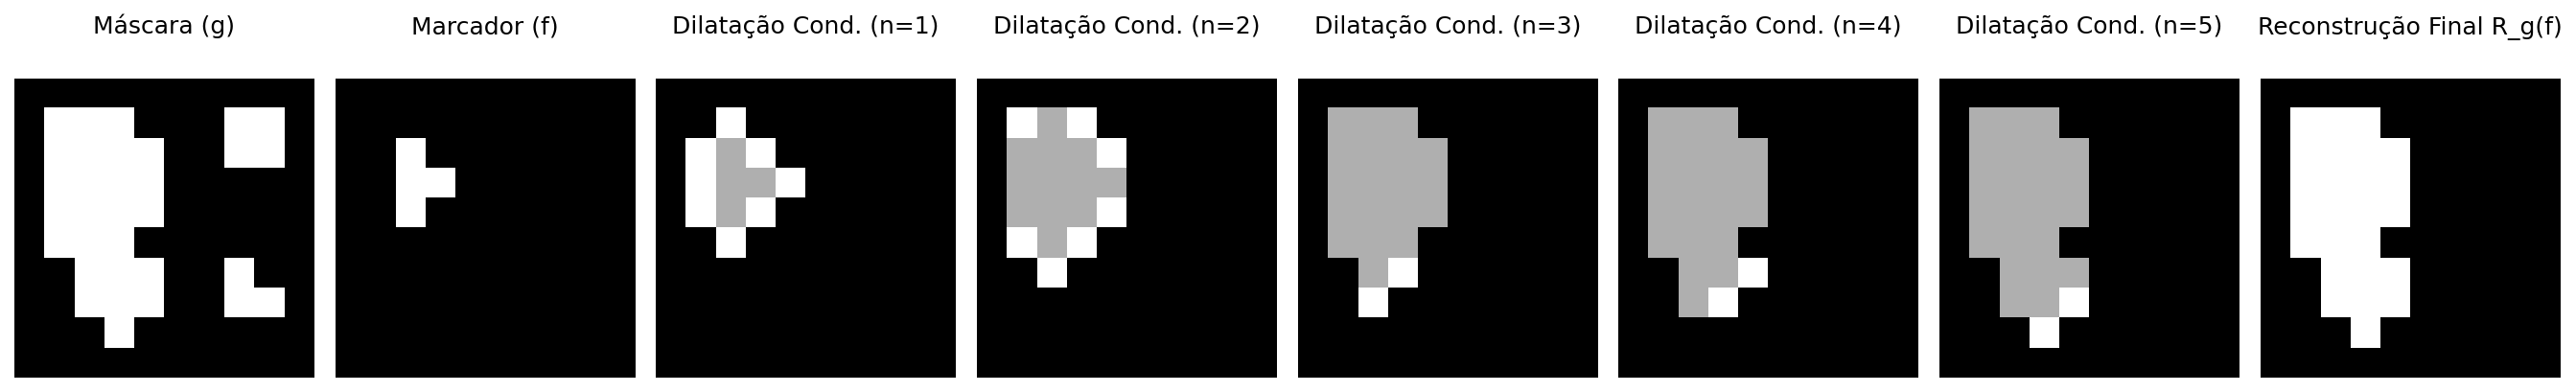

**Figura 4.9:** *Pipeline* de Reconstrução Morfológica por Dilatação Condicionada: a máscara contém dois objetos, o marcador isola apenas o núcleo do objeto principal, e as iterações subsequentes em laço reconstroem sua forma exata até a convergência.


In [ ]:
# 1. Definição da Máscara (g): Imagem 10x10 com dois objetos isolados
g = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,1,1,0],
    [0,1,1,1,1,0,0,1,1,0],
    [0,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,1,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,1,0,0],
    [0,0,1,1,1,0,0,1,1,0],
    [0,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

B_cruz = mm.secross()

# 2. Geração do Marcador (f)
f = mm.ero(g, mm.sebox())

# 3. Iterações da Dilatação Condicionada automatizadas em laço
iteracoes = []
titulos_iteracoes = []
img_atual = f.copy()

for i in range(1, 6):
    img_add = img_atual*80
    img_atual = mm.cdil(img_atual, g, B_cruz)
    iteracoes.append(img_add+img_atual)
    titulos_iteracoes.append(f"Dilatação Cond. (n={i})")

# Reconstrução Geodésica Final via biblioteca (ponto de controle)
img_reconstruida = mm.infrec(f, g, B_cruz)

# Verificação de convergência (o passo 5 deve ser idêntico à reconstrução final)
convergencia_ok = np.array_equal(img_reconstruida, iteracoes[-1])
print(f"✅ Reconstrução alcançou estabilidade na iteração 5: {convergencia_ok}")

# 4. Exibição do pipeline evolutivo (Montagem dinâmica das listas)
mm.show(
    [g, f] + iteracoes + [img_reconstruida],
    titles=["Máscara (g)", "Marcador (f)"] + titulos_iteracoes + ["Reconstrução Final R_g(f)"],
    cols=8,
    figsize=(18, 3)
)

### 4.3.5 Preenchimento de Buracos e Remoção de Bordas

Dois operadores baseados em reconstrução morfológica completam o *pipeline* de limpeza binária. Suas características principais são resumidas na [Tabela 4.4](#tbl-04-clohole-edgeoff).

**Preenchimento de buracos** (`mm.clohole`) remove cavidades completamente cercadas pelo objeto, independentemente do tamanho, sem alterar os contornos externos. O procedimento atua no complemento da imagem, utilizando como marcador uma restrição da moldura (*frame*) ao fundo:

<a id="eq-04-clohole"></a>
$$
\text{clohole}(f) = \bigl(R_{f^c}^\delta(\text{frame}(f) \wedge f^c)\bigr)^c \tag{4.10}
$$



Em termos operacionais, primeiro reconstrói-se o fundo externo e, em seguida, aplica-se a complementação para recuperar os objetos com buracos preenchidos.

**Remoção de objetos de borda** (`mm.edgeoff`) elimina todos os objetos que tocam a borda da imagem, preservando apenas os componentes totalmente internos. O marcador é obtido pela interseção entre a moldura (*frame*) e os objetos da imagem:

<a id="eq-04-edgeoff"></a>
$$
\text{edgeoff}(f) = f \setminus R_f^\delta(\text{frame}(f) \wedge f) \tag{4.11}
$$


<a id="tbl-04-clohole-edgeoff"></a>

**Tabela 4.4:** Comparação entre os operadores *clohole* e *edgeoff*.

| Operador | Marcador | Máscara | Efeito |
|:---------|:---------|:--------|:-------|
| `mm.clohole` | *frame* restrito ao fundo ($f^c$) | $f^c$ | Preenche buracos internos |
| `mm.edgeoff` | *frame* restrito ao objeto ($f$) | $f$ | Remove objetos conectados à borda |


A evolução passo a passo dessas transformações geodésicas pode ser acompanhada nas figuras a seguir. A [Figura 4.10](#fig-04-clohole-didatico) ilustra o mecanismo de inundação controlada do operador `mm.clohole`, no qual a reconstrução ocorre a partir do fundo externo e impede a propagação para regiões internas não conectadas ao exterior, resultando no preenchimento consistente das cavidades internas. Em contrapartida, a [Figura 4.11](#fig-04-edgeoff-didatico) detalha a dinâmica do operador `mm.edgeoff`, em que apenas os componentes conectados à borda são reconstruídos e posteriormente removidos, preservando exclusivamente os objetos totalmente contidos no interior da imagem.

A conectividade da propagação geodésica é controlada pelo elemento estruturante: `mm.sebox()` (vizinhança de 8) inclui conexões diagonais, enquanto `mm.secross()` (vizinhança de 4) as exclui. Consequentemente, a escolha do elemento estruturante afeta quais componentes são alcançados pela reconstrução e, portanto, quais serão preservados ou removidos.


#### 4.3.5.1 Conformidade com a implementação

As definições acima estão diretamente alinhadas com a implementação em `morph.py`, reproduzida a seguir:

```python
?staticmethod
def clohole(f, b=np.ones((3,3),dtype='uint8')):
    # marcador restrito ao fundo da imagem
    marcador = mm.frame(f, border=1) & mm.neg(f)
    return mm.neg(mm.infrec(marcador, mm.neg(f), b))

?staticmethod
def edgeoff(f, b=np.ones((3,3),dtype='uint8')):
    # marcador restrito aos objetos da imagem
    marcador = mm.frame(f, border=1) & f
    return mm.subm(f, mm.infrec(marcador, f, b))
```

Essas implementações deixam explícito que ambos os operadores são instâncias diretas de reconstrução morfológica por dilatação geodésica com `mm.infrec`, diferindo apenas na escolha do marcador e da máscara: `clohole` atua no complemento da imagem, enquanto `edgeoff` atua diretamente no domínio dos objetos.

✅ Validação clohole: True


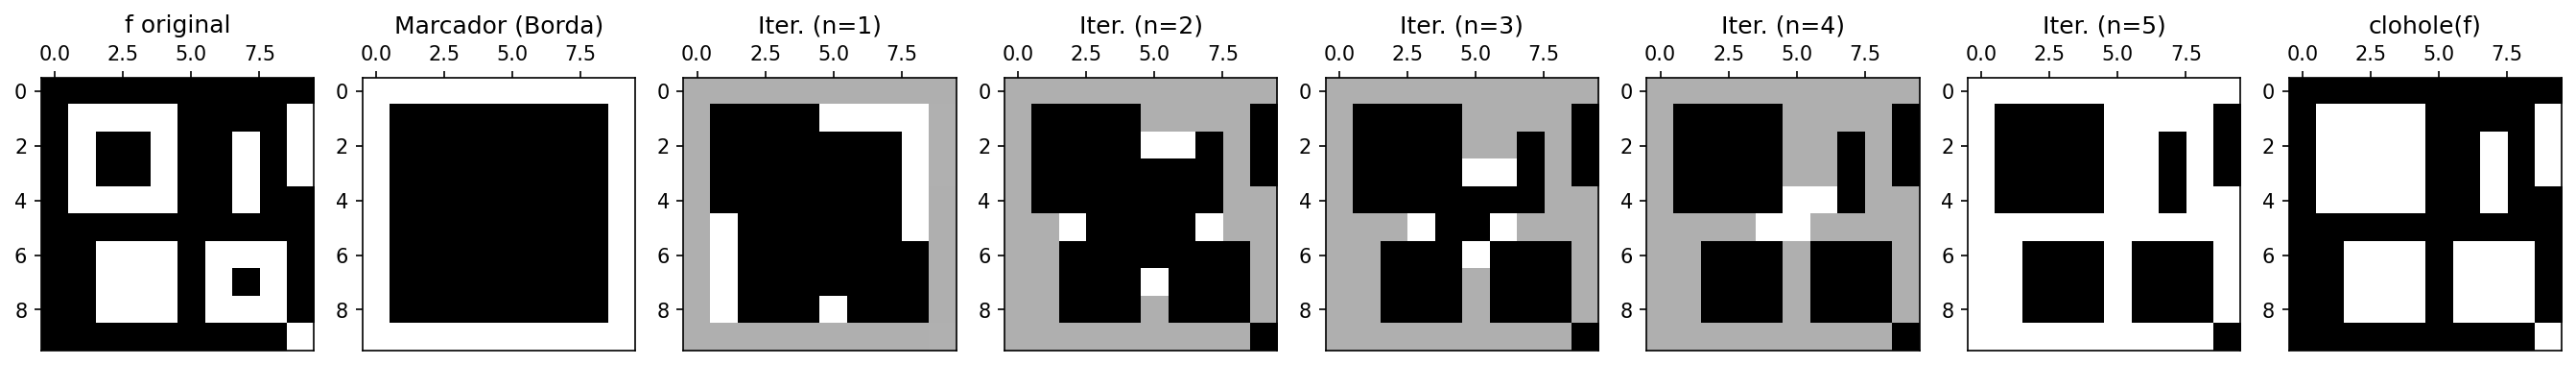

**Figura 4.10:** *Pipeline* de preenchimento de buracos (*clohole*): o marcador é obtido a partir da borda da imagem e restringido ao complemento $f^c$. As iterações de dilatação geodésica reconstruem o fundo externo; após a complementação final, os buracos internos ficam preenchidos.


In [ ]:
# Função auxiliar unificada para gerar o pipeline iterativo com realce visual
def gerar_pipeline_reconstrucao(marcador, mascara, kernel, passos=4, fator=80):
    iteracoes, titulos = [], []
    img_atual = marcador.copy()
    for i in range(1, passos + 1):
        img_visual = img_atual * fator
        img_atual = mm.cdil(img_atual, mascara, kernel)
        iteracoes.append(img_visual + img_atual)
        titulos.append(f"Iter. (n={i})")
    return iteracoes, titulos

# Imagem binária 10x10 com 3 cenários: objeto com buraco, objeto isolado e objeto na borda
f = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,0,0,0,0,1],
    [0,1,0,0,1,0,0,1,0,1],
    [0,1,0,0,1,0,0,1,0,1],
    [0,1,1,1,1,0,0,1,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,1,1,1,0],
    [0,0,1,1,1,0,1,0,1,0],
    [0,0,1,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,1]], dtype=np.uint8) * 255

B_cruz = mm.secross()
f_c = mm.neg(f)              # Utiliza o operador de negação nativo da mm

# ── PIPELINE CLOHOLE ──────────────────────────────────────────────────────────
# O marcador do clohole teórico é a borda externa 
marcador_ch = mm.frame(f, border=1) 
iters_ch, tits_ch = gerar_pipeline_reconstrucao(marcador_ch, f_c, B_cruz, passos=5)

# Resultado final calculado por extenso e validado com a função nativa mm.clohole
img_clohole = mm.neg(mm.infrec(marcador_ch, f_c, B_cruz))
print(f"✅ Validação clohole: {np.array_equal(img_clohole, mm.clohole(f))}")

mm.show(
    [f, marcador_ch] + iters_ch + [img_clohole],
    titles=["f original", "Marcador (Borda)"] + tits_ch + ["clohole(f)"],
    cols=8, figsize=(18, 3), axis=True
)

✅ Validação edgeoff: True


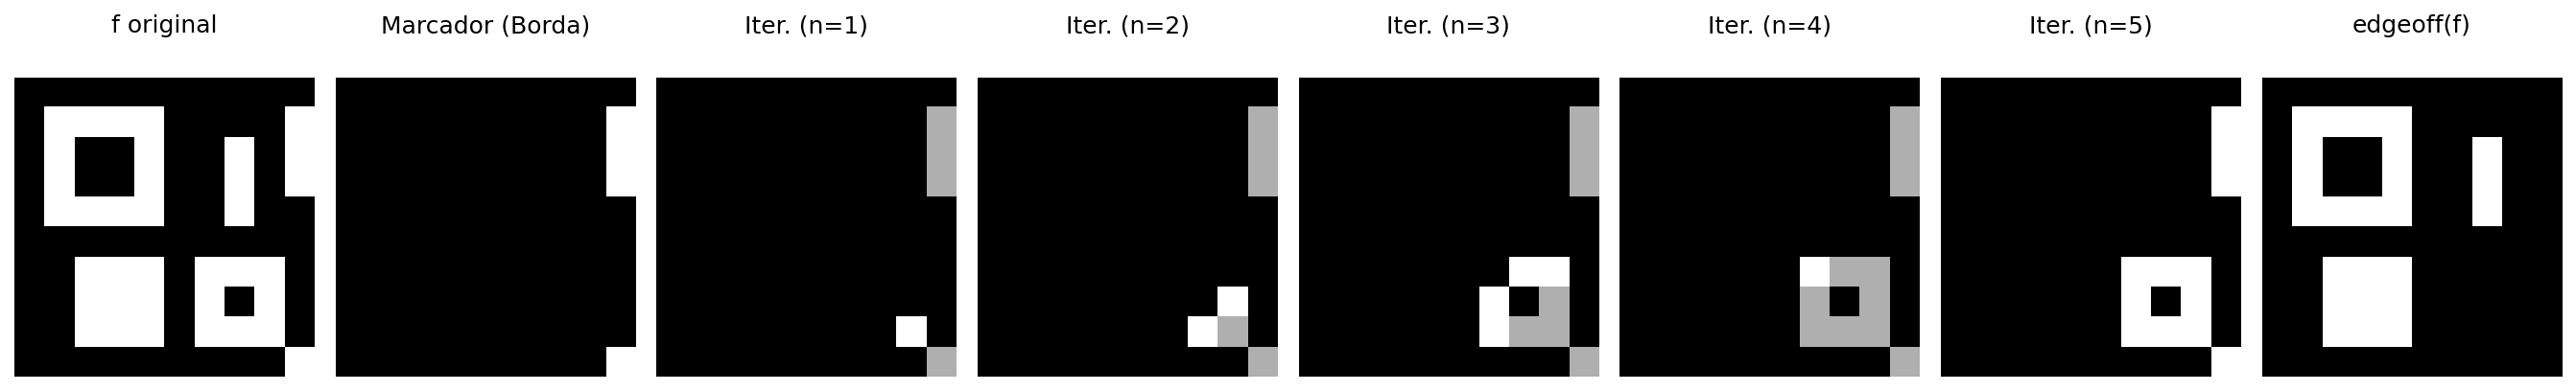

**Figura 4.11:** *Pipeline* de eliminação de estruturas de borda (*edgeoff*): o marcador captura as raízes conectadas às extremidades da matriz, a reconstrução delimita a extensão desses elementos e a subtração booleana preserva unicamente os objetos totalmente internos.


In [ ]:
# ── PIPELINE EDGEOFF ──────────────────────────────────────────────────────────
B_box = mm.sebox()
marcador_eo = marcador_ch & f
iters_eo, tits_eo = gerar_pipeline_reconstrucao(marcador_eo, f, B_box, passos=5)

# Resultado final por definição e validação nativa
img_edgeoff =  mm.edgeoff(f, B_box)
print(f"✅ Validação edgeoff: {np.array_equal(img_edgeoff, mm.edgeoff(f))}")

mm.show(
    [f, marcador_eo] + iters_eo + [img_edgeoff],
    titles=["f original", "Marcador (Borda)"] + tits_eo + ["edgeoff(f)"],
    cols=8, figsize=(18, 3)
)

### 4.3.6 *Pipeline* de Limpeza Binária com CLAHE

Com base na análise anterior — na qual o CLAHE produziu o maior valor da variância interclasses ($\sigma_B^2 \approx 2{,}47 \times 10^3$), ver [Figura 4.2](#fig-04-otsu-comparacao-histogramas), e o operador `mm.clohole` mostrou-se eficaz no preenchimento das cavidades internas —, o *pipeline* final de segmentação, ilustrado na [Figura 4.12](#fig-04-pipeline-clahe), é estruturado pelo seguinte fluxo computacional:

$$
\text{gray}
\xrightarrow{\text{CLAHE}}
\xrightarrow{\text{Otsu}}
\xrightarrow{\text{open}}
\xrightarrow{\text{clohole}}
\xrightarrow{\text{open}}
\xrightarrow{\text{edgeoff}}
\text{segmentação}
$$

Após a etapa de `mm.clohole`, aplica-se uma segunda abertura morfológica com um elemento estruturante maior (`mm.sedisk(33)`, disco de diâmetro 33). Essa operação remove pequenas regiões residuais e artefatos que possam ter permanecido após a segmentação. Em particular, o preenchimento geodésico pode transformar pequenas cavidades isoladas em componentes conectados ao objeto, tornando conveniente uma etapa adicional de filtragem baseada em tamanho. O diâmetro foi escolhido de modo que as moedas permaneçam capazes de conter o elemento estruturante, enquanto componentes significativamente menores sejam eliminados.

Nesta imagem, nenhuma moeda está conectada à borda da matriz. Consequentemente, a aplicação de `mm.edgeoff` não altera o resultado obtido após a segunda abertura. Ainda assim, essa etapa é mantida no *pipeline* por robustez, pois em outras imagens podem existir objetos parcialmente visíveis ou conectados às bordas, que devem ser removidos antes da etapa de análise.

> ### 💡 Por que a abertura após o clohole?
>
> O operador `mm.clohole` preenche todas as cavidades fechadas presentes nos objetos segmentados. Em algumas situações, pequenas regiões indesejadas podem permanecer após essa etapa ou tornar-se conectadas aos objetos principais. A abertura morfológica subsequente remove componentes menores que o elemento estruturante, preservando as moedas devido ao seu tamanho significativamente maior.

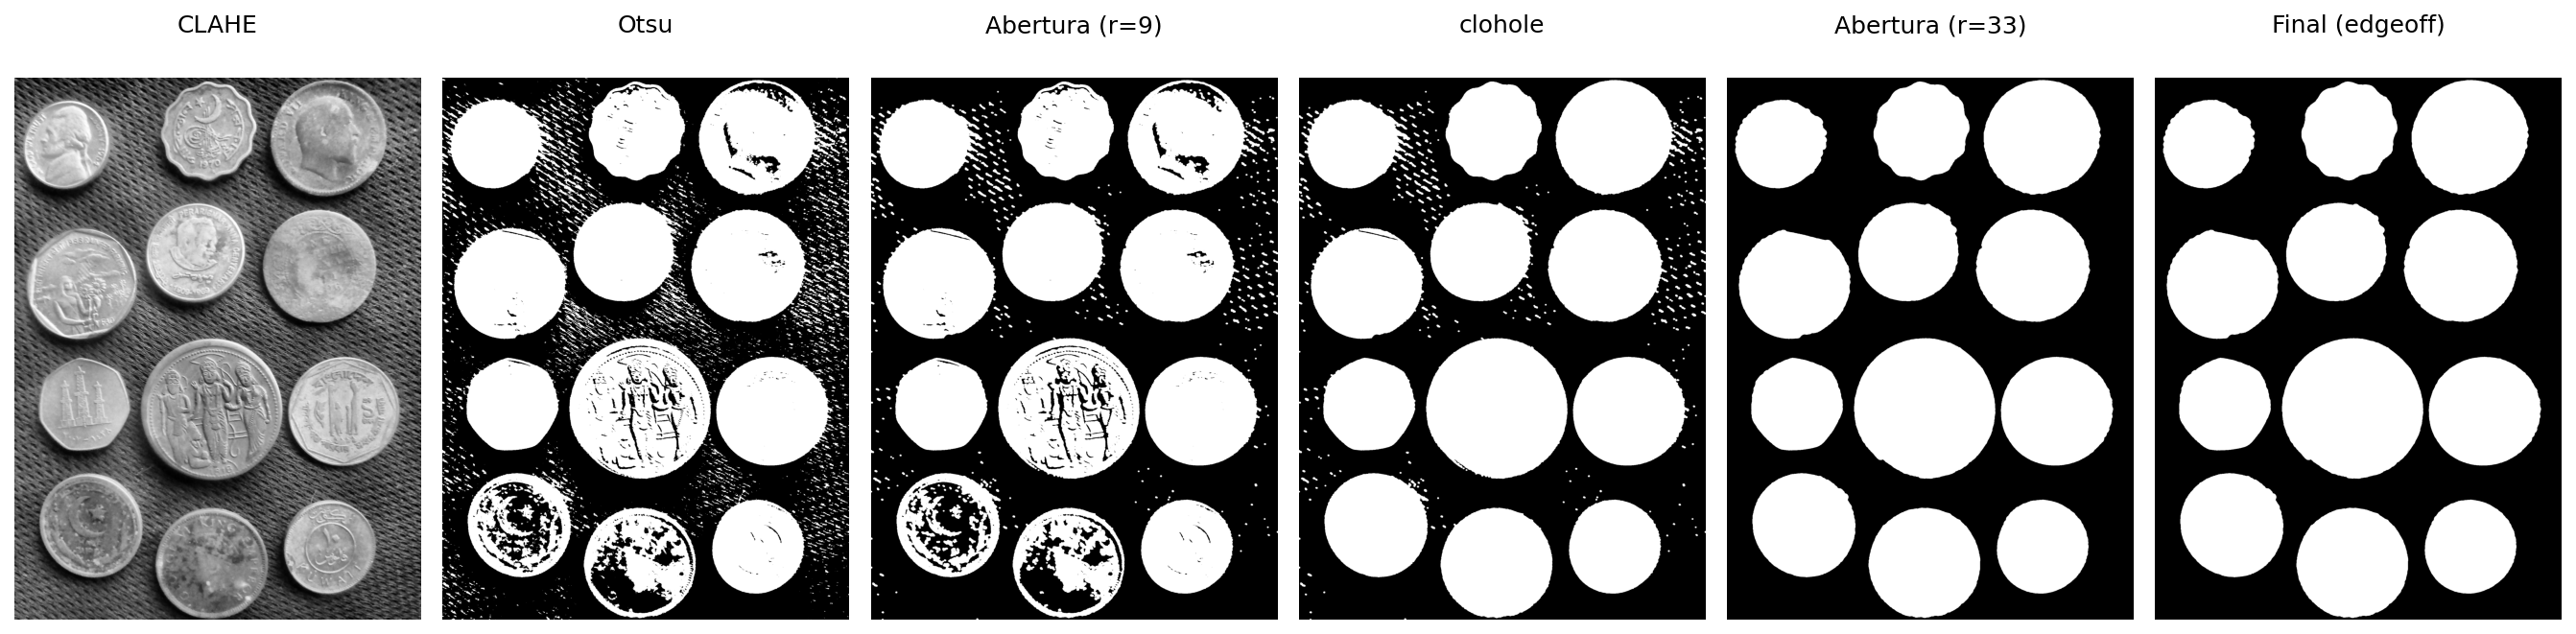

**Figura 4.12:** *Pipeline* completo de segmentação com CLAHE: Otsu → abertura (r=9) → clohole → abertura (r=33) → edgeoff.


In [ ]:
# ── Pré-processamento: apenas CLAHE 
img_clahe0 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img_coins_gray)

# ── Etapa 1: Binarização Otsu
img_bin = mm.threshold(img_clahe0)

# ── Etapa 2: Abertura — remove ruídos brancos de fundo
img_open = mm.open(img_bin, mm.sedisk(9))

# ── Etapa 3: clohole — fecha todos os buracos internos
img_hole = mm.clohole(img_open)

# ── Etapa 4: Abertura (kernel grande) — remove artefatos do clohole
img_limpo = mm.open(img_hole, mm.sedisk(33))

# ── Etapa 5: edgeoff — remove objetos que tocam a borda 
img_final = mm.edgeoff(img_limpo, border=1)

mm.show(
    [img_clahe0,  img_bin,               img_open,
     img_hole,    img_limpo,             img_final],
    titles=["CLAHE",            "Otsu",                "Abertura (r=9)",
            "clohole",          "Abertura (r=33)",     "Final (edgeoff)"],
    cols=6, figsize=(18, 6)
)

### 4.3.7 Morfologia em Tons de Cinza

Os operadores morfológicos estendem-se naturalmente para imagens em tons de cinza. Nessa formulação, a erosão e a dilatação passam a atuar diretamente sobre os níveis de intensidade da imagem. Para elementos estruturantes planos ($b \equiv 0$), a erosão corresponde ao **mínimo local** e a dilatação ao **máximo local** dentro da vizinhança definida pelo elemento estruturante.

A interpretação intuitiva é simples: a erosão **escurece** regiões ao substituir cada pixel pelo menor valor presente em sua vizinhança, enquanto a dilatação **clareia** regiões ao utilizar o maior valor disponível. A combinação desses operadores permite construir transformações capazes de realçar bordas, remover tendências de iluminação e destacar estruturas locais.

Três operadores derivados são especialmente úteis:

**Gradiente morfológico** — destaca bordas como a diferença entre dilatação e erosão:

<a id="eq-04-gradiente-morf"></a>
$$
\text{grad}_B(f) = (f \oplus B) - (f \ominus B) \tag{4.12}
$$


***Top-hat*** — destaca estruturas brilhantes menores que o elemento estruturante (diferença entre a imagem original e sua abertura):

<a id="eq-04-tophat"></a>
$$
\text{top-hat}_B(f) = f - (f \circ B) \tag{4.13}
$$


***Black-hat*** — destaca estruturas escuras menores que o elemento estruturante (diferença entre o fechamento e a imagem original):

<a id="eq-04-blackhat"></a>
$$
\text{black-hat}_B(f) = (f \bullet B) - f \tag{4.14}
$$


O *Top-hat* extrai detalhes brilhantes que não sobrevivem à abertura, enquanto o *Black-hat* evidencia detalhes escuros removidos pelo fechamento. Já o gradiente morfológico realça transições abruptas de intensidade, produzindo uma representação semelhante à de um detector de bordas.

Para compreender o mecanismo desses operadores em nível local, a [Figura 4.13](#fig-04-sim-04-operadores-av) apresenta um simulador interativo de morfologia em tons de cinza. O simulador permite editar livremente o elemento estruturante, visualizar seu deslocamento sobre a imagem e acompanhar simultaneamente o perfil unidimensional das intensidades. Dessa forma, torna-se possível observar diretamente como a erosão seleciona mínimos locais, como a dilatação seleciona máximos locais e como o gradiente morfológico emerge da diferença entre esses dois operadores.

O botão localizado no canto superior direito permite alternar entre a visualização original em tons de cinza e uma representação pseudocolorida (*colormap*) apenas nos três tipos gradientes. A versão colorida facilita a percepção visual das variações de intensidade, tornando mais evidente a ação dos operadores morfológicos sobre máximos, mínimos e transições locais da imagem.

Os operadores apresentados estão disponíveis em `morph.py` por meio das funções `mm.gradm`, `mm.tophat` e `mm.blackhat`.

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-operadores-av" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-04-operadores-av * { box-sizing: border-box; }
  #sim-04-operadores-av canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; background: #ffffff; }
  #sim-04-operadores-av button { font-size: 11px; padding: 6px 10px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 4px; transition: all 0.15s ease; font-weight: 600; }
  #sim-04-operadores-av button:hover { background: #e8dfcf; }
  #sim-04-operadores-av button.gc_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  
  #sim-04-operadores-av button.gc_toggle_btn { background: #ebf4fd; border-color: #2980b9; color: #2980b9; font-weight: 700; }
  #sim-04-operadores-av button.gc_toggle_btn:hover { background: #d4e6fc; }
  
  .gc_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .gc_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 8px; padding: 8px; text-align: center; }
  .gc_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .gc_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  
  #sim04_seCanvas { cursor: pointer; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🎛️ Simulador Avançado de Morfologia Matemática</span>
  <button id="sim04_btn_toggle_view" class="gc_toggle_btn" onclick="sim04_toggleViewMode()">
    Visualização: Cinza Real
  </button>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Barra de Modos de Operação -->
  <div style="display:flex; gap:6px; flex-wrap:wrap; margin-bottom:14px; justify-content:center;">
    <button id="sim04_btn_orig" class="gc_active" onclick="sim04_setMode('orig')">Original f</button>
    <button id="sim04_btn_ero" onclick="sim04_setMode('ero')">Erosão</button>
    <button id="sim04_btn_dil" onclick="sim04_setMode('dil')">Dilatação</button>
    <button id="sim04_btn_open" onclick="sim04_setMode('open')">Abertura (∘)</button>
    <button id="sim04_btn_close" onclick="sim04_setMode('close')">Fechamento (•)</button>
    <button id="sim04_btn_grad" onclick="sim04_setMode('grad')">Gradiente</button>
    <button id="sim04_btn_tophat" onclick="sim04_setMode('tophat')">Top-hat</button>
    <button id="sim04_btn_bhat" onclick="sim04_setMode('bhat')">Black-hat</button>
  </div>

  <!-- Layout Principal em 2 Colunas -->
  <div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(260px, 1fr)); gap:16px; align-items:start; margin-bottom:14px;">
    
    <!-- Canvas Principal -->
    <div style="background:#fafaf7;border:1px solid #e9e3d3;border-radius:12px;padding:12px;text-align:center;">
      <canvas id="sim04_Canvas" style="margin:0 auto;"></canvas>
      <div style="font-size:10px; color:#8a8371; margin-top:8px;">
        🖱️ Mova o mouse para atualizar o perfil 1D da linha correspondente
      </div>
    </div>

    <!-- Painel Lateral de Estatísticas, Descrição e Kernel B -->
    <div style="display:flex; flex-direction:column; gap:12px;">
      
      <!-- Estatísticas / Valores do Pixel -->
      <div style="display:grid; grid-template-columns:repeat(2, 1fr); gap:8px;">
        <div class="gc_stat_box"><div class="gc_stat_label">X (col)</div><div id="sim04_sX" class="gc_stat_value">—</div></div>
        <div class="gc_stat_box"><div class="gc_stat_label">Y (lin)</div><div id="sim04_sY" class="gc_stat_value">—</div></div>
        <div class="gc_stat_box"><div class="gc_stat_label">f(x,y)</div><div id="sim04_sOrig" class="gc_stat_value" style="color:#27ae60;">—</div></div>
        <div class="gc_stat_box"><div class="gc_stat_label" id="sim04_sLabel">valor</div><div id="sim04_sVal" class="gc_stat_value" style="color:#2980b9;">—</div></div>
      </div>

      <!-- Descrição Teórica -->
      <div id="sim04_desc" class="gc_panel" style="font-size:11px; color:#5e5a4a; line-height:1.5; min-height:45px;"></div>

      <!-- Editor do Elemento Estruturante B -->
      <div class="gc_panel" style="text-align:center;">
        <div style="font-size:10.5px; font-weight:700; color:#5e5a4a; margin-bottom:8px; text-transform:uppercase; letter-spacing:.3px;">
          Elemento B (Clique para Editar)
        </div>
        <canvas id="sim04_seCanvas" width="114" height="114" style="margin:0 auto; display:block; border-radius:6px; border:1px solid #e4dcc8; background:#ffffff;"></canvas>
      </div>

      <!-- Fórmulas Auxiliares -->
      <div class="gc_panel" style="font-size:9.5px; font-family:monospace; color:#5e5a4a; line-height:1.5;">
        <strong style="color:#26241d;">Abertura (f∘B):</strong> dil(ero(f))<br>
        <strong style="color:#26241d;">Fechamento (f•B):</strong> ero(dil(f))<br>
        <strong style="color:#26241d;">Gradiente:</strong> dil(f) − ero(f)<br>
        <strong style="color:#26241d;">Top-hat:</strong> f − (f∘B)<br>
        <strong style="color:#26241d;">Black-hat:</strong> (f•B) − f
      </div>

    </div>

  </div>

  <!-- Perfil 1D na Parte Inferior -->
  <div style="background:#fafaf7; border:1px solid #e9e3d3; border-radius:12px; padding:12px; text-align:center;">
    <canvas id="sim04_profileCanvas" width="660" height="110" style="border-radius:8px; border:1px solid #e4dcc8; width:100%; height:auto; background:#ffffff;"></canvas>
    <div id="sim04_profileLabel" style="font-size:10.5px; color:#8a8371; margin-top:6px; font-family:monospace;">Perfil 1D da linha: Nenhuma (passe o mouse sobre a imagem)</div>
  </div>

</div>
</div>

<script>
(function(){
  function initSim04Advanced(root){
    if (!root || root.dataset.sim04AdvancedInit) return;
    root.dataset.sim04AdvancedInit = "1";

    const ROWS = 40, COLS = 40, CELL = 8, PAD = 6;
    const W = COLS * CELL + PAD * 2, H = ROWS * CELL + PAD * 2;

    const cv = root.querySelector('#sim04_Canvas');
    cv.width = W; cv.height = H;
    const ctx = cv.getContext('2d');

    let gc_viewMode = 'gray';
    let gc_mode = 'orig';
    let gc_hx = -1, gc_hy = 19;

    const f = Array.from({length: ROWS}, ()=>new Array(COLS).fill(0));
    const cx1 = 13, cy1 = 14, r1 = 9, cx2 = 28, cy2 = 14, r2 = 7, cx3 = 20, cy3 = 28, r3 = 8;
    for (let r=0; r<ROWS; r++) {
      for (let c=0; c<COLS; c++) {
        let v = 30;
        const d1 = Math.hypot(c - cx1, r - cy1), d2 = Math.hypot(c - cx2, r - cy2), d3 = Math.hypot(c - cx3, r - cy3);
        if (d1 < r1) v = Math.round(200 - 90 * (d1 / r1));
        if (d2 < r2) v = Math.max(v, Math.round(180 - 70 * (d2 / r2)));
        if (d3 < r3) v = Math.max(v, Math.round(160 - 50 * (d3 / r3)));
        if (Math.hypot(c - 33, r - 8) < 2.2) v = 230;
        if (Math.hypot(c - 6, r - 32) < 2.2) v = Math.min(v, 20);
        f[r][c] = Math.max(0, Math.min(255, v));
      }
    }

    const B_SIZE = 5;
    const B = Array.from({length: B_SIZE}, () => new Array(B_SIZE).fill(0));
    const rad = 2;
    for (let r=0; r<B_SIZE; r++) {
      for (let c=0; c<B_SIZE; c++) {
        if (Math.hypot(c - rad, r - rad) <= rad) B[r][c] = 1;
      }
    }

    const MORPH_DATA = {};

    function recalculateMorphology() {
      const Boff = [];
      const center = Math.floor(B_SIZE / 2);
      for (let r=0; r<B_SIZE; r++) {
        for (let c=0; c<B_SIZE; c++) {
          if (B[r][c]) Boff.push([r - center, c - center]);
        }
      }
      if (Boff.length === 0) Boff.push([0, 0]);

      function e_op(img) {
        const res = Array.from({length: ROWS}, ()=>new Array(COLS).fill(0));
        for (let r=0; r<ROWS; r++) {
          for (let c=0; c<COLS; c++) {
            let mn = 255;
            for (const [dr, dc] of Boff) {
              const vr = r + dr, vc = c + dc;
              const val = (vr >= 0 && vr < ROWS && vc >= 0 && vc < COLS) ? img[vr][vc] : 255;
              if (val < mn) mn = val;
            }
            res[r][c] = mn;
          }
        }
        return res;
      }

      function d_op(img) {
        const res = Array.from({length: ROWS}, ()=>new Array(COLS).fill(0));
        for (let r=0; r<ROWS; r++) {
          for (let c=0; c<COLS; c++) {
            let mx = 0;
            for (const [dr, dc] of Boff) {
              const vr = r + dr, vc = c + dc;
              const val = (vr >= 0 && vr < ROWS && vc >= 0 && vc < COLS) ? img[vr][vc] : 0;
              if (val > mx) mx = val;
            }
            res[r][c] = mx;
          }
        }
        return res;
      }

      function diff(a, b) {
        return Array.from({length: ROWS}, (_, r) => Array.from({length: COLS}, (_, c) => Math.max(0, Math.min(255, a[r][c] - b[r][c]))));
      }

      MORPH_DATA.orig = f;
      MORPH_DATA.ero = e_op(f);
      MORPH_DATA.dil = d_op(f);
      MORPH_DATA.open = d_op(MORPH_DATA.ero);
      MORPH_DATA.close = e_op(MORPH_DATA.dil);
      MORPH_DATA.grad = diff(MORPH_DATA.dil, MORPH_DATA.ero);
      MORPH_DATA.tophat = diff(f, MORPH_DATA.open);
      MORPH_DATA.bhat = diff(MORPH_DATA.close, f);
    }

    const MODES_CONFIG = {
      orig: {label: 'f(x,y)', color: '#27ae60', desc: 'Imagem original f.'},
      ero: {label: 'ero(x,y)', color: '#c0392b', desc: 'Erosão: Encolhe estruturas claras de acordo com a geometria de B.'},
      dil: {label: 'dil(x,y)', color: '#2980b9', desc: 'Dilatação: Expande estruturas claras preenchendo falhas.'},
      open: {label: 'open(x,y)', color: '#8e44ad', desc: 'Abertura: Suaviza contornos, elimina pequenos ruídos e picos brilhantes isolados.'},
      close: {label: 'close(x,y)', color: '#d35400', desc: 'Fechamento: Preenche pequenos canais ou buracos escuros interiores.'},
      grad: {label: 'grad(x,y)', color: '#16a085', desc: 'Gradiente morfológico: Destaca as bordas físicas dos objetos.'},
      tophat: {label: 'th(x,y)', color: '#b9770e', desc: 'Top-hat: Isola elementos brilhantes menores que B.'},
      bhat: {label: 'bh(x,y)', color: '#2c3e50', desc: 'Black-hat: Isola fossas escuras ou vales menores que B.'}
    };

    window.sim04_toggleViewMode = function() {
      if (gc_viewMode === 'gray') {
        gc_viewMode = 'colormap';
        root.querySelector('#sim04_btn_toggle_view').innerHTML = 'Visualização: Falsa Cor';
      } else {
        gc_viewMode = 'gray';
        root.querySelector('#sim04_btn_toggle_view').innerHTML = 'Visualização: Cinza Real';
      }
      gc_draw();
    };

    window.sim04_setMode = function(m) {
      gc_mode = m;
      Object.keys(MODES_CONFIG).forEach(k => {
        const btn = root.querySelector('#sim04_btn_' + k);
        if (btn) btn.classList.toggle('gc_active', k === m);
      });
      const cfg = MODES_CONFIG[m];
      root.querySelector('#sim04_sLabel').textContent = cfg.label;
      root.querySelector('#sim04_sVal').style.color = cfg.color;
      root.querySelector('#sim04_desc').textContent = cfg.desc;
      gc_draw();
      gc_drawProfile();
    };

    function gc_imgToGray(data) {
      const id = ctx.createImageData(W, H);
      for (let r=0; r<ROWS; r++) {
        for (let c=0; c<COLS; c++) {
          const v = data[r][c];
          const x = PAD + c * CELL, y = PAD + r * CELL;
          let rc = v, gc = v, bc = v;

          if (gc_viewMode === 'colormap' && (gc_mode === 'grad' || gc_mode === 'tophat' || gc_mode === 'bhat')) {
            if (v > 0) {
              rc = Math.min(255, v * 7);       
              gc = Math.min(255, v * 3.5);     
              bc = Math.max(40, 255 - v * 4.5); 
            } else { rc = 250; gc = 250; bc = 247; }
          }

          for (let dy=0; dy<CELL; dy++) {
            for (let dx=0; dx<CELL; dx++) {
              const idx = 4 * ((y + dy) * W + (x + dx));
              id.data[idx] = rc; id.data[idx+1] = gc; id.data[idx+2] = bc; id.data[idx+3] = 255;
            }
          }
        }
      }
      return id;
    }

    function gc_draw() {
      const data = MORPH_DATA[gc_mode];
      const id = gc_imgToGray(data);
      ctx.putImageData(id, 0, 0);

      ctx.strokeStyle = '#e4dcc8'; ctx.lineWidth = 0.5;
      for (let c=0; c<=COLS; c++) { ctx.beginPath(); ctx.moveTo(PAD + c * CELL, PAD); ctx.lineTo(PAD + c * CELL, PAD + ROWS * CELL); ctx.stroke(); }
      for (let r=0; r<=ROWS; r++) { ctx.beginPath(); ctx.moveTo(PAD, PAD + r * CELL); ctx.lineTo(PAD + COLS * CELL, PAD + r * CELL); ctx.stroke(); }

      if (gc_hy >= 0 && gc_hy < ROWS) {
        ctx.strokeStyle = 'rgba(192, 57, 43, 0.4)'; ctx.lineWidth = 1;
        ctx.beginPath(); ctx.moveTo(PAD, PAD + gc_hy * CELL + CELL / 2); ctx.lineTo(PAD + COLS * CELL, PAD + gc_hy * CELL + CELL / 2); ctx.stroke();
      }

      if (gc_hx >= 0 && gc_hy >= 0) {
        ctx.strokeStyle = 'rgba(41, 128, 185, 0.9)'; ctx.lineWidth = 1.5;
        ctx.strokeRect(PAD + gc_hx * CELL + 0.5, PAD + gc_hy * CELL + 0.5, CELL - 1, CELL - 1);
      }

      ctx.strokeStyle = '#e4dcc8'; ctx.lineWidth = 1;
      ctx.strokeRect(PAD, PAD, COLS * CELL, ROWS * CELL);
    }

    const seCanvas = root.querySelector('#sim04_seCanvas');
    const seCtx = seCanvas.getContext('2d');
    const SE_CELL = 20, SE_PAD = 7;

    function gc_drawSE() {
      seCtx.clearRect(0, 0, 114, 114);
      const center = Math.floor(B_SIZE / 2);
      for (let r=0; r<B_SIZE; r++) {
        for (let c=0; c<B_SIZE; c++) {
          const x = SE_PAD + c * SE_CELL, y = SE_PAD + r * SE_CELL;
          seCtx.fillStyle = B[r][c] ? '#2980b9' : '#fafaf7';
          seCtx.fillRect(x, y, SE_CELL - 2, SE_CELL - 2);
          seCtx.strokeStyle = '#e4dcc8';
          seCtx.strokeRect(x, y, SE_CELL - 2, SE_CELL - 2);
          if (r === center && c === center) {
            seCtx.fillStyle = '#ffffff'; seCtx.font = 'bold 11px monospace';
            seCtx.textAlign = 'center'; seCtx.textBaseline = 'middle';
            seCtx.fillText('★', x + (SE_CELL - 2) / 2, y + (SE_CELL - 2) / 2);
          }
        }
      }
    }

    seCanvas.addEventListener('click', function(e) {
      const rect = seCanvas.getBoundingClientRect();
      const scaleX = seCanvas.width / rect.width;
      const scaleY = seCanvas.height / rect.height;
      const cx = (e.clientX - rect.left) * scaleX;
      const cy = (e.clientY - rect.top) * scaleY;
      const c = Math.floor((cx - SE_PAD) / SE_CELL);
      const r = Math.floor((cy - SE_PAD) / SE_CELL);
      if (c >= 0 && c < B_SIZE && r >= 0 && r < B_SIZE) {
        B[r][c] = B[r][c] ? 0 : 1;
        recalculateMorphology();
        gc_drawSE();
        gc_draw();
        gc_drawProfile();
      }
    });

    function gc_drawProfile() {
      const pc = root.querySelector('#sim04_profileCanvas');
      const pctx = pc.getContext('2d');
      pctx.clearRect(0, 0, 660, 110);
      
      if (gc_hy < 0 || gc_hy >= ROWS) return;

      root.querySelector('#sim04_profileLabel').innerHTML = `<span style='color:#c0392b; font-weight:bold;'>Perfil 1D da Linha ${gc_hy}</span> — Tracejado: Original f(x) | Cor da Aba: Operação Atual`;

      const dataOrig = MORPH_DATA.orig[gc_hy];
      const dataCurrent = MORPH_DATA[gc_mode][gc_hy];
      const currentColor = MODES_CONFIG[gc_mode].color;
      
      const stepX = 660 / (COLS - 1);
      
      function drawLine(arrayData, color, width, isDash = false) {
        pctx.strokeStyle = color; pctx.lineWidth = width;
        pctx.beginPath();
        if (isDash) pctx.setLineDash([4, 4]); else pctx.setLineDash([]);
        for (let c=0; c<COLS; c++) {
          const x = c * stepX;
          const y = 95 - (arrayData[c] / 255) * 85; 
          if (c === 0) pctx.moveTo(x, y); else pctx.lineTo(x, y);
        }
        pctx.stroke();
      }

      pctx.setLineDash([]);
      pctx.strokeStyle = '#e4dcc8'; pctx.lineWidth = 0.5;
      for (let h=0; h<=4; h++) {
        let yVal = 10 + h * 21.25;
        pctx.beginPath(); pctx.moveTo(0, yVal); pctx.lineTo(660, yVal); pctx.stroke();
      }

      if (gc_mode !== 'orig') {
        drawLine(dataOrig, 'rgba(39, 174, 96, 0.4)', 1.5, true);
      }
      drawLine(dataCurrent, currentColor, 2.5, false);

      pctx.setLineDash([]);
      pctx.fillStyle = '#8a8371'; pctx.font = '9px monospace';
      pctx.fillText('Intensidade (255)', 5, 10);
      pctx.fillText('Fundo (0)', 5, 104);
    }

    cv.addEventListener('mousemove', function(e) {
      const rect = cv.getBoundingClientRect();
      const sx = W / rect.width, sy = H / rect.height;
      const c = Math.floor(((e.clientX - rect.left) * sx - PAD) / CELL);
      const r = Math.floor(((e.clientY - rect.top) * sy - PAD) / CELL);
      if (c >= 0 && c < COLS && r >= 0 && r < ROWS) {
        gc_hx = c; gc_hy = r;
        root.querySelector('#sim04_sX').textContent = c;
        root.querySelector('#sim04_sY').textContent = r;
        root.querySelector('#sim04_sOrig').textContent = f[r][c];
        root.querySelector('#sim04_sVal').textContent = MORPH_DATA[gc_mode][r][c];
      }
      gc_draw();
      gc_drawProfile();
    });

    recalculateMorphology();
    sim04_setMode('orig');
    gc_drawSE();
  }

  function tryInitSim04Advanced(){
    var root = document.getElementById('sim-04-operadores-av');
    if (root) initSim04Advanced(root); else setTimeout(tryInitSim04Advanced, 200);
  }
  tryInitSim04Advanced();
})();
</script>
""")

**Figura 4.13:** Simulador interativo avançado de morfologia com elemento estruturante editável e perfil 1D.


A [Figura 4.14](#fig-04-morf-gc-histogramas) ilustra os efeitos desses operadores sobre a imagem das moedas e seus respectivos histogramas. Observe que a erosão desloca a distribuição para intensidades mais baixas, enquanto a dilatação a desloca para intensidades mais altas. O gradiente concentra valores nas regiões de contorno, e os operadores *Top-hat* e *Black-hat* produzem histogramas fortemente concentrados em baixos níveis de intensidade, pois apenas pequenas estruturas locais são realçadas.

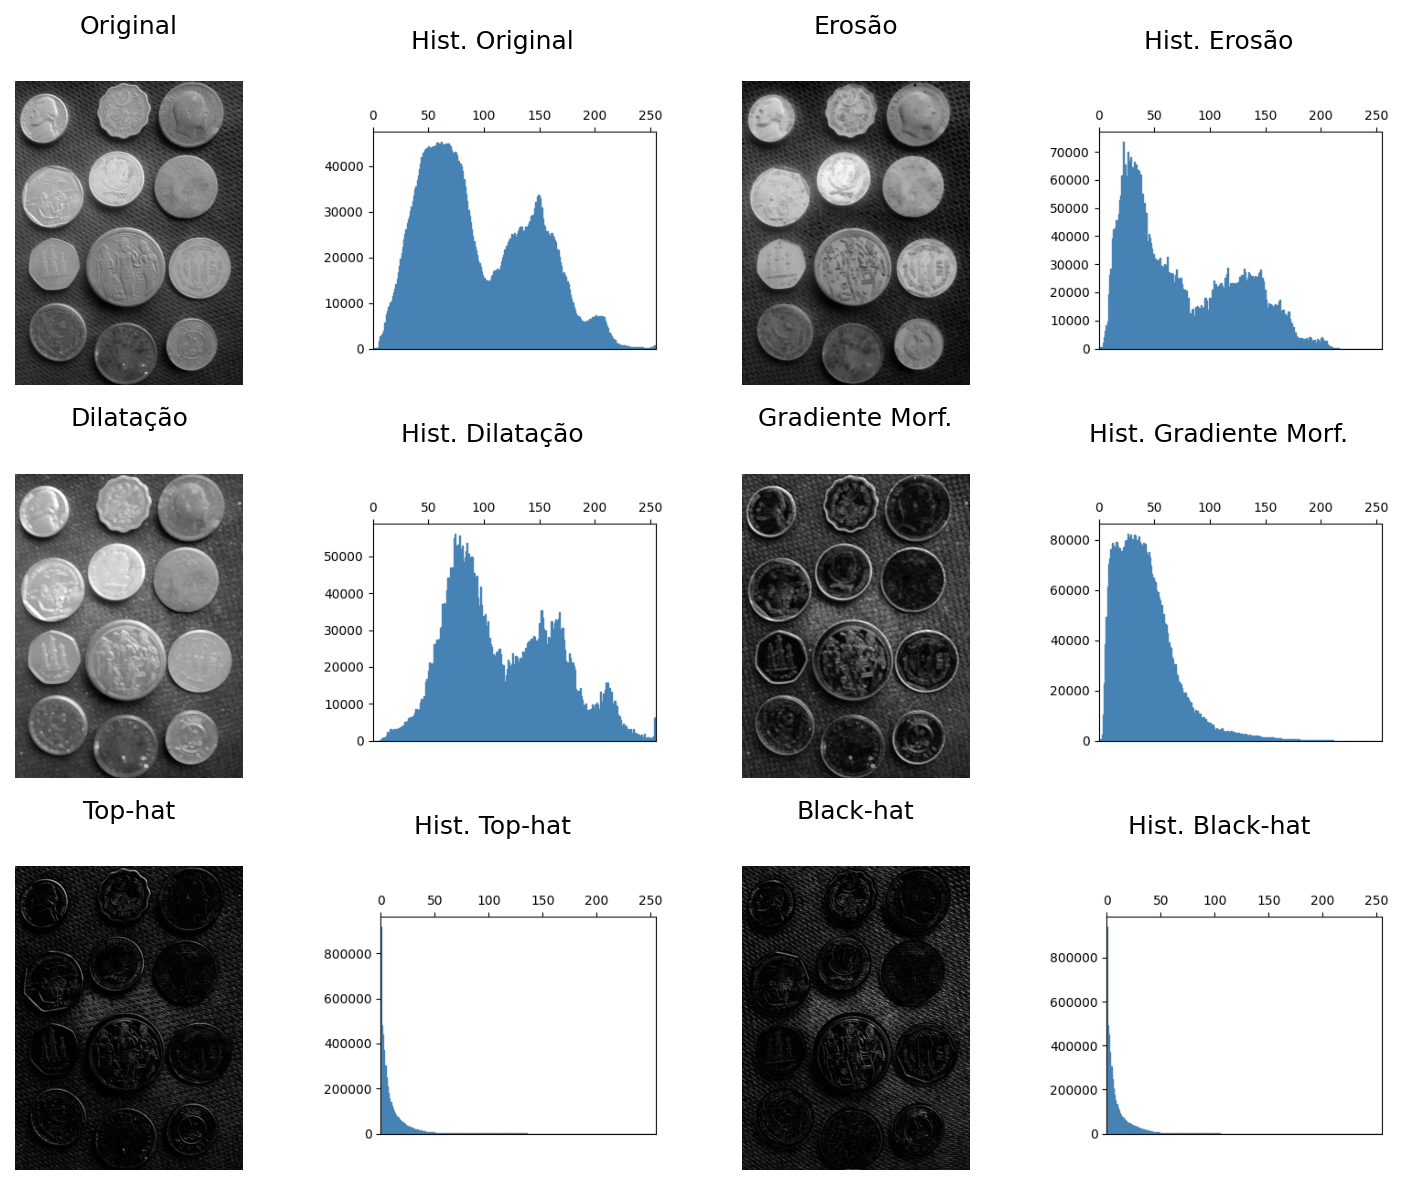

**Figura 4.14:** Morfologia em tons de cinza e seus respectivos histogramas. A erosão reduz intensidades locais, a dilatação as amplia, o gradiente destaca bordas, e os operadores Top-hat e Black-hat evidenciam detalhes locais brilhantes e escuros. Elemento estruturante: disco de diâmetro 19.


In [ ]:
import io
import matplotlib.pyplot as plt
import numpy as np

def fig2img(fig):
    b = io.BytesIO(); fig.savefig(b, format='png', dpi=100); plt.close(fig); b.seek(0)
    return (plt.imread(b)[:, :, :3] * 255).astype(np.uint8)

def plot_hist(img, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    h = mm.hist(img)
    # CORREÇÃO: range usa len(h) dinamicamente para casar com o retorno da biblioteca
    ax.bar(range(len(h)), h, color='steelblue', width=1, edgecolor='steelblue')
    ax.set(xlim=(0, 255)); plt.tight_layout()
    return fig2img(fig)

# 1. Processamento morfológico base
B = mm.sedisk(19)
operadores = [
    ("Original", img_coins_gray),
    ("Erosão", mm.ero(img_coins_gray, B)),
    ("Dilatação", mm.dil(img_coins_gray, B)),
    ("Gradiente Morf.", mm.gradm(img_coins_gray, B)),
    ("Top-hat", mm.tophat(img_coins_gray, B)),
    ("Black-hat", mm.blackhat(img_coins_gray, B))
]

# 2. Montagem dinâmica do par: [Imagem, Histograma]
imgs, titles = [], []
for nome, img in operadores:
    imgs += [img, plot_hist(img, f"Hist. {nome}")]
    titles += [nome, f"Hist. {nome}"]

# 3. Exibição final em grade de duas colunas (Imagem | Histograma)
mm.show(imgs, titles=titles, cols=4, figsize=(10, 8))

Os operadores morfológicos apresentados anteriormente serão agora utilizados como ferramentas de refinamento e geração de marcadores para métodos de segmentação mais avançados, apresentados a seguir.

## 4.4 Segmentação de Imagens: Fundamentação e Taxonomia

A **segmentação de imagens** consiste em dividir a imagem em regiões associadas a objetos ou estruturas de interesse. Em PDI, ela representa a transição entre o processamento de baixo nível — como filtragem e realce — e etapas de análise mais avançadas, como extração de características, reconhecimento e interpretação da cena.

Formalmente, o objetivo da segmentação consiste em decompor o domínio espacial completo de uma imagem, denotado por $\Omega$, em uma partição de subconjuntos $\{R_1, R_2, \ldots, R_n\}$ que satisfaça simultaneamente os critérios de **completeza** e **disjunção**:

<a id="eq-04-particao"></a>
$$
\bigcup_{i=1}^{n} R_i = \Omega, \qquad R_i \cap R_j = \emptyset \quad \forall\, i \neq j \tag{4.15}
$$


Além das propriedades de completeza e disjunção expressas na [Equação 4.15](#eq-04-particao), cada sub-região $R_i$ deve constituir um domínio **homogêneo** segundo um predicado de similaridade definido sobre propriedades locais — intensidade, cor ou textura — e, simultaneamente, ser **distinta** das regiões adjacentes.

As técnicas de segmentação podem ser organizadas em diferentes famílias. Neste capítulo serão enfatizadas as abordagens resumidas na [Tabela 4.5](#tbl-04-segmentacao), fundamentadas principalmente em critérios de intensidade, conectividade e proximidade espacial.

<a id="tbl-04-segmentacao"></a>

**Tabela 4.5:** Taxonomia simplificada das principais abordagens de segmentação e refinamento estudadas neste capítulo.

| Abordagem | Critério de Segmentação | Operadores de Referência |
| :--- | :--- | :--- |
| **Limiarização** | Particionamento do espaço de intensidades | Critério de Otsu, limiarização global e local |
| **Morfologia Matemática** | Relações espaciais definidas por elementos/funções estruturantes | Erosão, dilatação, abertura, fechamento e reconstrução |
| **Baseada em Regiões** | Homogeneidade local e conectividade espacial | Rotulação de componentes conexos, Transformada de Distância e *Watershed* |


Até este ponto, o desenvolvimento prático concentrou-se na **limiarização**, por meio da combinação entre equalização adaptativa CLAHE e o método global de Otsu. Essa etapa foi complementada por operadores de **reconstrução morfológica** baseados em dilatações geodésicas, implementados pelas funções `mm.infrec`, `mm.clohole` e `mm.edgeoff`, produzindo uma máscara binária limpa e adequada para análise.

Contudo, em cenários onde objetos distintos aparecem conectados na máscara binária — seja por contato físico, sobreposição parcial ou por pontes estreitas de pixels produzidas pela segmentação —, a limiarização deixa de ser suficiente para individualizar cada objeto. Nesses casos, múltiplos objetos passam a compor um único componente conexo, dificultando etapas posteriores de medição e interpretação.

Para superar essa limitação, as próximas seções introduzem três ferramentas complementares: a **Rotulação de Componentes Conexos**, a **Transformada de Distância** e o algoritmo de segmentação por ***Watershed*** baseado em marcadores. Em conjunto, essas técnicas permitem separar objetos adjacentes, identificar regiões individualmente e extrair descritores geométricos consistentes para análise quantitativa.

### 4.4.1 Rotulação

A **rotulação de componentes conexas** (*connected component labeling*) é o operador que atribui um identificador inteiro único a cada conjunto de pixels pertencentes à mesma componente conexa em uma imagem binária.

> ### 📝 Definição formal
>
> Dada uma imagem binária $f$ e uma relação de conectividade definida por um elemento estruturante $B$ (tipicamente conectividade-4 ou conectividade-8), o algoritmo de rotulação da [Figura 4.15](#fig-04-sim-alg-rotulagem2) produz uma imagem $g$ na qual todos os pixels pertencentes à mesma componente conexa recebem o mesmo rótulo inteiro positivo, enquanto pixels pertencentes a componentes distintas recebem rótulos diferentes.

A conectividade define quais pixels são considerados vizinhos diretos de um pixel $(x,y)$. As definições mais utilizadas são:

* **Conectividade-4:** considera apenas os quatro vizinhos ortogonais (norte, sul, leste e oeste).
* **Conectividade-8:** considera os quatro vizinhos ortogonais e os quatro diagonais, totalizando oito vizinhos.

A escolha da conectividade influencia diretamente a formação das componentes conexas e, consequentemente, o resultado da rotulação, como ilustrado na [Figura 4.17](#fig-04-rotulacao-didatico). Um exemplo adicional pode ser explorado interativamente no simulador apresentado na [Figura 4.16](#fig-04-sim-04-rotulacao).

A implementação em `morph.py` disponibiliza duas versões desse operador. A função `mm.label0` reproduz explicitamente o algoritmo de *flood-fill* utilizando uma pilha e permite controlar a conectividade por meio do elemento estruturante adotado. Já `mm.label` delega a operação à implementação otimizada do OpenCV (`cv2.connectedComponents`). Em ambos os casos, o resultado é uma imagem rotulada na qual cada componente conexa recebe um identificador inteiro distinto.

In [ ]:
# @title { display-mode: "form" }
# Prefixo exclusivo para evitar conflito com outras células do notebook
PREFIX = "lbl2"

from IPython.display import HTML
HTML(f'''
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:var(--font-sans)}}
.-tabs{{display:flex;gap:6px;margin-bottom:20px;flex-wrap:wrap}}
.{PREFIX}-tab{{padding:6px 14px;border-radius:20px;font-size:13px;cursor:pointer;border:0.5px solid var(--color-border-secondary);background:var(--color-background-primary);color:var(--color-text-secondary);transition:all .15s;white-space:nowrap}}
.{PREFIX}-tab.active{{background:var(--color-text-primary);color:var(--color-background-primary);border-color:transparent}}
.{PREFIX}-panel{{display:none}}.{PREFIX}-panel.active{{display:block}}

.algo-wrap{{background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.algo-header{{padding:14px 20px;border-bottom:0.5px solid var(--color-border-tertiary);display:flex;align-items:center;gap:10px}}
.algo-icon{{width:32px;height:32px;border-radius:var(--border-radius-md);display:flex;align-items:center;justify-content:center;font-size:16px;background:#EEEDFE;color:#534AB7}}
.algo-title{{font-size:14px;font-weight:500;color:var(--color-text-primary);text-align:left}}
.algo-sub{{font-size:12px;color:var(--color-text-secondary);margin-top:1px;text-align:left}}
.algo-body{{padding:20px;text-align:left}}

.step{{display:flex;gap:12px;margin-bottom:14px;align-items:flex-start}}
.step:last-child{{margin-bottom:0}}
.step-num{{min-width:24px;height:24px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0;margin-top:1px}}
.step-text{{font-size:13.5px;line-height:1.65;color:var(--color-text-primary);text-align:left}}
.step-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 6px;border-radius:4px;color:var(--color-text-primary)}}
.step-sub{{margin-top:8px;border-left:2px solid var(--color-border-secondary);padding-left:12px;display:flex;flex-direction:column;gap:5px}}
.step-sub-item{{font-size:13px;color:var(--color-text-secondary);line-height:1.55;text-align:left}}
.step-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.while-box{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);padding:11px 13px;margin-top:8px;text-align:left}}
.while-head{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.06em;margin-bottom:7px}}
.note{{margin-top:16px;padding-top:12px;border-top:0.5px solid var(--color-border-tertiary);font-size:12px;color:var(--color-text-secondary);font-style:italic;line-height:1.5;text-align:left}}

.num-teal{{background:#E1F5EE;color:#0F6E56}}
.num-purple{{background:#EEEDFE;color:#534AB7}}
.num-amber{{background:#FAEEDA;color:#854F0B}}
.num-coral{{background:#FAECE7;color:#993C1D}}
.num-blue{{background:#E6F1FB;color:#185FA5}}
.num-gray{{background:var(--color-background-secondary);color:var(--color-text-secondary)}}

.card-step{{display:flex;border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);overflow:hidden;margin-bottom:8px}}
.card-step:last-child{{margin-bottom:0}}
.card-badge{{min-width:48px;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0}}
.card-content{{padding:10px 14px;flex:1;text-align:left}}
.card-label{{font-size:10px;font-weight:500;letter-spacing:.08em;text-transform:uppercase;margin-bottom:3px}}
.card-text{{font-size:13.5px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.card-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.card-sub{{margin-top:6px;display:flex;flex-direction:column;gap:3px}}
.card-sub-item{{font-size:12.5px;color:var(--color-text-secondary);padding-left:10px;border-left:2px solid var(--color-border-secondary);line-height:1.5;text-align:left}}
.card-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 4px;border-radius:3px;color:var(--color-text-primary)}}

.tl{{position:relative;padding:4px 0 4px 36px;text-align:left}}
.tl-line{{position:absolute;left:11px;top:20px;bottom:20px;width:1.5px;background:var(--color-border-secondary);border-radius:2px}}
.tl-step{{display:flex;gap:0;margin-bottom:18px;position:relative}}
.tl-step:last-child{{margin-bottom:0}}
.tl-dot-wrap{{position:absolute;left:-36px;top:2px;display:flex;flex-direction:column;align-items:center;gap:3px}}
.tl-dot{{width:14px;height:14px;border-radius:50%;border:2px solid var(--color-border-secondary);background:var(--color-background-primary);transition:all .2s;z-index:1}}
.tl-step:hover .tl-dot{{background:var(--color-text-primary);border-color:var(--color-text-primary)}}
.tl-num{{font-size:9px;color:var(--color-text-secondary);font-weight:500;letter-spacing:.04em}}
.tl-title{{font-size:13.5px;font-weight:500;color:var(--color-text-primary);margin-bottom:3px;text-align:left}}
.tl-desc{{font-size:13px;color:var(--color-text-secondary);line-height:1.6;text-align:left}}
.tl-desc code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}

.code-wrap{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.code-bar{{background:var(--color-background-secondary);padding:10px 16px;display:flex;align-items:center;justify-content:space-between;border-bottom:0.5px solid var(--color-border-tertiary)}}
.code-lang{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.08em}}
.code-body{{padding:18px 20px;overflow-x:auto;text-align:left}}
.code-body pre{{font-family:var(--font-mono);font-size:13px;line-height:1.75;color:var(--color-text-primary);margin:0;white-space:pre;text-align:left}}
.kw{{color:#7C3AED}} .fn{{color:#0369A1}} .cm{{color:#6B7280;font-style:italic}} .st{{color:#059669}} .num-lit{{color:#DC2626}}

.ann-line{{display:flex;align-items:flex-start;gap:10px;margin-bottom:8px;padding:10px 12px;background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);text-align:left}}
.ann-badge{{min-width:20px;height:20px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:500;flex-shrink:0;margin-top:1px}}
.ann-text{{font-size:13px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.ann-text code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
</style>

<h2 class="sr-only" style="position:absolute;left:-9999px">Algoritmo de rotulação por flood-fill com pilha — painel interativo com HTML e SVG</h2>

<div class="{PREFIX}-tabs" id="{PREFIX}-tabs-container">
  <div class="{PREFIX}-tab" data-idx="0"><i class="ti ti-list-numbers" aria-hidden="true"></i> Passo a passo</div>
  <div class="{PREFIX}-tab" data-idx="1"><i class="ti ti-cards" aria-hidden="true"></i> Cards</div>
  <div class="{PREFIX}-tab" data-idx="2"><i class="ti ti-timeline" aria-hidden="true"></i> Linha do tempo</div>
  <div class="{PREFIX}-tab" data-idx="3"><i class="ti ti-code" aria-hidden="true"></i> Código Python</div>
  <div class="{PREFIX}-tab active" data-idx="4"><i class="ti ti-git-branch" aria-hidden="true"></i> Fluxograma</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-0">
<div class="algo-wrap">
  <div class="algo-header">
    <div class="algo-icon"><i class="ti ti-stack-2" aria-hidden="true"></i></div>
    <div><div class="algo-title">Flood-fill com pilha</div><div class="algo-sub">Rotulagem de componentes conexas</div></div>
  </div>
  <div class="algo-body">
    <div class="step"><div class="step-num num-teal">1</div><div class="step-text">Criar imagem de saída <em>g</em>, inicializada com <code>zeros</code>, mesma dimensão de <em>f</em>.</div></div>
    <div class="step"><div class="step-num num-teal">2</div><div class="step-text">Inicializar contador de rótulos (cor) <code>cor ← 1</code>.</div></div>
    <div class="step"><div class="step-num num-purple">3</div><div class="step-text">Percorrer <em>f</em> em <strong>ordem raster</strong> (coordenadas <code>x</code> e <code>y</code>) até encontrar uma semente: pixel ativo (<code>f[x,y] ≠ 0</code>) ainda não rotulado (<code>g[x,y] = 0</code>).</div></div>
    <div class="step"><div class="step-num num-amber">4</div><div class="step-text">Inserir a semente encontrada na pilha <code>pilha ← [[x,y]]</code>.</div></div>
    <div class="step">
      <div class="step-num num-coral">5</div>
      <div class="step-text">Enquanto a pilha contiver coordenadas (<code>while pilha</code>):
        <div class="step-sub">
          <div class="step-sub-item">Desempilhar pixel atual: <code>i, j ← pilha.pop()</code> e atribuir o rótulo: <code>g[i,j] ← cor</code>.</div>
          <div class="step-sub-item">Buscar vizinhos usando o iterador <code>mm._viz(f,b,i,j)</code>. Se o vizinho for ativo no elemento estruturante (<code>bv ≠ 0</code>), ativo na imagem (<code>f[vy,vx] ≠ 0</code>) e não rotulado (<code>g[vy,vx] = 0</code>), empilhá-lo.</div>
        </div>
      </div>
    </div>
    <div class="step"><div class="step-num num-blue">6</div><div class="step-text">Pilha vazia ⟹ Toda a componente conexa atual foi explorada e rotulada com sucesso.</div></div>
    <div class="step"><div class="step-num num-blue">7</div><div class="step-text">Incrementar o rótulo para a próxima componente: <code>cor ← cor + 1</code> e continuar a varredura raster.</div></div>
    <div class="note">A conectividade (4 ou 8 vizinhos) é definida unicamente pela matriz morfológica <code>b</code> passada como parâmetro, alterando os pixels retornados em <code>mm._viz</code>.</div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-1">
  <div class="card-step">
    <div class="card-badge num-teal">01</div>
    <div class="card-content">
      <div class="card-label" style="color:#0F6E56">Inicialização</div>
      <div class="card-text">Criar matriz de rótulos <code>g</code> preenchida com zeros (fundo). Definir rótulo inicial <code>cor ← 1</code>.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-purple">02</div>
    <div class="card-content">
      <div class="card-label" style="color:#534AB7">Varredura Raster</div>
      <div class="card-text">Percorrer a matriz bidimensional linha por linha, localizando pixels pertencentes ao objeto que ainda não possuem rótulo.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-amber">03</div>
    <div class="card-content">
      <div class="card-label" style="color:#854F0B">Semente inicial</div>
      <div class="card-text">Ao achar um pixel válido, inicializar a estrutura LIFO de busca: <code>pilha = [[x, y]]</code>.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-coral">04</div>
    <div class="card-content">
      <div class="card-label" style="color:#993C1D">Expansão por Flood-Fill</div>
      <div class="card-text">Enquanto houver elementos na pilha:</div>
      <div class="card-sub">
        <div class="card-sub-item">Extrair <code>(i, j)</code> via <code>pop()</code> e marcar <code>g[i, j] = cor</code>.</div>
        <div class="card-sub-item">Inspecionar vizinhança geométrica e adicionar novos candidatos à pilha.</div>
      </div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-blue">05</div>
    <div class="card-content">
      <div class="card-label" style="color:#185FA5">Próxima Componente</div>
      <div class="card-text">Pilha esvaziada ⟹ Incrementar indexador <code>cor ← cor + 1</code> para diferenciar o próximo objeto isolado.</div>
    </div>
  </div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-2">
<div class="tl">
  <div class="tl-line"></div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">01</span></div>
    <div><div class="tl-title">Alocação Espacial</div><div class="tl-desc"><code>g ← zeros_like(f)</code> e definição do primeiro identificador: <code>cor ← 1</code>.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">02</span></div>
    <div><div class="tl-title">Varredura Bidimensional</div><div class="tl-desc">Laços encadeados varrendo as dimensões <code>h</code> e <code>w</code> da imagem.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">03</span></div>
    <div><div class="tl-title">Descoberta de Objeto</div><div class="tl-desc">Filtro condicional localiza pixel ativo não indexado e cria a <code>pilha</code> semente.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">04–05</span></div>
    <div>
      <div class="tl-title">Preenchimento por Região (Flood-fill)</div>
      <div class="while-box">
        <div class="while-head">while pilha</div>
        <div class="step-sub" style="border-color:var(--color-border-tertiary)">
          <div class="step-sub-item">Remover último da pilha <code>(i,j)</code> e aplicar rótulo atual.</div>
          <div class="step-sub-item">Empilhar vizinhos conectados que atendam aos critérios morfológicos de <code>b</code>.</div>
        </div>
      </div>
    </div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">06</span></div>
    <div><div class="tl-title">Fechamento do Objeto</div><div class="tl-desc">Pilha vazia determina o fim do isolamento daquela componente.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">07</span></div>
    <div><div class="tl-title">Atualização do Rótulo</div><div class="tl-desc">Incremento linear: <code>cor ← cor + 1</code>. A varredura raster continua do ponto onde parou.</div></div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-3">
<div class="code-wrap">
  <div class="code-bar">
    <span class="code-lang"><i class="ti ti-brand-python" aria-hidden="true" style="font-size:14px;vertical-align:-2px;margin-right:5px"></i>label0.py</span>
    <span style="font-size:11px;color:var(--color-text-secondary)">flood-fill com pilha</span>
  </div>
  <div class="code-body">
<pre><span class="kw">def</span> <span class="fn">label0</span>(f, b=np.ones((<span class="num-lit">3</span>,<span class="num-lit">3</span>),dtype=<span class="st">'uint8'</span>)):
    <span class="cm">"""Rotulagem por flood-fill com pilha."""</span>
    h, w = f.shape
    g = np.zeros(f.shape, dtype=<span class="kw">int</span>)
    cor = <span class="num-lit">1</span>
    <span class="kw">for</span> x <span class="kw">in</span> <span class="fn">range</span>(h):
        <span class="kw">for</span> y <span class="kw">in</span> <span class="fn">range</span>(w):
            <span class="kw">if</span> f[x,y] <span class="kw">and not</span> g[x,y]:
                pilha = [[x,y]]
                <span class="kw">while</span> pilha:
                    i,j = pilha.pop(); g[i,j] = cor
                    <span class="kw">for</span> vy,vx,bv <span class="kw">in</span> mm._viz(f,b,i,j):
                        <span class="kw">if</span> bv <span class="kw">and</span> f[vy,vx] <span class="kw">and not</span> g[vy,vx]:
                            pilha.append([vy,vx])
                cor += <span class="num-lit">1</span>
    <span class="kw">return</span> g</pre>
  </div>
</div>
<div style="margin-top:16px;display:flex;flex-direction:column;gap:8px;text-align:left">
  <div class="ann-line"><div class="ann-badge num-teal">1</div><div class="ann-text"><code>g = np.zeros(f.shape, dtype=int)</code> — Inicializa a matriz de saída com zeros. Zeros representam o fundo invariável.</div></div>
  <div class="ann-line"><div class="ann-badge num-purple">2</div><div class="ann-text"><code>mm._viz(f, b, i, j)</code> — O iterador morfológico avalia a conectividade. Passando <code>B_cruz</code> a busca expande em 4-vizinhança; passando quadrado (<code>ones</code>) expande em 8-vizinhança.</div></div>
  <div class="ann-line"><div class="ann-badge num-amber">3</div><div class="ann-text"><code>pilha.pop()</code> — Remove o último par de coordenadas inserido, caracterizando um comportamento LIFO de busca em profundidade (DFS) para varrer o objeto de forma contígua.</div></div>
  <div class="ann-line"><div class="ann-badge num-coral">4</div><div class="ann-text"><code>cor += 1</code> — O incremento ocorre estritamente fora do laço <code>while</code>, garantindo que o mesmo número marque toda a extensão da componente concluída antes de passar para a próxima semente raster.</div></div>
</div>
</div>

<div class="{PREFIX}-panel active" id="{PREFIX}-p-4">
<svg viewBox="0 0 580 820" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:580px;display:block;margin:0 auto">
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#888780"/></marker>
    <marker id="arr-b" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#534AB7"/></marker>
    <marker id="arr-r" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#993C1D"/></marker>
    <marker id="arr-g" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#0F6E56"/></marker>
  </defs>
  
  <ellipse cx="280" cy="36" rx="60" ry="22" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
  <text x="280" y="41" text-anchor="middle" font-size="13" font-weight="500" fill="#085041">início</text>
  
  <rect x="160" y="80" width="240" height="48" rx="6" fill="#E1F5EE" stroke="#9FE1CB" stroke-width="1"/>
  <text x="280" y="99" text-anchor="middle" font-size="12" font-weight="500" fill="#0F6E56">inicializar saída</text>
  <text x="280" y="116" text-anchor="middle" font-size="12" fill="#085041">g ← zeros(f.shape);  cor ← 1</text>
  
  <rect x="160" y="150" width="240" height="48" rx="6" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="280" y="169" text-anchor="middle" font-size="12" font-weight="500" fill="#534AB7">varredura raster</text>
  <text x="280" y="186" text-anchor="middle" font-size="12" fill="#3C3489">próximo pixel (x, y) em f</text>
  
  <polygon points="280,224 370,252 280,280 190,252" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="1"/>
  <text x="280" y="248" text-anchor="middle" font-size="11.5" fill="#444441">imagem toda</text>
  <text x="280" y="264" text-anchor="middle" font-size="11.5" fill="#444441">varrida?</text>
  
  <ellipse cx="450" cy="252" rx="52" ry="22" fill="#EAF3DE" stroke="#97C459" stroke-width="1"/>
  <text x="450" y="257" text-anchor="middle" font-size="13" font-weight="500" fill="#27500A">fim</text>
  
  <polygon points="280,304 380,334 280,364 180,334" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="280" y="329" text-anchor="middle" font-size="11.5" fill="#3C3489">f[x,y] ≠ 0  e</text>
  <text x="280" y="344" text-anchor="middle" font-size="11.5" fill="#3C3489">g[x,y] = 0?</text>
  
  <rect x="170" y="388" width="220" height="44" rx="6" fill="#FAEEDA" stroke="#FAC775" stroke-width="1"/>
  <text x="280" y="406" text-anchor="middle" font-size="12" font-weight="500" fill="#854F0B">inserir semente</text>
  <text x="280" y="422" text-anchor="middle" font-size="12" fill="#633806">pilha ← [[x, y]]</text>
  
  <polygon points="280,456 370,486 280,516 190,486" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="491" text-anchor="middle" font-size="11.5" fill="#712B13">pilha vazia?</text>
  
  <rect x="160" y="542" width="240" height="48" rx="6" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="561" text-anchor="middle" font-size="12" font-weight="500" fill="#993C1D">i, j ← pilha.pop()</text>
  <text x="280" y="578" text-anchor="middle" font-size="12" fill="#712B13">g[i, j] ← cor</text>
  
  <rect x="150" y="614" width="260" height="60" rx="6" fill="#E6F1FB" stroke="#85B7EB" stroke-width="1"/>
  <text x="280" y="634" text-anchor="middle" font-size="12" font-weight="500" fill="#185FA5">inspecionar vizinhos</text>
  <text x="280" y="650" text-anchor="middle" font-size="12" fill="#0C447C">se ativo e não rotulado</text>
  <text x="280" y="666" text-anchor="middle" font-size="12" fill="#0C447C">→ pilha.append([vy, vx])</text>
  
  <rect x="435" y="466" width="110" height="40" rx="6" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="490" y="482" text-anchor="middle" font-size="12" font-weight="500" fill="#534AB7">cor ← cor + 1</text>
  <text x="490" y="496" text-anchor="middle" font-size="10.5" fill="#3C3489">próximo rótulo</text>

  <line x1="280" y1="58" x2="280" y2="80" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="128" x2="280" y2="150" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="198" x2="280" y2="224" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  
  <line x1="370" y1="252" x2="398" y2="252" stroke="#3B6D11" stroke-width="1.2" marker-end="url(#arr-g)"/>
  <text x="384" y="245" text-anchor="middle" font-size="11" fill="#3B6D11">sim</text>
  
  <line x1="280" y1="280" x2="280" y2="304" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  
  <path d="M 180,334 L 130,334 L 130,174 L 160,174" fill="none" stroke="#534AB7" stroke-width="1.2" marker-end="url(#arr-b)"/>
  <text x="152" y="327" text-anchor="middle" font-size="11" fill="#534AB7">não</text>
  
  <line x1="280" y1="364" x2="280" y2="388" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <text x="292" y="378" font-size="11" fill="#534AB7">sim</text>
  
  <line x1="280" y1="432" x2="280" y2="456" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  
  <line x1="280" y1="516" x2="280" y2="542" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <text x="292" y="531" font-size="11" fill="#993C1D">não</text>
  
  <line x1="280" y1="590" x2="280" y2="614" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  
  <path d="M 280,674 L 280,694 L 110,694 L 110,486 L 190,486" fill="none" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  
  <line x1="370" y1="486" x2="435" y2="486" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <text x="402" y="479" text-anchor="middle" font-size="11" fill="#993C1D">sim</text>
  
  <path d="M 490,466 L 490,174 L 400,174" fill="none" stroke="#534AB7" stroke-width="1.2" marker-end="url(#arr-b)"/>
</svg>
</div>

<script>
(function() {{
  var container = document.getElementById('{PREFIX}-tabs-container');
  if (!container) return;
  
  var tabs = container.querySelectorAll('.{PREFIX}-tab');
  var panels = [
    document.getElementById('{PREFIX}-p-0'),
    document.getElementById('{PREFIX}-p-1'),
    document.getElementById('{PREFIX}-p-2'),
    document.getElementById('{PREFIX}-p-3'),
    document.getElementById('{PREFIX}-p-4')
  ];

  tabs.forEach(function(tab) {{
    tab.onclick = function() {{
      var idx = parseInt(this.getAttribute('data-idx'));
      
      tabs.forEach(function(t) {{ t.classList.remove('active'); }});
      panels.forEach(function(p) {{ if(p) p.classList.remove('active'); }});
      
      this.classList.add('active');
      if(panels[idx]) panels[idx].classList.add('active');
    }};
  }});
}})();
</script>
''')

**Figura 4.15:** Algoritmo de rotulação por *flood-fill* com pilha.


O auxiliar `_viz` itera sobre a janela estruturante `b` centrada em $(i,j)$, gerando somente os vizinhos válidos dentro dos limites da imagem — a conectividade desejada é inteiramente determinada pela forma de `b` passada ao algoritmo.

**Exemplo didático — efeito da conectividade:**

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-rotulacao" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-04-rotulacao * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-04-rotulacao canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; cursor: crosshair; background: #ffffff; }
  #sim-04-rotulacao button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: all 0.15s ease; font-weight: 600; }
  #sim-04-rotulacao button:hover { background: #e8dfcf; }
  #sim-04-rotulacao button.rt_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-04-rotulacao .rt_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .rt_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .rt_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-bottom: 14px; }
  .rt_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 10px; text-align: center; }
  .rt_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .rt_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🪙 Simulador: Rotulação de Componentes Conexas</span>
  <span class="rt_pill">flood-fill com pilha</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Estatísticas -->
  <div class="rt_grid_stats">
    <div class="rt_stat_box">
      <div class="rt_stat_label">Pixels Ativos</div>
      <div id="rt_statPx" class="rt_stat_value" style="color:#2980b9;">0</div>
    </div>
    <div class="rt_stat_box">
      <div class="rt_stat_label">Componentes</div>
      <div id="rt_statCC" class="rt_stat_value" style="color:#27ae60;">0</div>
    </div>
    <div class="rt_stat_box">
      <div class="rt_stat_label">Conectividade</div>
      <div id="rt_statConn" class="rt_stat_value" style="color:#b9770e;">4</div>
    </div>
    <div class="rt_stat_box">
      <div class="rt_stat_label">Passo Raster</div>
      <div id="rt_statStep" class="rt_stat_value" style="color:#c0392b;">–</div>
    </div>
  </div>

  <!-- Layout Principal em 2 Colunas -->
  <div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
    
    <!-- Canvas e Legenda -->
    <div style="flex:2; min-width:260px; background:#fafaf7; border:1px solid #e9e3d3; border-radius:12px; padding:12px; text-align:center;">
      <canvas id="rt_ccCanvas" style="margin:0 auto;"></canvas>
      <div style="font-size:10px; color:#8a8371; margin-top:8px;">
        🖱️ Clique para ativar/desativar pixels · Arraste para pintar
      </div>
      <div style="display:flex; flex-wrap:wrap; gap:8px; margin-top:10px; justify-content:center;" id="rt_legendBox"></div>
    </div>

    <!-- Painel de Controles Lateral -->
    <div style="flex:1; min-width:220px; display:flex; flex-direction:column; gap:12px;">
      
      <!-- Seletor de Conectividade -->
      <div class="rt_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Conectividade
        </div>
        <div style="display:flex; gap:6px;">
          <button id="rt_btn4" class="rt_active" onclick="window.rt_setConn(4)" style="flex:1; justify-content:center;">C-4</button>
          <button id="rt_btn8" onclick="window.rt_setConn(8)" style="flex:1; justify-content:center;">C-8</button>
        </div>
        <div id="rt_connDesc" style="font-size:9.5px; color:#8a8371; margin-top:6px; line-height:1.4;">
          4 vizinhos ortogonais: N, S, L, O
        </div>
      </div>

      <!-- Seletor de Modo de Visualização -->
      <div class="rt_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Visualização
        </div>
        <div style="display:flex; gap:6px;">
          <button id="rt_btnLabel" class="rt_active" onclick="window.rt_setMode('label')" style="flex:1; justify-content:center;">Rótulos</button>
          <button id="rt_btnAnim" onclick="window.rt_setMode('anim')" style="flex:1; justify-content:center;">Animado</button>
        </div>
      </div>

      <!-- Controles de Animação -->
      <div id="rt_animCtrl" class="rt_panel" style="display:none;">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Passo a Passo
        </div>
        <div style="display:flex; gap:6px; margin-bottom:8px;">
          <button onclick="window.rt_animStep(-1)" style="flex:1; justify-content:center;">◀</button>
          <button id="rt_btnPlay" onclick="window.rt_togglePlay()" style="flex:1; justify-content:center;">▶</button>
          <button onclick="window.rt_animStep(1)" style="flex:1; justify-content:center;">▶▶</button>
        </div>
        <div style="display:flex; align-items:center; gap:8px;">
          <label style="font-size:9.5px; color:#8a8371; font-weight:700;">Vel.</label>
          <input type="range" id="rt_speedSlider" min="1" max="10" value="5" style="flex:1; max-width:160px; height:4px; cursor:pointer;">
        </div>
      </div>

      <!-- Status da Animação -->
      <div id="rt_animStatus" class="rt_panel" style="display:none;">
        <div id="rt_animTitle" style="font-size:11px; font-weight:700; margin-bottom:3px; color:#26241d;">–</div>
        <div id="rt_animDesc" style="font-size:9.5px; color:#8a8371; line-height:1.4;">–</div>
      </div>

      <!-- Exemplos / Presets -->
      <div class="rt_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Exemplos Predefinidos
        </div>
        <div style="display:flex; flex-direction:column; gap:5px;">
          <button onclick="window.rt_loadPreset('diagonal')" style="justify-content:flex-start;">■ Diagonal (C-4 vs C-8)</button>
          <button onclick="window.rt_loadPreset('letters')" style="justify-content:flex-start;">A Letras Separadas</button>
          <button onclick="window.rt_loadPreset('ring')" style="justify-content:flex-start;">◎ Anel com Buraco</button>
        </div>
      </div>

      <!-- Botão de Limpeza -->
      <button onclick="window.rt_clearGrid()" style="justify-content:center; border-color:#f5b7b1; color:#c0392b; background:#fdecea;">
        🗑️ Limpar Grade
      </button>

    </div>

  </div>

</div>
</div>

<script>
(function(){
  function initSim04RotulacaoCC(root){
    if (!root || root.dataset.sim04RotulacaoCCInit) return;
    root.dataset.sim04RotulacaoCCInit = "1";

    const rt_COLS = 12, rt_ROWS = 12, rt_CELL = 22, rt_PAD = 10;
    const rt_W = rt_COLS * rt_CELL + rt_PAD * 2, rt_H = rt_ROWS * rt_CELL + rt_PAD * 2;
    const rt_cv = root.querySelector('#rt_ccCanvas');
    rt_cv.width = rt_W; 
    rt_cv.height = rt_H;
    const rt_ctx = rt_cv.getContext('2d');

    const rt_PALETTE = [
      ['#2980b9', '#ebf4fd', '#a9cce3', '#042c53'],
      ['#27ae60', '#eafaf1', '#a3e4d7', '#04342C'],
      ['#b9770e', '#fef5e7', '#f8c471', '#412402'],
      ['#c0392b', '#fdecea', '#f5b7b1', '#4A1B0C'],
      ['#8e44ad', '#f5eef8', '#d7bde2', '#4B1528'],
      ['#16a085', '#e8f8f5', '#a3e4d7', '#0e6251'],
      ['#d35400', '#fbeee6', '#f5cba7', '#7e5109'],
      ['#2c3e50', '#ebedef', '#bdc3c7', '#17202a']
    ];

    let rt_grid = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
    let rt_connectivity = 4;
    let rt_mode = 'label';
    let rt_painting = false;
    let rt_paintVal = 1;

    let rt_animSteps = [];
    let rt_animIdx = 0;
    let rt_playing = false;
    let rt_playTimer = null;

    function rt_neighbors(r, c, conn) {
      const n = [[r-1,c],[r+1,c],[r,c-1],[r,c+1]];
      if (conn === 8) n.push([r-1,c-1],[r-1,c+1],[r+1,c-1],[r+1,c+1]);
      return n.filter(([nr,nc]) => nr>=0 && nr<rt_ROWS && nc>=0 && nc<rt_COLS);
    }

    function rt_label(g, conn) {
      const lbl = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      let c = 1;
      for (let r=0; r<rt_ROWS; r++) {
        for (let cc=0; cc<rt_COLS; cc++) {
          if (g[r][cc] && !lbl[r][cc]) {
            const stack = [[r,cc]];
            while (stack.length) {
              const [i,j] = stack.pop();
              if (lbl[i][j]) continue;
              lbl[i][j] = c;
              for (const [ni,nj] of rt_neighbors(i, j, conn))
                if (g[ni][nj] && !lbl[ni][nj]) stack.push([ni,nj]);
            }
            c++;
          }
        }
      }
      return lbl;
    }

    function rt_buildAnimSteps(g, conn) {
      const steps = [];
      const lbl = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      let c = 1;
      for (let r=0; r<rt_ROWS; r++) {
        for (let cc=0; cc<rt_COLS; cc++) {
          steps.push({type:'raster', r, cc, lbl:lbl.map(a => [...a]), c});
          if (g[r][cc] && !lbl[r][cc]) {
            steps.push({type:'found', r, cc, c, lbl:lbl.map(a => [...a])});
            const stack = [[r,cc]];
            while (stack.length) {
              const [i,j] = stack.pop();
              if (lbl[i][j]) continue;
              lbl[i][j] = c;
              steps.push({type:'fill', i, j, c, lbl:lbl.map(a => [...a])});
              for (const [ni,nj] of rt_neighbors(i, j, conn))
                if (g[ni][nj] && !lbl[ni][nj]) stack.push([ni,nj]);
            }
            c++;
          }
        }
      }
      steps.push({type:'done', lbl:lbl.map(a => [...a]), c:c-1});
      return steps;
    }

    function rt_getColor(c) {
      const p = rt_PALETTE[(c-1) % rt_PALETTE.length];
      return { fill: p[1], stroke: p[0], text: p[0] };
    }

    function rt_drawLabel() {
      const lbl = rt_label(rt_grid, rt_connectivity);
      const numCC = Math.max(0, ...lbl.flat());
      rt_ctx.clearRect(0, 0, rt_W, rt_H);

      for (let r=0; r<rt_ROWS; r++) {
        for (let c=0; c<rt_COLS; c++) {
          const x = rt_PAD + c * rt_CELL, y = rt_PAD + r * rt_CELL;
          const l = lbl[r][c];
          const active = rt_grid[r][c];

          if (active && l) {
            const col = rt_getColor(l);
            rt_ctx.fillStyle = col.fill; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
            rt_ctx.strokeStyle = col.stroke; rt_ctx.lineWidth = 1.5; rt_ctx.setLineDash([]);
            rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
            rt_ctx.fillStyle = col.text;
            rt_ctx.font = 'bold 11px monospace';
            rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
            rt_ctx.fillText(l, x+rt_CELL/2, y+rt_CELL/2);
          } else {
            rt_ctx.fillStyle = '#fafaf7'; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
            rt_ctx.strokeStyle = '#e4dcc8'; rt_ctx.lineWidth = 0.5; rt_ctx.setLineDash([]);
            rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
            rt_ctx.fillStyle = '#8a8371';
            rt_ctx.font = '9px monospace';
            rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
            rt_ctx.fillText('0', x+rt_CELL/2, y+rt_CELL/2);
          }

          if (r===0) { rt_ctx.fillStyle='#8a8371'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(c, x+rt_CELL/2, rt_PAD/2); }
          if (c===0) { rt_ctx.fillStyle='#8a8371'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(r, rt_PAD/2, y+rt_CELL/2); }
        }
      }

      const numPx = rt_grid.flat().filter(Boolean).length;
      root.querySelector('#rt_statPx').textContent = numPx;
      root.querySelector('#rt_statCC').textContent = numCC;
      root.querySelector('#rt_statConn').textContent = rt_connectivity;
      root.querySelector('#rt_statStep').textContent = '–';
      rt_buildLegend(numCC);
    }

    function rt_drawAnimFrame() {
      if (!rt_animSteps.length) return;
      const step = rt_animSteps[Math.min(rt_animIdx, rt_animSteps.length-1)];
      const lbl = step.lbl;
      const numCC = step.c-1 || 0;

      rt_ctx.clearRect(0, 0, rt_W, rt_H);

      for (let r=0; r<rt_ROWS; r++) {
        for (let c=0; c<rt_COLS; c++) {
          const x = rt_PAD + c * rt_CELL, y = rt_PAD + r * rt_CELL;
          const l = lbl[r][c];
          const active = rt_grid[r][c];

          if (active && l) {
            const col = rt_getColor(l);
            rt_ctx.fillStyle = col.fill; rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
            rt_ctx.strokeStyle = col.stroke; rt_ctx.lineWidth = 1.5; rt_ctx.setLineDash([]);
            rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
            rt_ctx.fillStyle = col.text;
            rt_ctx.font = 'bold 11px monospace';
            rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
            rt_ctx.fillText(l, x+rt_CELL/2, y+rt_CELL/2);
          } else if (active) {
            rt_ctx.fillStyle = '#fef5e7';
            rt_ctx.fillRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
            rt_ctx.strokeStyle = '#b9770e'; rt_ctx.lineWidth = 1; rt_ctx.setLineDash([2,2]);
            rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
            rt_ctx.setLineDash([]);
            rt_ctx.fillStyle = '#b9770e';
            rt_ctx.font = '9px monospace';
            rt_ctx.textAlign = 'center'; rt_ctx.textBaseline = 'middle';
            rt_ctx.fillText('?', x+rt_CELL/2, y+rt_CELL/2);
          } else {
            rt_ctx.fillStyle = '#fafaf7';
            rt_ctx.strokeStyle = '#e4dcc8'; rt_ctx.lineWidth = 0.5; rt_ctx.setLineDash([]);
            rt_ctx.strokeRect(x+0.5, y+0.5, rt_CELL-1, rt_CELL-1);
          }

          if (r===0) { rt_ctx.fillStyle='#8a8371'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(c, x+rt_CELL/2, rt_PAD/2); }
          if (c===0) { rt_ctx.fillStyle='#8a8371'; rt_ctx.font='8px monospace'; rt_ctx.textAlign='center'; rt_ctx.fillText(r, rt_PAD/2, y+rt_CELL/2); }
        }
      }

      if (step.type==='raster' || step.type==='found') {
        const x = rt_PAD + step.cc * rt_CELL, y = rt_PAD + step.r * rt_CELL;
        rt_ctx.strokeStyle = '#c0392b'; rt_ctx.lineWidth = 2; rt_ctx.setLineDash([]);
        rt_ctx.strokeRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
      }
      if (step.type==='fill') {
        const x = rt_PAD + step.j * rt_CELL, y = rt_PAD + step.i * rt_CELL;
        rt_ctx.strokeStyle = '#b9770e'; rt_ctx.lineWidth = 2; rt_ctx.setLineDash([]);
        rt_ctx.strokeRect(x+1, y+1, rt_CELL-2, rt_CELL-2);
      }

      const descriptions = {
        raster: 'Varredura: (' + step.r + ',' + (step.cc||0) + ') — buscando não rotulado',
        found: 'Pixel em (' + step.r + ',' + (step.cc||0) + ')! Flood-fill: C' + step.c,
        fill: 'Preenchimento: (' + (step.i||0) + ',' + (step.j||0) + ') rotulado C' + step.c,
        done: 'Concluído! ' + step.c + ' componente(s).'
      };
      const titles = { raster: 'Varredura', found: 'Semente!', fill: 'Preenchendo...', done: 'Pronto!' };
      
      root.querySelector('#rt_animTitle').textContent = titles[step.type] || '–';
      root.querySelector('#rt_animDesc').textContent = descriptions[step.type] || '–';
      root.querySelector('#rt_statStep').textContent = (rt_animIdx+1) + '/' + rt_animSteps.length;
      root.querySelector('#rt_statCC').textContent = numCC;
      root.querySelector('#rt_statPx').textContent = rt_grid.flat().filter(Boolean).length;
      rt_buildLegend(numCC);
    }

    function rt_buildLegend(n) {
      const box = root.querySelector('#rt_legendBox');
      box.innerHTML = '';
      if (n === 0) {
        box.innerHTML = '<span style="font-size:9.5px; color:#8a8371;">Nenhum píxel ativo</span>';
        return;
      }
      for (let i=1; i<=n; i++) {
        const p = rt_PALETTE[(i-1) % rt_PALETTE.length];
        const span = document.createElement('span');
        span.style.cssText = 'display:flex; align-items:center; gap:4px; font-size:9.5px; color:#5e5a4a;';
        span.innerHTML = '<span style="width:12px; height:12px; border-radius:3px; background:' + p[1] + '; border:1px solid ' + p[0] + '; display:inline-block"></span><span style="color:' + p[0] + '; font-weight:bold">C' + i + '</span>';
        box.appendChild(span);
      }
    }

    function rt_redraw() {
      if (rt_mode === 'label') rt_drawLabel();
      else rt_drawAnimFrame();
    }

    window.rt_setConn = function(c) {
      rt_connectivity = c;
      root.querySelector('#rt_btn4').classList.toggle('rt_active', c===4);
      root.querySelector('#rt_btn8').classList.toggle('rt_active', c===8);
      root.querySelector('#rt_statConn').textContent = c;
      root.querySelector('#rt_connDesc').textContent = c===4 ? '4 vizinhos ortogonais: N, S, L, O' : '8 vizinhos (inclui diagonais)';
      if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
      rt_redraw();
    };

    window.rt_setMode = function(m) {
      rt_mode = m;
      window.rt_stopPlay();
      root.querySelector('#rt_btnLabel').classList.toggle('rt_active', m==='label');
      root.querySelector('#rt_btnAnim').classList.toggle('rt_active', m==='anim');
      root.querySelector('#rt_animCtrl').style.display = m==='anim' ? 'block' : 'none';
      root.querySelector('#rt_animStatus').style.display = m==='anim' ? 'block' : 'none';
      if (m==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
      rt_redraw();
    };

    window.rt_animStep = function(d) {
      rt_animIdx = Math.max(0, Math.min(rt_animSteps.length-1, rt_animIdx+d));
      rt_drawAnimFrame();
    };

    window.rt_togglePlay = function() {
      if (rt_playing) window.rt_stopPlay(); else window.rt_startPlay();
    };

    window.rt_startPlay = function() {
      rt_playing = true;
      root.querySelector('#rt_btnPlay').textContent = '⏸';
      function tick() {
        if (rt_animIdx >= rt_animSteps.length-1) { window.rt_stopPlay(); return; }
        rt_animIdx++;
        rt_drawAnimFrame();
        const spd = +root.querySelector('#rt_speedSlider').value;
        const delay = Math.round(1100 - spd * 100);
        rt_playTimer = setTimeout(tick, delay);
      }
      tick();
    };

    window.rt_stopPlay = function() {
      rt_playing = false;
      if (rt_playTimer) { clearTimeout(rt_playTimer); rt_playTimer = null; }
      root.querySelector('#rt_btnPlay').textContent = '▶';
    };

    window.rt_clearGrid = function() {
      rt_grid = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
      rt_animIdx = 0; rt_animSteps = [];
      window.rt_stopPlay();
      rt_redraw();
    };

    const rt_PRESETS = {
      diagonal: () => {
        const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
        for (let i=1; i<=5; i++) g[i][i]=1;
        [[2,8],[2,9],[3,8],[3,9],[3,10], [6,1],[6,2],[7,1],[7,2]].forEach(([r,c]) => g[r][c]=1);
        return g;
      },
      letters: () => {
        const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
        [[1,1],[2,1],[3,1],[4,1],[5,1],[5,2],[5,3], [1,5],[1,6],[1,7],[2,5],[2,7],[3,5],[3,7],[4,5],[4,7],[5,5],[5,6],[5,7], [1,9],[1,10],[2,9],[3,9],[4,9],[5,9],[5,10]].forEach(([r,c]) => g[r][c]=1);
        return g;
      },
      ring: () => {
        const g = Array.from({length:rt_ROWS}, () => new Array(rt_COLS).fill(0));
        for (let c=2; c<=9; c++) { g[2][c]=1; g[8][c]=1; }
        for (let r=3; r<=7; r++) { g[r][2]=1; g[r][9]=1; }
        for (let c=4; c<=7; c++) { g[4][c]=1; g[6][c]=1; }
        for (let r=5; r<=5; r++) { g[r][4]=1; g[r][7]=1; }
        return g;
      }
    };

    window.rt_loadPreset = function(name) {
      rt_grid = rt_PRESETS[name]();
      rt_animIdx = 0; window.rt_stopPlay();
      if (rt_mode==='anim') rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity);
      rt_redraw();
    };

    function rt_cellAt(e) {
      const rect = rt_cv.getBoundingClientRect();
      const sx = rt_W / rect.width, sy = rt_H / rect.height;
      const raw = e.touches ? e.touches[0] : e;
      const c = Math.floor(((raw.clientX - rect.left) * sx - rt_PAD) / rt_CELL);
      const r = Math.floor(((raw.clientY - rect.top) * sy - rt_PAD) / rt_CELL);
      return {r, c};
    }

    rt_cv.addEventListener('mousedown', function(e){
      const {r, c} = rt_cellAt(e);
      if (r<0 || r>=rt_ROWS || c<0 || c>=rt_COLS) return;
      rt_painting = true;
      rt_paintVal = rt_grid[r][c] ? 0 : 1;
      rt_grid[r][c] = rt_paintVal;
      if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
      rt_redraw();
    });

    rt_cv.addEventListener('mousemove', function(e){
      if (!rt_painting) return;
      const {r, c} = rt_cellAt(e);
      if (r<0 || r>=rt_ROWS || c<0 || c>=rt_COLS || rt_grid[r][c] === rt_paintVal) return;
      rt_grid[r][c] = rt_paintVal;
      if (rt_mode==='anim') { rt_animIdx=0; rt_animSteps=rt_buildAnimSteps(rt_grid, rt_connectivity); }
      rt_redraw();
    });
    
    document.addEventListener('mouseup', () => rt_painting = false);

    rt_grid = rt_PRESETS.diagonal();
    rt_drawLabel();
  }

  function tryInitSim04RotulacaoCC(){
    var root = document.getElementById('sim-04-rotulacao');
    if (root) initSim04RotulacaoCC(root); else setTimeout(tryInitSim04RotulacaoCC, 200);
  }
  tryInitSim04RotulacaoCC();
})();
</script>
""")

**Figura 4.16:** Simulador interativo de rotulação de componentes conexas (*connected component labeling*): visualização da expansão flood-fill, conectividade-4 e conectividade-8.


✅ label0 (C4) == cv2 (C4): True
✅ label0 (C8) == cv2 (C8): True
   Componentes C4: 7  |  Componentes C8: 4


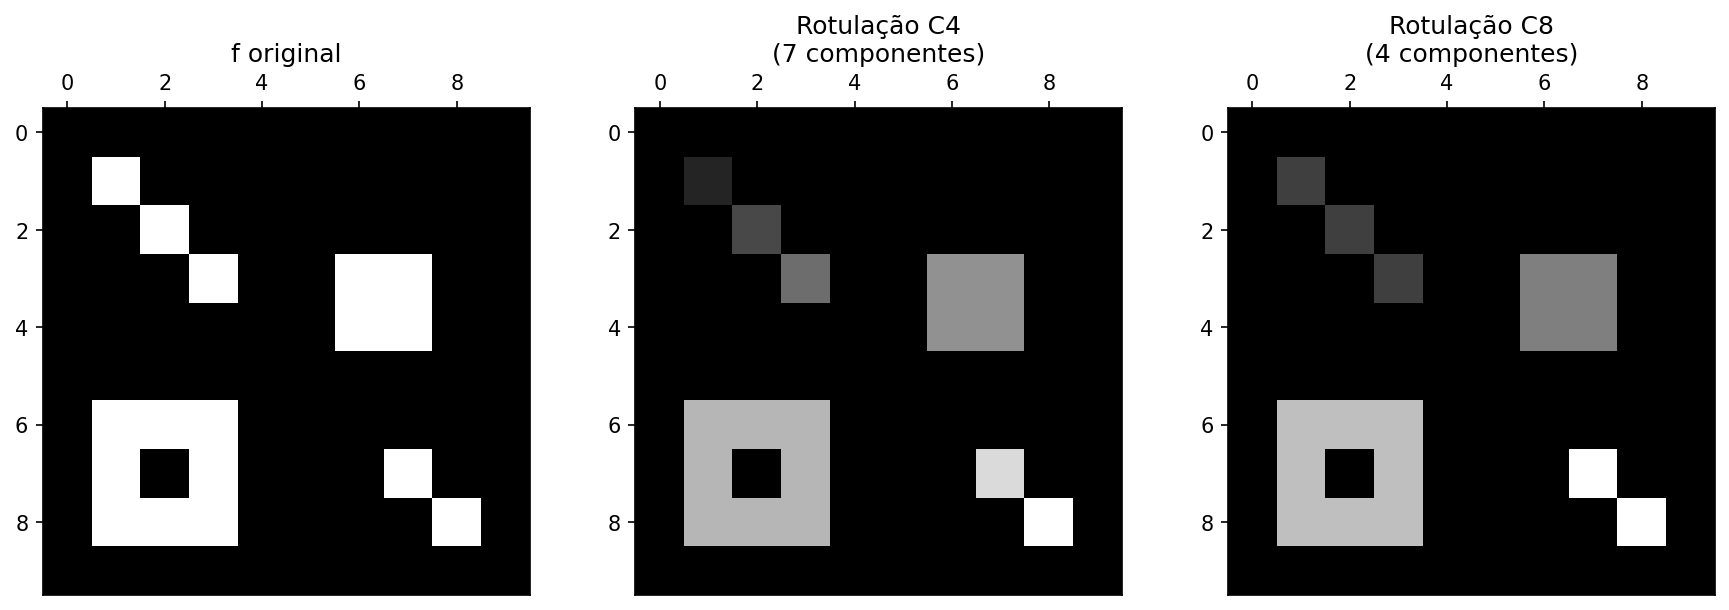

**Figura 4.17:** Efeito da conectividade na rotulação: a imagem binária 10×10 contém pixels diagonalmente adjacentes. Com conectividade-4, esses pixels formam componentes distintas; com conectividade-8, fundem-se em uma única componente.


In [ ]:
# Imagem binária 10×10 com componentes diagonalmente adjacentes
f = np.array([
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],  # diagonal com linha anterior
    [0,0,0,1,0,0,1,1,0,0],
    [0,0,0,0,0,0,1,1,0,0],
    [0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0],
    [0,1,0,1,0,0,0,1,0,0],
    [0,1,1,1,0,0,0,0,1,0],  # diagonal com linha anterior
    [0,0,0,0,0,0,0,0,0,0]], dtype=np.uint8) * 255

# Elemento estruturante cruz (conectividade-4) e quadrado (conectividade-8)
B4 = mm.secross()   # conectividade-4
B8 = mm.sebox()     # conectividade-8

# Rotulação com label0 (didático) e label (cv2)
lbl4_didatico = mm.label0(f, B4)
lbl8_didatico = mm.label0(f, B8)

_, lbl4_cv2 = cv2.connectedComponents(f, connectivity=4)
_, lbl8_cv2 = cv2.connectedComponents(f, connectivity=8)

# Validação cruzada
print(f"✅ label0 (C4) == cv2 (C4): {np.array_equal(lbl4_didatico, lbl4_cv2)}")
print(f"✅ label0 (C8) == cv2 (C8): {np.array_equal(lbl8_didatico, lbl8_cv2)}")
print(f"   Componentes C4: {lbl4_cv2.max()}  |  Componentes C8: {lbl8_cv2.max()}")

# Normalização para visualização
def norm_label(lbl):
    out = np.zeros_like(lbl, dtype=np.uint8)
    for i, v in enumerate(np.unique(lbl)[1:], 1):
        out[lbl == v] = int(i * 255 / lbl.max())
    return out

mm.show(
    [f, norm_label(lbl4_cv2), norm_label(lbl8_cv2)],
    titles=[
        "f original",
        f"Rotulação C4\n({lbl4_cv2.max()} componentes)",
        f"Rotulação C8\n({lbl8_cv2.max()} componentes)"
    ],
    cols=3, figsize=(12, 4), axis=True
)

### 4.4.2 Transformada de Distância

A **Transformada de Distância** (TD) é um operador que, aplicado a uma imagem binária $f$, produz uma imagem em níveis de cinza $D$ na qual cada pixel pertencente ao objeto ($f(x,y)\neq 0$) recebe como valor a distância geométrica até o pixel de fundo ($f(x',y')=0$) mais próximo:

$$
D(x,y) = \min_{(x',y') \,:\, f(x',y')=0} \; d\bigl((x,y),\,(x',y')\bigr)
$$

onde $d(\cdot,\cdot)$ é uma métrica de distância — tipicamente a distância Euclidiana ($L_2$). O resultado é uma representação topográfica dos objetos: pixels localizados no interior assumem valores elevados, enquanto pixels próximos às bordas apresentam baixos valores de distância. Os **máximos locais** de $D$ correspondem aos pontos mais afastados da borda do objeto, frequentemente próximos aos seus centros geométricos ou centros de máxima inscrição — propriedade particularmente útil para a geração automática de marcadores no algoritmo *watershed*.

> ### 📝 Definição formal usando erosões
>
> A TD admite ainda uma interpretação morfológica iterativa, conforme algoritmo da [Figura 4.18](#fig-04-sim-alg-distancia2). Considere uma função estruturante $b$ cujo valor central é nulo e cujos vizinhos possuem custos negativos associados ao deslocamento. Ao aplicar erosões sucessivas com essa função estruturante particular, os valores dos pixels dos objetos (que devem assumir a distância máxima possível da imagem) são progressivamente reduzidos segundo os custos definidos por $b$. O valor acumulado dessa propagação passa então a representar a distância ao fundo segundo a métrica induzida pela função estruturante.

Essa interpretação é implementada em `mm.dist1()`, que acumula erosões sucessivas utilizando a operação `mm.ero1()`. Já `mm.dist()` delega o cálculo da distância Euclidiana ao operador otimizado do OpenCV `cv2.distanceTransform(f, cv2.DIST_L2, 5)`, onde `f` é a imagem binária de entrada, `cv2.DIST_L2` especifica a métrica Euclidiana ($L_2$) e `5` indica o uso de uma máscara 5×5 para aproximar a distância com elevada precisão.

A função `dist1` produz uma transformada de distância discreta cuja métrica é determinada pela geometria e pelos pesos da função estruturante utilizada. Por exemplo, utilizando uma função estruturante em cruz com custo unitário para os quatro vizinhos ortogonais, obtém-se a distância de ***Manhattan*** ($L_1$). Outras escolhas de vizinhança e pesos induzem métricas diferentes. Já `mm.dist()` calcula uma aproximação eficiente da distância Euclidiana ($L_2$).

Por exigir sucessivas erosões sobre toda a imagem, a abordagem `dist1` possui custo computacional significativamente maior que `mm.dist()`, sendo empregada neste livro principalmente para fins didáticos e para evidenciar a relação entre morfologia matemática e transformadas de distância.

In [ ]:
# @title { display-mode: "form" }
# Prefixo exclusivo para evitar conflito com outras células do notebook
PREFIX = "dist2"

from IPython.display import HTML
HTML(f'''
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:var(--font-sans)}}
.{PREFIX}-tabs{{display:flex;gap:6px;margin-bottom:20px;flex-wrap:wrap}}
.{PREFIX}-tab{{padding:6px 14px;border-radius:20px;font-size:13px;cursor:pointer;border:0.5px solid var(--color-border-secondary);background:var(--color-background-primary);color:var(--color-text-secondary);transition:all .15s;white-space:nowrap}}
.{PREFIX}-tab.active{{background:var(--color-text-primary);color:var(--color-background-primary);border-color:transparent}}
.{PREFIX}-panel{{display:none}}.{PREFIX}-panel.active{{display:block}}

.algo-wrap{{background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.algo-header{{padding:14px 20px;border-bottom:0.5px solid var(--color-border-tertiary);display:flex;align-items:center;gap:10px}}
.algo-icon{{width:32px;height:32px;border-radius:var(--border-radius-md);display:flex;align-items:center;justify-content:center;font-size:16px;background:#E6F1FB;color:#185FA5}}
.algo-title{{font-size:14px;font-weight:500;color:var(--color-text-primary);text-align:left}}
.algo-sub{{font-size:12px;color:var(--color-text-secondary);margin-top:1px;text-align:left}}
.algo-body{{padding:20px;text-align:left}}

.step{{display:flex;gap:12px;margin-bottom:14px;align-items:flex-start}}
.step:last-child{{margin-bottom:0}}
.step-num{{min-width:24px;height:24px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0;margin-top:1px}}
.step-text{{font-size:13.5px;line-height:1.65;color:var(--color-text-primary);text-align:left}}
.step-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 6px;border-radius:4px;color:var(--color-text-primary)}}
.step-sub{{margin-top:8px;border-left:2px solid var(--color-border-secondary);padding-left:12px;display:flex;flex-direction:column;gap:5px}}
.step-sub-item{{font-size:13px;color:var(--color-text-secondary);line-height:1.55;text-align:left}}
.step-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.while-box{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);padding:11px 13px;margin-top:8px;text-align:left}}
.while-head{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.06em;margin-bottom:7px}}
.note{{margin-top:16px;padding-top:12px;border-top:0.5px solid var(--color-border-tertiary);font-size:12px;color:var(--color-text-secondary);font-style:italic;line-height:1.5;text-align:left}}

.num-teal{{background:#E1F5EE;color:#0F6E56}}
.num-purple{{background:#EEEDFE;color:#534AB7}}
.num-amber{{background:#FAEEDA;color:#854F0B}}
.num-coral{{background:#FAECE7;color:#993C1D}}
.num-blue{{background:#E6F1FB;color:#185FA5}}
.num-gray{{background:var(--color-background-secondary);color:var(--color-text-secondary)}}

.card-step{{display:flex;border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);overflow:hidden;margin-bottom:8px}}
.card-step:last-child{{margin-bottom:0}}
.card-badge{{min-width:48px;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0}}
.card-content{{padding:10px 14px;flex:1;text-align:left}}
.card-label{{font-size:10px;font-weight:500;letter-spacing:.08em;text-transform:uppercase;margin-bottom:3px}}
.card-text{{font-size:13.5px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.card-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.card-sub{{margin-top:6px;display:flex;flex-direction:column;gap:3px}}
.card-sub-item{{font-size:12.5px;color:var(--color-text-secondary);padding-left:10px;border-left:2px solid var(--color-border-secondary);line-height:1.5;text-align:left}}
.card-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 4px;border-radius:3px;color:var(--color-text-primary)}}

.tl{{position:relative;padding:4px 0 4px 36px;text-align:left}}
.tl-line{{position:absolute;left:11px;top:20px;bottom:20px;width:1.5px;background:var(--color-border-secondary);border-radius:2px}}
.tl-step{{display:flex;gap:0;margin-bottom:18px;position:relative}}
.tl-step:last-child{{margin-bottom:0}}
.tl-dot-wrap{{position:absolute;left:-36px;top:2px;display:flex;flex-direction:column;align-items:center;gap:3px}}
.tl-dot{{width:14px;height:14px;border-radius:50%;border:2px solid var(--color-border-secondary);background:var(--color-background-primary);transition:all .2s;z-index:1}}
.tl-step:hover .tl-dot{{background:var(--color-text-primary);border-color:var(--color-text-primary)}}
.tl-num{{font-size:9px;color:var(--color-text-secondary);font-weight:500;letter-spacing:.04em}}
.tl-title{{font-size:13.5px;font-weight:500;color:var(--color-text-primary);margin-bottom:3px;text-align:left}}
.tl-desc{{font-size:13px;color:var(--color-text-secondary);line-height:1.6;text-align:left}}
.tl-desc code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}

.code-wrap{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.code-bar{{background:var(--color-background-secondary);padding:10px 16px;display:flex;align-items:center;justify-content:space-between;border-bottom:0.5px solid var(--color-border-tertiary)}}
.code-lang{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.08em}}
.code-body{{padding:18px 20px;overflow-x:auto;text-align:left}}
.code-body pre{{font-family:var(--font-mono);font-size:13px;line-height:1.75;color:var(--color-text-primary);margin:0;white-space:pre;text-align:left}}
.kw{{color:#7C3AED}} .fn{{color:#0369A1}} .cm{{color:#6B7280;font-style:italic}} .st{{color:#059669}} .num-lit{{color:#DC2626}}

.ann-line{{display:flex;align-items:flex-start;gap:10px;margin-bottom:8px;padding:10px 12px;background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);text-align:left}}
.ann-badge{{min-width:20px;height:20px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:500;flex-shrink:0;margin-top:1px}}
.ann-text{{font-size:13px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.ann-text code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}

.metric-grid{{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:10px;margin-top:16px}}
.metric-card{{background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);padding:12px 14px;text-align:left}}
.metric-title{{font-size:11px;font-weight:500;text-transform:uppercase;letter-spacing:.07em;margin-bottom:6px}}
.metric-formula{{font-family:var(--font-mono);font-size:12px;color:var(--color-text-primary);margin-bottom:4px}}
.metric-desc{{font-size:12px;color:var(--color-text-secondary);line-height:1.5}}
.metric-elem{{display:inline-grid;grid-template-columns:repeat(3,16px);grid-template-rows:repeat(3,16px);gap:2px;margin-top:6px}}
.mc{{width:16px;height:16px;border-radius:2px;display:flex;align-items:center;justify-content:center;font-size:9px;font-weight:500}}
.mc-on{{background:#E6F1FB;color:#185FA5}}
.mc-off{{background:var(--color-background-secondary);color:var(--color-text-secondary)}}
.mc-ctr{{background:#185FA5;color:#fff}}
</style>

<h2 class="sr-only" style="position:absolute;left:-9999px">Transformada de distância por erosões numéricas sucessivas — painel interativo</h2>

<div class="{PREFIX}-tabs" id="{PREFIX}-tabs-container">
  <div class="{PREFIX}-tab" data-idx="0"><i class="ti ti-list-numbers" aria-hidden="true"></i> Passo a passo</div>
  <div class="{PREFIX}-tab" data-idx="1"><i class="ti ti-cards" aria-hidden="true"></i> Cards</div>
  <div class="{PREFIX}-tab" data-idx="2"><i class="ti ti-timeline" aria-hidden="true"></i> Linha do tempo</div>
  <div class="{PREFIX}-tab" data-idx="3"><i class="ti ti-code" aria-hidden="true"></i> Código Python</div>
  <div class="{PREFIX}-tab active" data-idx="4"><i class="ti ti-git-branch" aria-hidden="true"></i> Fluxograma</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-0">
<div class="algo-wrap">
  <div class="algo-header">
    <div class="algo-icon"><i class="ti ti-ripple" aria-hidden="true"></i></div>
    <div><div class="algo-title">Transformada de distância por erosão numérica</div><div class="algo-sub">Propagação matemática de distâncias via elemento estruturante com pesos</div></div>
  </div>
  <div class="algo-body">
    <div class="step"><div class="step-num num-teal">1</div><div class="step-text">Inicializar a imagem de trabalho fazendo uma cópia da original: <code>g ← f.copy()</code>. Os pixels de fundo (0) servem como fontes de distância nula.</div></div>
    <div class="step">
      <div class="step-num num-coral">2</div>
      <div class="step-text">
        Entrar em um laço infinito de erosões com pesos (ponto fixo):
        <div class="step-sub">
          <div class="step-sub-item">Salvar estado anterior: <code>f ← g.copy()</code>.</div>
          <div class="step-sub-item">Erodir: <code>g ← ero1(g, b)</code>, aplicando a subtração local de pesos e computando o valor mínimo para cada vizinhança.</div>
        </div>
      </div>
    </div>
    <div class="step"><div class="step-num num-blue">3</div><div class="step-text">Verificar convergência: se <code>f</code> for idêntica a <code>g</code> (<code>array_equal</code>), a frente de onda de distâncias se estabilizou. Romper o laço (<code>break</code>).</div></div>
    <div class="step"><div class="step-num num-blue">4</div><div class="step-text">Retornar a matriz modificada <code>g</code> contendo o mapa exato de distâncias.</div></div>
    <div class="note">Nesta abordagem morfológica numérica, não há incremento artificial ou contador. A distância propaga-se de fora para dentro porque a erosão contínua puxa o valor <code>0</code> do fundo e o decrementa matematicamente (subtraindo os pesos negativos como <code>-1</code>), fazendo com que os valores escalem radialmente.</div>
  </div>
</div>

<div class="metric-grid">
  <div class="metric-card">
    <div class="metric-title" style="color:#185FA5">Cruz — L₁ (Manhattan)</div>
    <div class="metric-formula">B_cruz [y,x]</div>
    <div class="metric-desc">Pesos: Centro=0, Lados=-1, Cantos=-inf</div>
  </div>
  <div class="metric-card">
    <div class="metric-title" style="color:#854F0B">Erosão de Cinzas</div>
    <div class="metric-formula">f[vy,vx] - bv</div>
    <div class="metric-desc">Subtrai o peso e busca o valor mínimo local</div>
  </div>
  <div class="metric-card">
    <div class="metric-title" style="color:#0F6E56">Convergência</div>
    <div class="metric-formula">f == g</div>
    <div class="metric-desc">Para quando nenhum pixel muda de valor</div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-1">
  <div class="card-step">
    <div class="card-badge num-teal">01</div>
    <div class="card-content">
      <div class="card-label" style="color:#0F6E56">Inicialização</div>
      <div class="card-text">Clonar imagem de entrada: <code>g ← f.copy()</code>. O objeto possui intensidade alta (255) e o fundo possui intensidade 0.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-coral">02</div>
    <div class="card-content">
      <div class="card-label" style="color:#993C1D">Mapeamento Local (ero1)</div>
      <div class="card-text">Para cada coordenada <code>(y, x)</code>, buscar o mínimo valor da operação <code>f[vy, vx] - bv</code> aplicada à sua vizinhança estruturante.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-coral">03</div>
    <div class="card-content">
      <div class="card-label" style="color:#993C1D">Loop Iterativo</div>
      <div class="card-text">Atualizar sequencialmente: <code>f = g.copy()</code> seguido de <code>g = ero1(g, b)</code>. Os valores nulos propagam-se para o interior do objeto.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-blue">04</div>
    <div class="card-content">
      <div class="card-label" style="color:#185FA5">Critério de Parada</div>
      <div class="card-text">Se <code>np.array_equal(f, g)</code>, significa que o mapa de distâncias atingiu o equilíbrio estável e a propagação terminou.</div>
    </div>
  </div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-2">
<div class="tl">
  <div class="tl-line"></div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">01</span></div>
    <div><div class="tl-title">Cópia de Trabalho</div><div class="tl-desc">Prepara a matriz inicial `g`.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">02</span></div>
    <div>
      <div class="tl-title">Loop de Erosão de Escala</div>
      <div class="while-box">
        <div class="while-head">while True</div>
        <div class="step-sub" style="border-color:var(--color-border-tertiary)">
          <div class="step-sub-item">Guarda estado: <code>f ← g.copy()</code></div>
          <div class="step-sub-item">Aplica erosão com pesos: <code>g ← ero1(g, b)</code></div>
        </div>
      </div>
    </div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">03</span></div>
    <div><div class="tl-title">Estabilização Espacial</div><div class="tl-desc">Condição de parada acionada assim que <code>np.array_equal(f, g)</code> se torna verdadeiro.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">04</span></div>
    <div><div class="tl-title">Retorno Numérico</div><div class="tl-desc">Retorna <code>g</code> contendo as distâncias calculadas pela subtração cumulativa dos pesos.</div></div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-3">
<div class="code-wrap">
  <div class="code-bar">
    <span class="code-lang"><i class="ti ti-brand-python" aria-hidden="true" style="font-size:14px;vertical-align:-2px;margin-right:5px"></i>morph_dist.py</span>
    <span style="font-size:11px;color:var(--color-text-secondary)">Erosão numérica iterativa</span>
  </div>
  <div class="code-body">
<pre><span class="kw">@staticmethod</span>
<span class="kw">def</span> <span class="fn">ero1</span>(f, b):
    g = np.empty_like(f)
    <span class="kw">for</span> y <span class="kw">in</span> <span class="fn">range</span>(f.shape[<span class="num-lit">0</span>]):
        <span class="kw">for</span> x <span class="kw">in</span> <span class="fn">range</span>(f.shape[<span class="num-lit">1</span>]):
            g[y,x] = <span class="num-lit">255</span>
            <span class="kw">for</span> vy,vx,bv <span class="kw">in</span> mm._viz(f,b,y,x):
                <span class="kw">if</span> np.isinf(bv): <span class="kw">continue</span> 
                val = int(f[vy,vx]) - int(bv)
                <span class="kw">if</span> g[y,x] > val: 
                    g[y,x] = max(0, val)
    <span class="kw">return</span> g

<span class="kw">@staticmethod</span>
<span class="kw">def</span> <span class="fn">dist1</span>(f, b):
    g = f.copy()
    <span class="kw">while</span> <span class="fn">True</span>:
        f = g.copy()
        g = mm.ero1(g, b)
        <span class="kw">if</span> np.array_equal(f, g): 
            <span class="kw">break</span>
    <span class="kw">return</span> g</pre>
  </div>
</div>

<div style="margin-top:16px;display:flex;flex-direction:column;gap:8px;text-align:left">
  <div class="ann-line"><div class="ann-badge num-teal">1</div><div class="ann-text"><code>g[y,x] = 255</code> — Inicializa o elemento com o valor máximo antes de computar o operador de mínimo da erosão.</div></div>
  <div class="ann-line"><div class="ann-badge num-coral">2</div><div class="ann-text"><code>f[vy,vx] - bv</code> — Subtrai o peso associado da vizinhança. Como os pesos da cruz externa são negativos (ex: <code>-1</code>), a operação torna-se uma adição matemática (<code>f[vy,vx] - (-1) = f[vy,vx] + 1</code>) propagando a distância a partir das bordas zeradas.</div></div>
  <div class="ann-line"><div class="ann-badge num-blue">3</div><div class="ann-text"><code>np.array_equal(f, g)</code> — Critério de convergência exato por estabilização de ponto fixo.</div></div>
</div>
</div>

<div class="{PREFIX}-panel active" id="{PREFIX}-p-4">
<svg viewBox="0 0 560 720" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:560px;display:block">
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#888780"/></marker>
    <marker id="arr-b" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#185FA5"/></marker>
    <marker id="arr-r" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#993C1D"/></marker>
    <marker id="arr-g" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#0F6E56"/></marker>
  </defs>

  <ellipse cx="280" cy="36" rx="60" ry="22" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
  <text x="280" y="41" text-anchor="middle" font-size="13" font-weight="500" fill="#085041">início</text>

  <rect x="150" y="85" width="260" height="46" rx="6" fill="#E1F5EE" stroke="#9FE1CB" stroke-width="1"/>
  <text x="280" y="104" text-anchor="middle" font-size="12" font-weight="500" fill="#0F6E56">inicializar mapa</text>
  <text x="280" y="120" text-anchor="middle" font-size="12" fill="#085041">g ← f.copy()</text>

  <rect x="150" y="165" width="260" height="46" rx="6" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="184" text-anchor="middle" font-size="12" font-weight="500" fill="#993C1D">salvar estado anterior</text>
  <text x="280" y="200" text-anchor="middle" font-size="12" fill="#712B13">f ← g.copy()</text>

  <rect x="150" y="245" width="260" height="46" rx="6" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="264" text-anchor="middle" font-size="12" font-weight="500" fill="#993C1D">executar erosão com pesos</text>
  <text x="280" y="280" text-anchor="middle" font-size="12" fill="#712B13">g ← ero1(g, b)</text>

  <polygon points="280,325 390,355 280,385 170,355" fill="#E6F1FB" stroke="#85B7EB" stroke-width="1"/>
  <text x="280" y="351" text-anchor="middle" font-size="12" fill="#0C447C">array_equal(f, g)</text>
  <text x="280" y="367" text-anchor="middle" font-size="12" fill="#0C447C">estabilizou?</text>

  <line x1="170" y1="355" x2="100" y2="355" stroke="#993C1D" stroke-width="1.2"/>
  <line x1="100" y1="355" x2="100" y2="188" stroke="#993C1D" stroke-width="1.2"/>
  <line x1="100" y1="188" x2="150" y2="188" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <text x="120" y="345" text-anchor="middle" font-size="11" fill="#993C1D">não</text>

  <line x1="280" y1="385" x2="280" y2="430" stroke="#0F6E56" stroke-width="1.2" marker-end="url(#arr-g)"/>
  <text x="295" y="405" font-size="11" fill="#0F6E56">sim</text>

  <rect x="150" y="430" width="260" height="46" rx="6" fill="#EAF3DE" stroke="#97C459" stroke-width="1"/>
  <text x="280" y="458" text-anchor="middle" font-size="12" font-weight="500" fill="#27500A">retornar g</text>

  <ellipse cx="280" cy="525" rx="50" ry="20" fill="#EAF3DE" stroke="#97C459" stroke-width="1"/>
  <text x="280" y="529" text-anchor="middle" font-size="13" font-weight="500" fill="#27500A">fim</text>
  <line x1="280" y1="476" x2="280" y2="505" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>

  <line x1="280" y1="58" x2="280" y2="85" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="131" x2="280" y2="165" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="211" x2="280" y2="245" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="291" x2="280" y2="325" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>

  <text x="280" y="600" text-anchor="middle" font-size="11.5" fill="#888780" font-style="italic">Ponto Fixo Numérico: A distância emerge da propagação matemática do valor zero.</text>
</svg>
</div>

<script>
(function() {{
  var container = document.getElementById('{PREFIX}-tabs-container');
  if (!container) return;
  
  var tabs = container.querySelectorAll('.{PREFIX}-tab');
  var panels = [
    document.getElementById('{PREFIX}-p-0'),
    document.getElementById('{PREFIX}-p-1'),
    document.getElementById('{PREFIX}-p-2'),
    document.getElementById('{PREFIX}-p-3'),
    document.getElementById('{PREFIX}-p-4')
  ];

  tabs.forEach(function(tab) {{
    tab.onclick = function() {{
      var idx = parseInt(this.getAttribute('data-idx'));
      
      tabs.forEach(function(t) {{ t.classList.remove('active'); }});
      panels.forEach(function(p) {{ if(p) p.classList.remove('active'); }});
      
      this.classList.add('active');
      if(panels[idx]) panels[idx].classList.add('active');
    }};
  }});
}})();
</script>
''')

**Figura 4.18:** Algoritmo da Transformada de Distância.


A [Figura 4.19](#fig-04-sim-04-distancia) apresenta um simulador interativo da TD: é possível posicionar o cursor sobre diferentes pixels do objeto e observar, em tempo real, o valor da distância associado àquela posição, isto é, a distância até o pixel de fundo mais próximo. A [Figura 4.20](#fig-04-distancia-didatico) apresenta um exemplo prático dessa execução em ambiente Python.

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-distancia" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-04-distancia * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-04-distancia canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; cursor: crosshair; background: #ffffff; }
  #sim-04-distancia button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: all 0.15s ease; font-weight: 600; }
  #sim-04-distancia button:hover { background: #e8dfcf; }
  #sim-04-distancia button.sim04_td_act { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-04-distancia .sim04_td_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .sim04_td_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .sim04_td_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-bottom: 14px; }
  .sim04_td_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 10px; text-align: center; }
  .sim04_td_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .sim04_td_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  
  .sim04_td_se_grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 4px; max-width: 120px; margin: 6px auto; }
  .sim04_td_se_btn { padding: 6px!important; font-size: 10px!important; font-family: monospace; font-weight: 700; }
  .sim04_td_se_btn.sim04_td_inf { color: #8a8371!important; background: #fafaf7!important; border-color: #e4dcc8!important; font-weight: normal; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">🗺️ Simulador: Transformada de Distância (TD)</span>
  <span class="sim04_td_pill">Fronteiras em +∞ (144)</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Estatísticas -->
  <div class="sim04_td_grid_stats">
    <div class="sim04_td_stat_box">
      <div class="sim04_td_stat_label">Pixels Ativos</div>
      <div id="sim04_td_statPx" class="sim04_td_stat_value" style="color:#27ae60;">0</div>
    </div>
    <div class="sim04_td_stat_box">
      <div class="sim04_td_stat_label">Distância Máx.</div>
      <div id="sim04_td_statMax" class="sim04_td_stat_value" style="color:#2980b9;">0</div>
    </div>
    <div class="sim04_td_stat_box">
      <div class="sim04_td_stat_label">Métrica Atual</div>
      <div id="sim04_td_statMetric" class="sim04_td_stat_value" style="color:#b9770e; font-size:11px;">L∞ (Chebyshev)</div>
    </div>
    <div class="sim04_td_stat_box">
      <div class="sim04_td_stat_label">Iteração (k)</div>
      <div id="sim04_td_statStep" class="sim04_td_stat_value" style="color:#c0392b;">–</div>
    </div>
  </div>

  <!-- Layout Principal em 2 Colunas -->
  <div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
    
    <!-- Canvas e Legenda -->
    <div style="flex:2; min-width:260px; background:#fafaf7; border:1px solid #e9e3d3; border-radius:12px; padding:12px; text-align:center;">
      <canvas id="sim04_td_Canvas" style="margin:0 auto;"></canvas>
      <div style="font-size:10px; color:#8a8371; margin-top:8px;">
        🖱️ Clique para ativar/desativar pixels · Arraste para pintar
      </div>
      <div style="display:flex; flex-wrap:wrap; gap:6px; margin-top:10px; align-items:center; justify-content:center;" id="sim04_td_legendBox"></div>
    </div>

    <!-- Painel de Controles Lateral -->
    <div style="flex:1; min-width:200px; display:flex; flex-direction:column; gap:12px;">
      
      <!-- Editor do Elemento Estruturante (b) -->
      <div class="sim04_td_panel" style="text-align:center;">
        <div style="font-size:11px; font-weight:700; margin-bottom:2px; text-align:left; color:#5e5a4a;">
          Elemento Estruturante (b)
        </div>
        <div style="font-size:9.5px; color:#8a8371; margin-bottom:6px; text-align:left;">Clique para alterar os pesos:</div>
        
        <div class="sim04_td_se_grid">
          <button id="sim04_td_se_0_0" class="sim04_td_se_btn sim04_td_active" data-se="0,0">-1</button>
          <button id="sim04_td_se_0_1" class="sim04_td_se_btn sim04_td_active" data-se="0,1">-1</button>
          <button id="sim04_td_se_0_2" class="sim04_td_se_btn sim04_td_active" data-se="0,2">-1</button>
          
          <button id="sim04_td_se_1_0" class="sim04_td_se_btn sim04_td_active" data-se="1,0">-1</button>
          <button id="sim04_td_se_1_1" class="sim04_td_se_btn" style="background:#e4dcc8; cursor:not-allowed; color:#8a8371;" disabled>0</button>
          <button id="sim04_td_se_1_2" class="sim04_td_se_btn sim04_td_active" data-se="1,2">-1</button>
          
          <button id="sim04_td_se_2_0" class="sim04_td_se_btn sim04_td_active" data-se="2,0">-1</button>
          <button id="sim04_td_se_2_1" class="sim04_td_se_btn sim04_td_active" data-se="2,1">-1</button>
          <button id="sim04_td_se_2_2" class="sim04_td_se_btn sim04_td_active" data-se="2,2">-1</button>
        </div>
        
        <div style="display:flex; flex-wrap:wrap; gap:4px; margin-top:8px;">
          <button data-se-preset="cross" style="flex:1; font-size:9.5px;">L1 (Cruz)</button>
          <button data-se-preset="square" style="flex:1; font-size:9.5px;">L∞ (Quadr.)</button>
          <button data-se-preset="chamfer" style="flex:1; font-size:9.5px; min-width:90px;">Chamfer 3-4</button>
        </div>
      </div>

      <!-- Modo de Visualização -->
      <div class="sim04_td_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Visualização
        </div>
        <div style="display:flex; gap:6px;">
          <button id="sim04_td_btnLabel" class="sim04_td_active" data-mode="label" style="flex:1; justify-content:center;">Final (TD)</button>
          <button id="sim04_td_btnAnim" data-mode="anim" style="flex:1; justify-content:center;">Animado</button>
        </div>
      </div>

      <!-- Controles de Animação -->
      <div id="sim04_td_animCtrl" class="sim04_td_panel" style="display:none;">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Propagação Passo a Passo
        </div>
        <div style="display:flex; gap:6px; margin-bottom:8px;">
          <button data-action="prev" style="flex:1; justify-content:center;">◀</button>
          <button id="sim04_td_btnPlay" data-action="play" style="flex:1; justify-content:center;">▶</button>
          <button data-action="next" style="flex:1; justify-content:center;">▶▶</button>
        </div>
        <div style="display:flex; align-items:center; gap:8px;">
          <label style="font-size:9.5px; color:#8a8371; font-weight:700;">Vel.</label>
          <input type="range" id="sim04_td_speedSlider" min="1" max="10" value="5" style="flex:1; max-width:160px; height:4px; cursor:pointer;">
        </div>
      </div>

      <!-- Exemplos f -->
      <div class="sim04_td_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Exemplos Predefinidos
        </div>
        <div style="display:flex; flex-direction:column; gap:5px;">
          <button data-preset="square" style="justify-content:flex-start;">■ Quadrado Cheio</button>
          <button data-preset="lshape" style="justify-content:flex-start;">╚ Forma em L</button>
          <button data-preset="ring" style="justify-content:flex-start;">◎ Anel com Buraco</button>
          <button data-preset="corner0" style="justify-content:flex-start;">↘ Fundo no (0,0)</button>
        </div>
      </div>

      <!-- Botão de Limpeza -->
      <button data-action="clear" style="justify-content:center; border-color:#f5b7b1; color:#c0392b; background:#fdecea;">
        🗑️ Limpar Grade
      </button>

    </div>

  </div>

</div>
</div>

<script>
(function(){
  function initSim04TD(root){
    if (!root || root.dataset.initDone) return;
    root.dataset.initDone = "1";

    const td_COLS = 12, td_ROWS = 12, td_CELL = 22, td_PAD = 10;
    const td_W = td_COLS * td_CELL + td_PAD * 2, td_H = td_ROWS * td_CELL + td_PAD * 2;
    const td_cv = root.querySelector('#sim04_td_Canvas');
    td_cv.width = td_W; 
    td_cv.height = td_H;
    const td_ctx = td_cv.getContext('2d');
    
    const td_MAX_DIST = 144;

    const td_COLORS = ['#ebf4fd', '#a9cce3', '#73c6b6', '#52be80', '#27ae60', '#2980b9', '#1b4f72', '#5b2c6f', '#4a235a'];
    function td_getColor(d, maxD) {
      if(d === 0) return { fill: 'transparent', text: '#8a8371', stroke: '#e4dcc8' };
      if(d >= td_MAX_DIST) return { fill: '#fdecea', text: '#c0392b', stroke: '#f5b7b1' };
      
      let ratio = maxD > 1 ? (d - 1) / (maxD - 1) : 0;
      let idx = Math.max(0, Math.min(td_COLORS.length - 1, Math.floor(ratio * (td_COLORS.length - 1))));
      
      const bg = td_COLORS[idx];
      const text = (idx > 4) ? '#ffffff' : '#26241d';
      return { fill: bg, text: text, stroke: '#2980b9' };
    }

    let td_grid = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
    
    const td_VALS = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -Infinity];
    let td_b = [
      [-1, -1, -1],
      [-1,  0, -1],
      [-1, -1, -1]
    ];
    
    let td_mode = 'label';
    let td_painting = false;
    let td_paintVal = 1;

    let td_animSteps = [];
    let td_animIdx = 0;
    let td_playing = false;
    let td_playTimer = null;

    function td_compute() {
      let f = td_grid;
      let g = Array.from({length: td_ROWS}, (_, r) => 
        Array.from({length: td_COLS}, (_, c) => f[r][c] ? td_MAX_DIST : 0)
      );
      let steps = [];
      let k = 0;

      const copy = arr => arr.map(row => [...row]);
      steps.push({ g: copy(g), eroded: Array.from({length:td_ROWS}, ()=>new Array(td_COLS).fill(0)), k: k });

      let activePx = f.flat().reduce((a,b)=>a+b, 0);
      if(activePx === 0) return { D: g, steps, max: 0 };

      while (true) {
        k++;
        let nextG = Array.from({length: td_ROWS}, () => new Array(td_COLS).fill(0));
        let changed = false;
        let erodedCells = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));

        for (let r=0; r<td_ROWS; r++) {
          for (let c=0; c<td_COLS; c++) {
            if (f[r][c] === 1) {
              let min_val = g[r][c];
              
              for (let dr=-1; dr<=1; dr++) {
                for (let dc=-1; dc<=1; dc++) {
                  let b_val = td_b[dr+1][dc+1];
                  if (b_val !== -Infinity && !(dr===0 && dc===0)) {
                    let nr = r + dr, nc = c + dc;
                    let neighbor_val = td_MAX_DIST;
                    
                    if (nr >= 0 && nr < td_ROWS && nc >= 0 && nc < td_COLS) {
                      neighbor_val = g[nr][nc];
                    }
                    
                    let val = neighbor_val - b_val; 
                    if (val < min_val) {
                      min_val = val;
                    }
                  }
                }
              }
              nextG[r][c] = min_val;
              if (min_val !== g[r][c]) {
                changed = true;
                erodedCells[r][c] = 1;
              }
            } else {
              nextG[r][c] = 0;
            }
          }
        }
        
        if (!changed) {
          steps.push({ g: copy(nextG), eroded: erodedCells, k: k, done: true });
          break;
        }
        
        steps.push({ g: copy(nextG), eroded: erodedCells, k: k });
        g = nextG;
      }
      
      let maxD = 0;
      for(let r=0; r<td_ROWS; r++){
        for(let c=0; c<td_COLS; c++){
           if(f[r][c] === 1 && g[r][c] < td_MAX_DIST && g[r][c] > maxD) maxD = g[r][c];
        }
      }
      return { D: g, steps, max: maxD };
    }

    function td_drawFinal() {
      const res = td_compute();
      const D = res.D;
      td_ctx.clearRect(0, 0, td_W, td_H);

      for (let r=0; r<td_ROWS; r++) {
        for (let c=0; c<td_COLS; c++) {
          const x = td_PAD + c * td_CELL, y = td_PAD + r * td_CELL;
          const d = D[r][c];
          const active = td_grid[r][c];

          if (active) {
            const col = td_getColor(d, res.max);
            td_ctx.fillStyle = col.fill; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
            td_ctx.strokeStyle = col.stroke; td_ctx.lineWidth = 1; td_ctx.setLineDash([]);
            td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
            td_ctx.fillStyle = col.text;
            td_ctx.font = d >= td_MAX_DIST ? 'bold 9px monospace' : 'bold 11px monospace';
            td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
            td_ctx.fillText(d >= td_MAX_DIST ? '144' : d, x+td_CELL/2, y+td_CELL/2);
          } else {
            td_ctx.fillStyle = '#fafaf7'; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
            td_ctx.strokeStyle = '#e4dcc8'; td_ctx.lineWidth = 0.5; td_ctx.setLineDash([]);
            td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
            td_ctx.fillStyle = '#8a8371';
            td_ctx.font = '9px monospace';
            td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
            td_ctx.fillText('0', x+td_CELL/2, y+td_CELL/2);
          }

          if (r===0) { td_ctx.fillStyle='#8a8371'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(c, x+td_CELL/2, td_PAD/2); }
          if (c===0) { td_ctx.fillStyle='#8a8371'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(r, td_PAD/2, y+td_CELL/2); }
        }
      }

      root.querySelector('#sim04_td_statPx').textContent = td_grid.flat().filter(Boolean).length;
      root.querySelector('#sim04_td_statMax').textContent = res.max;
      root.querySelector('#sim04_td_statStep').textContent = 'Finalizado';
      td_buildLegend(res.D, res.max);
    }

    function td_drawAnimFrame() {
      if (!td_animSteps.length) return;
      const step = td_animSteps[Math.min(td_animIdx, td_animSteps.length-1)];
      const D = step.g;
      const eroded = step.eroded;
      
      let currentMaxD = 0;
      for(let r=0; r<td_ROWS; r++) {
        for(let c=0; c<td_COLS; c++) {
          if(td_grid[r][c] && D[r][c] < td_MAX_DIST && D[r][c] > currentMaxD) currentMaxD = D[r][c];
        }
      }

      td_ctx.clearRect(0, 0, td_W, td_H);

      for (let r=0; r<td_ROWS; r++) {
        for (let c=0; c<td_COLS; c++) {
          const x = td_PAD + c * td_CELL, y = td_PAD + r * td_CELL;
          const d = D[r][c];
          const active = td_grid[r][c];

          if (active) {
            let maxValArray = td_animSteps[td_animSteps.length-1].g.flat().filter(v=>v<td_MAX_DIST);
            const globalMax = maxValArray.length > 0 ? Math.max(...maxValArray) : 1;
            const col = td_getColor(d, globalMax);
            td_ctx.fillStyle = col.fill; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
            
            if(eroded[r][c] === 1) {
               td_ctx.strokeStyle = '#b9770e'; td_ctx.lineWidth = 2; td_ctx.setLineDash([2,2]);
               td_ctx.fillStyle = 'rgba(185, 119, 14, 0.15)'; td_ctx.fillRect(x+1, y+1, td_CELL-2, td_CELL-2);
            } else {
               td_ctx.strokeStyle = col.stroke; td_ctx.lineWidth = 1; td_ctx.setLineDash([]);
            }
            
            td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
            td_ctx.fillStyle = col.text;
            td_ctx.font = d >= td_MAX_DIST ? 'bold 9px monospace' : 'bold 11px monospace';
            td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
            td_ctx.fillText(d >= td_MAX_DIST ? '144' : d, x+td_CELL/2, y+td_CELL/2);
            td_ctx.setLineDash([]);
          } else {
            td_ctx.fillStyle = '#fafaf7';
            td_ctx.strokeStyle = '#e4dcc8'; td_ctx.lineWidth = 0.5; td_ctx.setLineDash([]);
            td_ctx.strokeRect(x+0.5, y+0.5, td_CELL-1, td_CELL-1);
            td_ctx.fillStyle = '#8a8371';
            td_ctx.font = '9px monospace';
            td_ctx.textAlign = 'center'; td_ctx.textBaseline = 'middle';
            td_ctx.fillText('0', x+td_CELL/2, y+td_CELL/2);
          }

          if (r===0) { td_ctx.fillStyle='#8a8371'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(c, x+td_CELL/2, td_PAD/2); }
          if (c===0) { td_ctx.fillStyle='#8a8371'; td_ctx.font='8px monospace'; td_ctx.textAlign='center'; td_ctx.fillText(r, td_PAD/2, y+td_CELL/2); }
        }
      }

      root.querySelector('#sim04_td_statMax').textContent = currentMaxD;
      root.querySelector('#sim04_td_statPx').textContent = td_grid.flat().filter(Boolean).length;
      root.querySelector('#sim04_td_statStep').textContent = step.done ? 'Concluído' : step.k;
      td_buildLegend(D, currentMaxD);
    }

    function td_buildLegend(D_matrix, maxD) {
      const box = root.querySelector('#sim04_td_legendBox');
      box.innerHTML = '';
      
      let uniqueD = new Set();
      D_matrix.forEach(row => row.forEach(val => { 
        if(val > 0 && val < td_MAX_DIST) uniqueD.add(val); 
      }));
      let sortedD = Array.from(uniqueD).sort((a,b) => a-b);
      
      if (sortedD.length === 0) {
        box.innerHTML = '<span style="font-size:9.5px; color:#8a8371;">Sem propagação visível</span>';
        return;
      }
      
      let displayArr = sortedD;
      if (sortedD.length > 12) {
          displayArr = sortedD.filter((_, i) => i === 0 || i === sortedD.length-1 || i%Math.ceil(sortedD.length/10) === 0);
      }
      
      box.innerHTML = '<span style="font-size:9.5px; color:#8a8371; width:100%;">Cores (exceto 144):</span>';
      
      displayArr.forEach(d => {
        const col = td_getColor(d, maxD);
        const span = document.createElement('span');
        span.style.cssText = 'display:flex; align-items:center; gap:4px; font-size:9.5px; color:#5e5a4a;';
        span.innerHTML = '<span style="width:12px; height:12px; border-radius:3px; background:' + col.fill + '; border:1px solid ' + col.stroke + '; display:inline-block"></span><span>' + d + '</span>';
        box.appendChild(span);
      });
    }

    function td_updateSEUI() {
      let typeName = "Personalizada";
      let isCross = td_b[0][1]===-1 && td_b[1][0]===-1 && td_b[1][2]===-1 && td_b[2][1]===-1 && td_b[0][0]===-Infinity && td_b[0][2]===-Infinity && td_b[2][0]===-Infinity && td_b[2][2]===-Infinity;
      let isSquare = td_b.every((r, i) => r.every((v, j) => (i===1 && j===1) ? true : v===-1));
      let isChamfer = td_b[0][1]===-3 && td_b[1][0]===-3 && td_b[1][2]===-3 && td_b[2][1]===-3 && td_b[0][0]===-4 && td_b[0][2]===-4 && td_b[2][0]===-4 && td_b[2][2]===-4;

      if (isCross) typeName = "L1 (City-Block)";
      else if (isSquare) typeName = "L∞ (Chebyshev)";
      else if (isChamfer) typeName = "Chamfer 3-4";

      root.querySelector('#sim04_td_statMetric').textContent = typeName;

      for (let r=0; r<3; r++) {
        for (let c=0; c<3; c++) {
          if(r===1 && c===1) continue;
          const btn = root.querySelector('#sim04_td_se_' + r + '_' + c);
          const val = td_b[r][c];
          
          if(val !== -Infinity) {
            btn.textContent = String(val);
            btn.className = 'sim04_td_se_btn sim04_td_active';
          } else {
            btn.textContent = '-∞';
            btn.className = 'sim04_td_se_btn sim04_td_inf';
          }
        }
      }
    }

    function td_toggleSE(r, c) {
      if(r===1 && c===1) return;
      
      let currentVal = td_b[r][c];
      let idx = td_VALS.indexOf(currentVal);
      let nextVal = td_VALS[(idx + 1) % td_VALS.length];
      
      td_b[r][c] = nextVal;
      td_updateSEUI();
      td_refresh();
    };

    function td_setPresetSE(type) {
      for (let r=0; r<3; r++) for (let c=0; c<3; c++) td_b[r][c] = -Infinity;
      td_b[1][1] = 0;

      if (type === 'cross') {
        td_b[0][1] = td_b[1][0] = td_b[1][2] = td_b[2][1] = -1;
      } else if (type === 'square') {
        for (let r=0; r<3; r++) for (let c=0; c<3; c++) if(!(r===1 && c===1)) td_b[r][c] = -1;
      } else if (type === 'chamfer') {
        td_b[0][1] = td_b[1][0] = td_b[1][2] = td_b[2][1] = -3;
        td_b[0][0] = td_b[0][2] = td_b[2][0] = td_b[2][2] = -4;
      }
      
      td_updateSEUI();
      td_refresh();
    };

    function td_refresh() {
      if (td_mode === 'anim') {
        td_animSteps = td_compute().steps;
        td_animIdx = 0;
        td_drawAnimFrame();
      } else {
        td_drawFinal();
      }
    }

    function td_setMode(m) {
      td_mode = m;
      td_stopPlay();
      root.querySelector('#sim04_td_btnLabel').classList.toggle('sim04_td_active', m==='label');
      root.querySelector('#sim04_td_btnAnim').classList.toggle('sim04_td_active', m==='anim');
      root.querySelector('#sim04_td_animCtrl').style.display = m==='anim' ? 'block' : 'none';
      td_refresh();
    }

    function td_animStep(d) {
      td_animIdx = Math.max(0, Math.min(td_animSteps.length-1, td_animIdx+d));
      td_drawAnimFrame();
    }

    function td_togglePlay() {
      if (td_playing) td_stopPlay(); else td_startPlay();
    }

    function td_startPlay() {
      td_playing = true;
      root.querySelector('#sim04_td_btnPlay').textContent = '⏸';
      function tick() {
        if (td_animIdx >= td_animSteps.length-1) { td_stopPlay(); return; }
        td_animIdx++;
        td_drawAnimFrame();
        const spd = +root.querySelector('#sim04_td_speedSlider').value;
        const delay = Math.round(1200 - spd * 100);
        td_playTimer = setTimeout(tick, delay);
      }
      tick();
    }

    function td_stopPlay() {
      td_playing = false;
      if (td_playTimer) { clearTimeout(td_playTimer); td_playTimer = null; }
      root.querySelector('#sim04_td_btnPlay').textContent = '▶';
    }

    function td_clearGrid() {
      td_grid = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
      td_stopPlay();
      td_refresh();
    }

    const td_PRESETS = {
      square: () => {
        const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
        for(let r=2; r<=9; r++) for(let c=2; c<=9; c++) g[r][c] = 1;
        return g;
      },
      lshape: () => {
        const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
        for(let r=2; r<=9; r++) { g[r][2]=1; g[r][3]=1; g[r][4]=1; }
        for(let c=5; c<=9; c++) { g[7][c]=1; g[8][c]=1; g[9][c]=1; }
        return g;
      },
      ring: () => {
        const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(0));
        for(let c=2; c<=9; c++) { g[2][c]=1; g[3][c]=1; g[8][c]=1; g[9][c]=1; }
        for(let r=4; r<=7; r++) { g[r][2]=1; g[r][3]=1; g[r][8]=1; g[r][9]=1; }
        return g;
      },
      corner0: () => {
        const g = Array.from({length:td_ROWS}, () => new Array(td_COLS).fill(1));
        g[0][0] = 0;
        return g;
      }
    };

    function td_loadPreset(name) {
      td_grid = td_PRESETS[name]();
      td_stopPlay();
      td_refresh();
    }

    function td_cellAt(e) {
      const rect = td_cv.getBoundingClientRect();
      const sx = td_W / rect.width, sy = td_H / rect.height;
      const raw = e.touches ? e.touches[0] : e;
      const c = Math.floor(((raw.clientX - rect.left) * sx - td_PAD) / td_CELL);
      const r = Math.floor(((raw.clientY - rect.top) * sy - td_PAD) / td_CELL);
      return {r, c};
    }

    td_cv.addEventListener('mousedown', function(e){
      const {r, c} = td_cellAt(e);
      if (r<0 || r>=td_ROWS || c<0 || c>=td_COLS) return;
      td_painting = true;
      td_paintVal = td_grid[r][c] ? 0 : 1;
      td_grid[r][c] = td_paintVal;
      td_refresh();
    });

    td_cv.addEventListener('mousemove', function(e){
      if (!td_painting) return;
      const {r, c} = td_cellAt(e);
      if (r<0 || r>=td_ROWS || c<0 || c>=td_COLS || td_grid[r][c] === td_paintVal) return;
      td_grid[r][c] = td_paintVal;
      td_refresh();
    });
    
    document.addEventListener('mouseup', () => td_painting = false);

    root.querySelectorAll('[data-se]').forEach(btn => {
      btn.addEventListener('click', function() {
        const parts = this.getAttribute('data-se').split(',');
        td_toggleSE(parseInt(parts[0], 10), parseInt(parts[1], 10));
      });
    });

    root.querySelectorAll('[data-se-preset]').forEach(btn => {
      btn.addEventListener('click', function() {
        td_setPresetSE(this.getAttribute('data-se-preset'));
      });
    });

    root.querySelectorAll('[data-mode]').forEach(btn => {
      btn.addEventListener('click', function() {
        td_setMode(this.getAttribute('data-mode'));
      });
    });

    root.querySelectorAll('[data-preset]').forEach(btn => {
      btn.addEventListener('click', function() {
        td_loadPreset(this.getAttribute('data-preset'));
      });
    });

    root.querySelectorAll('[data-action]').forEach(btn => {
      btn.addEventListener('click', function() {
        const act = this.getAttribute('data-action');
        if(act === 'clear') td_clearGrid();
        if(act === 'prev') td_animStep(-1);
        if(act === 'next') td_animStep(1);
        if(act === 'play') td_togglePlay();
      });
    });

    td_grid = td_PRESETS.corner0();
    td_updateSEUI();
    td_refresh();
  }

  function tryInitSim04TD(){
    var root = document.getElementById('sim-04-distancia');
    if (root) initSim04TD(root); else setTimeout(tryInitSim04TD, 200);
  }
  tryInitSim04TD();
})();
</script>
""")

**Figura 4.19:** Simulador interativo da Transformada de Distância (TD) iterativa via erosão em tons de cinza. Pixels fora da imagem assumem o valor máximo (144), propagando os custos a partir do fundo interno.


Máx. dist1 (erosões) : 18 px
Máx. dist  (L2)      : 12.00 px
Posição do máximo dist1 : (array([9]), array([9]))
Posição do máximo dist  : (array([9]), array([9]))


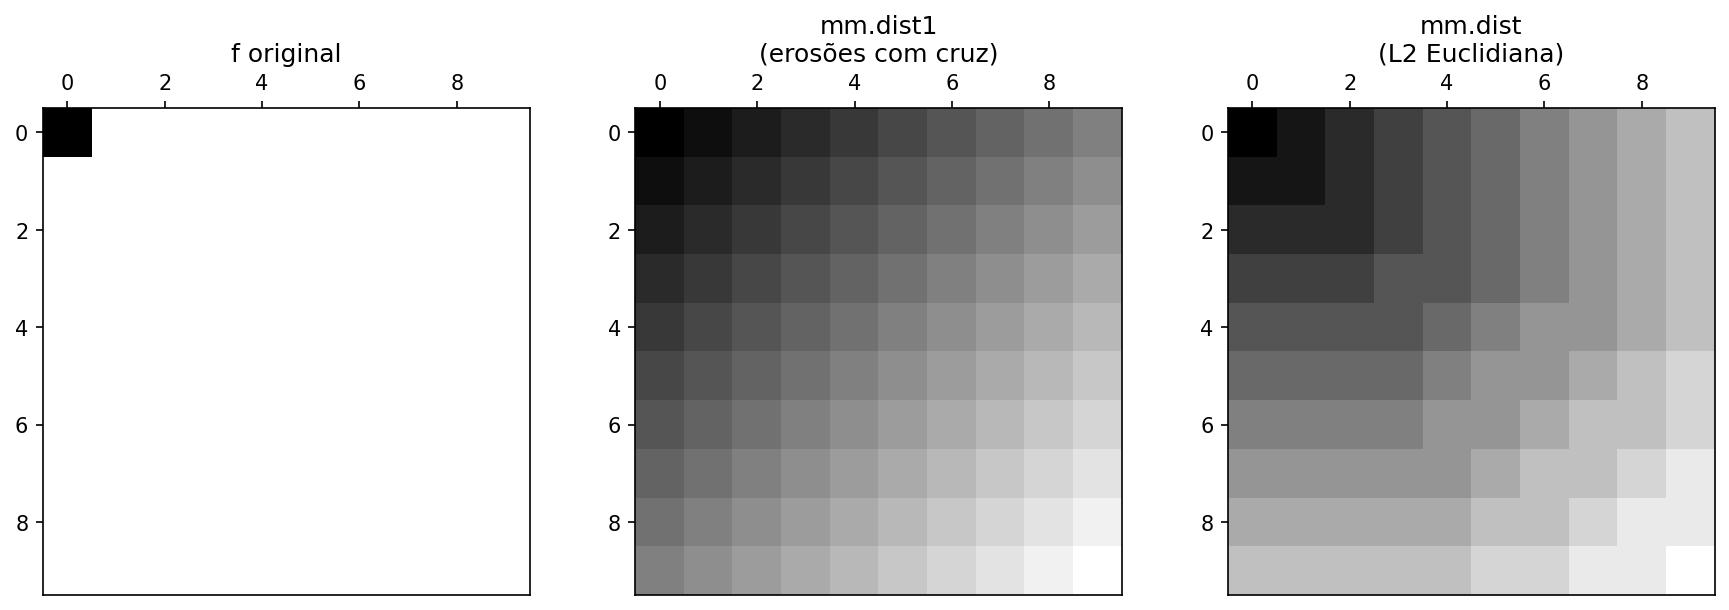

**Figura 4.20:** Transformada de Distância em imagem binária 10×10. Esquerda: imagem original (*foreground* = 255). Centro: mm.dist1 iterativa (erosões com elemento cruz). Direita: mm.dist (L2 Euclidiana).


In [ ]:
import numpy as np

# Imagem binária 10×10 com um único pixel de fundo (0,0) e o resto como objeto (255)
f = np.ones((10,10), dtype=np.uint8) * 255
f[0,0] = 0

B_cruz = np.array([
    [-np.inf, -1, -np.inf],
    [-1,      0, -1],
    [-np.inf, -1, -np.inf]
], dtype=float)

d_iter = mm.dist1(f, B_cruz)
d_l2   = mm.dist(f)

print(f"Máx. dist1 (erosões) : {d_iter.max()} px")
print(f"Máx. dist  (L2)      : {d_l2.max():.2f} px")
print(f"Posição do máximo dist1 : {np.where(d_iter == d_iter.max())}")
print(f"Posição do máximo dist  : {np.where(d_l2 == d_l2.max())}")

mm.show(
    [f,        d_iter,                    d_l2],
    titles=["f original", "mm.dist1\n(erosões com cruz)", "mm.dist\n(L2 Euclidiana)"],
    cols=3, figsize=(12, 4), axis=True
)

A anotação dos valores numéricos diretamente sobre os pixels permite verificar como `dist1` propaga as distâncias segundo a métrica induzida pela função estruturante utilizada. No caso do elemento cruz com custo unitário, os valores obtidos correspondem à distância de *Manhattan* ($L_1$). Embora `dist1` e `mm.dist` produzam valores numéricos distintos por adotarem métricas diferentes, ambas as transformadas preservam a estrutura topográfica dos objetos, fazendo com que seus máximos ocorram em regiões centrais semelhantes. Essa propriedade justifica o uso de `mm.dist` em aplicações práticas, devido à sua elevada eficiência computacional.

### 4.4.3 Transformada de Distância Euclidiana em quatro passos

O simulador da [Figura 4.21](#fig-04-sim-04-tde) implementa o algoritmo da TDE de Lotufo e Zampirolli (2001) em duas etapas. Na primeira etapa, a função `edt1` realiza uma transformação unidimensional vertical de forma sequencial (*in-place*), percorrendo cada coluna em *raster* (↓) e *anti-raster* (↑) para calcular as distâncias na direção vertical (dois passos: Sul e Norte). Na segunda etapa, a função `edt2` utiliza esse resultado como entrada e realiza uma propagação horizontal por filas: para cada linha da matriz, duas filas de prioridade, `Eq` e `Wq`, são inicializadas percorrendo os índices de coluna em sentidos opostos (`Eq` de `W-1` até `1`, `Wq` de `2` até `W`), de modo que cada pixel atualizado enfileira imediatamente seus vizinhos para reprocessamento dentro da mesma rodada (mais dois passos: Leste e Oeste). Esse mecanismo de fila permite aplicar erosões sucessivas com pesos ímpares crescentes (`b = 1, 3, 5, ...`, incrementado a cada iteração do laço externo) sem que a propagação fique presa em valores desatualizados, já que cada rodada resolve a cadeia de dependências horizontal por completo antes do próximo incremento de `b`. A convergência dessa propagação produz a Transformada de Distância Euclidiana  em toda a matriz, combinando a informação vertical obtida em `edt1` com a propagação horizontal em fila realizada em `edt2`.

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-tde" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-04-tde * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-04-tde canvas { display: block; border-radius: 8px; border: 1px solid #e4dcc8; cursor: crosshair; background: #ffffff; margin: 0 auto; }
  #sim-04-tde button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; transition: all .15s ease; display: inline-flex; align-items: center; gap: 5px; font-weight: 600; }
  #sim-04-tde button:hover { background: #e8dfcf; }
  #sim-04-tde button.sim04_edt_act { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-04-tde .sim04_edt_smtxt { font-size: 10.5px; color: #8a8371; line-height: 1.4; }
  #sim-04-tde .sim04_edt_mono { font-family: monospace; }
  #sim-04-tde .sim04_edt_statcard { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 8px 10px; text-align: center; min-width: 0; }
  #sim-04-tde .sim04_edt_statlabel { font-size: 9.5px; text-transform: uppercase; letter-spacing: .04em; color: #8a8371; margin-bottom: 2px; font-weight: 700; }
  #sim-04-tde .sim04_edt_statval { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  .sim04_edt_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">📐 EDT² 2D Corrigido · Matriz 4×4</span>
  <span style="background:#26241d;color:#7ee7c6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;font-family:monospace;">Convergência Exata</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Descrição Teórica -->
  <div class="sim04_edt_panel" style="margin-bottom:14px;">
    <div style="font-size:11.5px; font-weight:700; color:#26241d; margin-bottom:2px;">Passo 1: edt1 Vertical In-place · Passo 2: edt2 Horizontal In-place</div>
    <div class="sim04_edt_smtxt">Usa a mesma estrutura raster/anti-raster descrita no artigo para propagação de distâncias exatas (exemplo do artigo, pág. 103).</div>
  </div>

  <!-- Cards de Estatísticas -->
  <div style="display:grid; grid-template-columns:repeat(3, 1fr); gap:10px; margin-bottom:14px;">
    <div class="sim04_edt_statcard"><div class="sim04_edt_statlabel">Passo Atual</div><div class="sim04_edt_statval" id="sim04_edt_sStep" style="color:#c0392b;">–</div></div>
    <div class="sim04_edt_statcard"><div class="sim04_edt_statlabel">Fase</div><div class="sim04_edt_statval" id="sim04_edt_sPhase" style="color:#2980b9; font-size:12px;">–</div></div>
    <div class="sim04_edt_statcard"><div class="sim04_edt_statlabel">b Atual</div><div class="sim04_edt_statval" id="sim04_edt_sB" style="color:#b9770e;">–</div></div>
  </div>

  <!-- Canvas da Matriz 4x4 -->
  <div style="margin-bottom:14px; text-align:center;">
    <canvas id="sim04_edt_cvs"></canvas>
  </div>

  <!-- Barra de Ações -->
  <div style="display:flex; gap:6px; flex-wrap:wrap; margin-bottom:12px; align-items:center; justify-content:center;">
    <button id="sim04_edt_btnFinal" class="sim04_edt_act" data-action="final">Resultado Final</button>
    <button id="sim04_edt_btnStep" data-action="step">Passo a Passo</button>
    <div style="width:1px; background:#e4dcc8; height:20px;"></div>
    <button data-action="clear" style="border-color:#f5b7b1; color:#c0392b; background:#fdecea;">× Limpar</button>
  </div>

  <!-- Painel de Passo a Passo (Controles de Animação) -->
  <div id="sim04_edt_stepCtrl" style="display:none;" class="sim04_edt_panel">
    <div style="display:flex; gap:6px; align-items:center; flex-wrap:wrap;">
      <button data-action="prev">◀ Anterior</button>
      <button id="sim04_edt_btnPlay" data-action="play">▶ Play</button>
      <button data-action="next">Próximo ▶</button>
      <span class="sim04_edt_smtxt" style="margin-left:4px; font-weight:700;">Vel.:</span>
      <input type="range" id="sim04_edt_speedSlider" min="1" max="10" value="5" step="1" style="width:70px; cursor:pointer;">
      <span id="sim04_edt_stepLabel" class="sim04_edt_mono" style="font-size:10.5px; color:#5e5a4a; flex:1; text-align:right; min-width:0; overflow:hidden; text-overflow:ellipsis; white-space:nowrap;"></span>
    </div>
  </div>

</div>
</div>

<script>
(function(){
  function initSim04EdtConvergencia(root){
    if (!root || root.dataset.initDone) return;
    root.dataset.initDone = "1";

    const COLS=4, ROWS=4, CELL=50, PAD=20, INF=9999;
    const cv = root.querySelector('#sim04_edt_cvs');
    const CTX = cv.getContext('2d');

    cv.width = COLS * CELL + PAD * 2;
    cv.height = ROWS * CELL + PAD * 2;

    let grid = [
      [1, 1, 0, 1],
      [1, 1, 1, 1],
      [1, 0, 1, 1],
      [0, 1, 1, 1]
    ];

    let mode='final';
    let steps=[], stepIdx=0;
    let playing=false, playTimer=null;

    function getCol(d) {
      if(d === 0) return { fill: 'transparent', txt: '#8a8371', bdr: '#e4dcc8' };
      if(d >= INF) return { fill: '#fdecea', txt: '#c0392b', bdr: '#f5b7b1' };
      const colors = ['#ebf4fd', '#a9cce3', '#73c6b6', '#52be80', '#27ae60', '#2980b9', '#1b4f72'];
      let idx = Math.min(colors.length - 1, Math.floor(d / 1.5));
      return { fill: colors[idx], txt: idx > 3 ? '#ffffff' : '#26241d', bdr: colors[Math.min(idx+1, colors.length-1)] };
    }

    function drawMatrix(matrix, opts={}) {
      CTX.clearRect(0, 0, cv.width, cv.height);
      for(let r=0; r<ROWS; r++) {
        for(let c=0; c<COLS; c++) {
          const px = PAD + c * CELL; const py = PAD + r * CELL;
          const d = matrix[r][c]; const col = getCol(d);

          CTX.fillStyle = col.fill; CTX.fillRect(px+1, py+1, CELL-2, CELL-2);

          const isCur = opts.cursor && opts.cursor.r === r && opts.cursor.c === c;
          const isChg = opts.changed && opts.changed[r][c];

          CTX.strokeStyle = isCur ? '#c0392b' : isChg ? '#b9770e' : col.bdr;
          CTX.lineWidth = isCur ? 3 : isChg ? 2.5 : 0.5;
          CTX.strokeRect(px+0.5, py+0.5, CELL-1, CELL-1);

          CTX.fillStyle = col.txt; CTX.font = 'bold 14px monospace';
          CTX.textAlign = 'center'; CTX.textBaseline = 'middle';
          CTX.fillText(d >= INF ? '∞' : String(d), px + CELL/2, py + CELL/2);

          if (r === 0) { CTX.fillStyle='#8a8371'; CTX.font='9px monospace'; CTX.fillText('c'+c, px+CELL/2, PAD/2); }
          if (c === 0) { CTX.fillStyle='#8a8371'; CTX.font='9px monospace'; CTX.fillText('r'+r, PAD/2, py+CELL/2); }
        }
      }
    }

    function copyMat(m) { return m.map(row => [...row]); }

    function computeEdt1(gInit) {
      const all = [];
      let g = copyMat(gInit);
      all.push({ phase: 'edt1_init', g: copyMat(g), cursor: null, b: 0, changed: null, label: 'edt1 · Matriz de entrada inicializada' });

      for(let c=0; c<COLS; c++) {
        let b = 1;
        for(let r=1; r<ROWS; r++) {
          let chg = Array.from({length:ROWS}, () => new Array(COLS).fill(0));
          if(grid[r][c] && g[r-1][c] < INF) {
            if(g[r][c] > g[r-1][c] + b) {
              g[r][c] = g[r-1][c] + b; chg[r][c] = 1;
              all.push({ phase: 'edt1_raster', g: copyMat(g), cursor: {r, c}, b, changed: chg, label: 'edt1 raster ↓ · f(' + r + ',' + c + ') = f(' + (r-1) + ',' + c + ') + b(' + b + ') = ' + g[r][c] });
              b += 2;
            } else {
              b = 1;
              all.push({ phase: 'edt1_raster', g: copyMat(g), cursor: {r, c}, b, changed: null, label: 'edt1 raster ↓ · f(' + r + ',' + c + ') já menor · b=1' });
            }
          } else { b = 1; }
        }
      }

      for(let c=0; c<COLS; c++) {
        let b = 1;
        for(let r=ROWS-2; r>=0; r--) {
          let chg = Array.from({length:ROWS}, () => new Array(COLS).fill(0));
          if(grid[r][c] && g[r+1][c] < INF) {
            if(g[r][c] > g[r+1][c] + b) {
              g[r][c] = g[r+1][c] + b; chg[r][c] = 1;
              all.push({ phase: 'edt1_anti', g: copyMat(g), cursor: {r, c}, b, changed: chg, label: 'edt1 anti-raster ↑ · f(' + r + ',' + c + ') = f(' + (r+1) + ',' + c + ') + b(' + b + ') = ' + g[r][c] });
              b += 2;
            } else {
              b = 1;
              all.push({ phase: 'edt1_anti', g: copyMat(g), cursor: {r, c}, b, changed: null, label: 'edt1 anti-raster ↑ · f(' + r + ',' + c + ') já menor · b=1' });
            }
          } else { b = 1; }
        }
      }
      return { steps: all, g: copyMat(g) };
    }

    function computeEdt2(gIn) {
      const all = [];
      let g = copyMat(gIn);
      all.push({ phase: 'edt2_init', g: copyMat(g), cursor: null, b: 0, changed: null, label: 'edt2 · Estado inicial f_v antes da propagação horizontal' });

      for(let r=0; r<ROWS; r++) {
        let b = 1;
        for(let c=1; c<COLS; c++) {
          let chg = Array.from({length:ROWS}, () => new Array(COLS).fill(0));
          if(grid[r][c] && g[r][c-1] < INF) {
            if(g[r][c] > g[r][c-1] + b) {
              g[r][c] = g[r][c-1] + b; chg[r][c] = 1;
              all.push({ phase: 'edt2_raster', g: copyMat(g), cursor: {r, c}, b, changed: chg, label: 'edt2 raster → · f(' + r + ',' + c + ') = f(' + r + ',' + (c-1) + ') + b(' + b + ') = ' + g[r][c] });
              b += 2;
            } else {
              b = 1;
              all.push({ phase: 'edt2_raster', g: copyMat(g), cursor: {r, c}, b, changed: null, label: 'edt2 raster → · f(' + r + ',' + c + ') já menor · b=1' });
            }
          } else { b = 1; }
        }
      }

      for(let r=0; r<ROWS; r++) {
        let b = 1;
        for(let c=COLS-2; c>=0; c--) {
          let chg = Array.from({length:ROWS}, () => new Array(COLS).fill(0));
          if(grid[r][c] && g[r][c+1] < INF) {
            if(g[r][c] > g[r][c+1] + b) {
              g[r][c] = g[r][c+1] + b; chg[r][c] = 1;
              all.push({ phase: 'edt2_anti', g: copyMat(g), cursor: {r, c}, b, changed: chg, label: 'edt2 anti-raster ← · f(' + r + ',' + c + ') = f(' + r + ',' + (c+1) + ') + b(' + b + ') = ' + g[r][c] });
              b += 2;
            } else {
              b = 1;
              all.push({ phase: 'edt2_anti', g: copyMat(g), cursor: {r, c}, b, changed: null, label: 'edt2 anti-raster ← · f(' + r + ',' + c + ') já menor · b=1' });
            }
          } else { b = 1; }
        }
      }

      all.push({ phase: 'edt2_done', g: copyMat(g), cursor: null, b: 0, changed: null, label: 'Convergência final atingida!' });
      return { steps: all, g: copyMat(g) };
    }

    function computeAll() {
      const gInit = Array.from({length: ROWS}, (_, r) => Array.from({length: COLS}, (_, c) => grid[r][c] ? INF : 0));
      const r1 = computeEdt1(gInit); const r2 = computeEdt2(r1.g);
      return [...r1.steps, ...r2.steps];
    }

    function setMode(m) {
      mode = m; stopPlay();
      root.querySelector('#sim04_edt_btnFinal').className = m === 'final' ? 'sim04_edt_act' : '';
      root.querySelector('#sim04_edt_btnStep').className = m === 'step' ? 'sim04_edt_act' : '';
      root.querySelector('#sim04_edt_stepCtrl').style.display = m === 'step' ? 'block' : 'none';

      if(m === 'step') {
        steps = computeAll(); stepIdx = 0; drawFrame();
      } else {
        const finalSteps = computeAll();
        drawMatrix(finalSteps[finalSteps.length - 1].g);
        root.querySelector('#sim04_edt_sStep').textContent = 'Final';
        root.querySelector('#sim04_edt_sPhase').textContent = 'Concluído';
        root.querySelector('#sim04_edt_sB').textContent = '–';
      }
    }

    function drawFrame() {
      if(!steps.length) return;
      const s = steps[Math.min(stepIdx, steps.length - 1)];
      drawMatrix(s.g, { cursor: s.cursor, changed: s.changed });
      root.querySelector('#sim04_edt_sStep').textContent = (stepIdx + 1) + '/' + steps.length;
      root.querySelector('#sim04_edt_sPhase').textContent = s.phase;
      root.querySelector('#sim04_edt_sB').textContent = s.b > 0 ? s.b : '–';
      root.querySelector('#sim04_edt_stepLabel').textContent = s.label;
    }

    function goStep(d) {
      stepIdx = Math.max(0, Math.min(steps.length - 1, stepIdx + d));
      drawFrame();
    }

    function togglePlay() { playing ? stopPlay() : startPlay(); }
    function startPlay() {
      playing = true; root.querySelector('#sim04_edt_btnPlay').textContent = '⏸ Pausar';
      function tick() {
        if(stepIdx >= steps.length - 1) { stopPlay(); return; }
        stepIdx++; drawFrame();
        playTimer = setTimeout(tick, Math.round(1300 - (+root.querySelector('#sim04_edt_speedSlider').value) * 110));
      }
      tick();
    }
    function stopPlay() { playing = false; if(playTimer) clearTimeout(playTimer); const b = root.querySelector('#sim04_edt_btnPlay'); if(b) b.textContent = '▶ Play'; }

    function clearGrid() { grid = Array.from({length: ROWS}, () => new Array(COLS).fill(0)); refresh(); }
    function refresh() { stopPlay(); if(mode === 'step') { steps = computeAll(); stepIdx = Math.min(stepIdx, steps.length - 1); drawFrame(); } else { setMode('final'); } }

    cv.addEventListener('mousedown', e => {
      const rect = cv.getBoundingClientRect();
      const c = Math.floor(((e.clientX - rect.left) * (cv.width / rect.width) - PAD) / CELL);
      const r = Math.floor(((e.clientY - rect.top) * (cv.height / rect.height) - PAD) / CELL);
      if(r >= 0 && r < ROWS && c >= 0 && c < COLS) { grid[r][c] = grid[r][c] ? 0 : 1; refresh(); }
    });

    root.querySelectorAll('[data-action]').forEach(btn => {
      btn.addEventListener('click', function() {
        const act = this.getAttribute('data-action');
        if(act === 'final') setMode('final');
        if(act === 'step') setMode('step');
        if(act === 'clear') clearGrid();
        if(act === 'prev') goStep(-1);
        if(act === 'next') goStep(1);
        if(act === 'play') togglePlay();
      });
    });

    setMode('final');
  }

  function tryInit(){
    var root = document.getElementById('sim-04-tde');
    if (root) initSim04EdtConvergencia(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
""")

**Figura 4.21:** Simulador interativo 2D (4x4) com sincronização estrita de filas de propagação horizontal (b) para obter a convergência exata descrita no artigo.


#### 4.4.3.1 Transformada de Distância Geodésica

A transformada de distância geodésica associa a cada pixel a menor distância até um marcador, sob a restrição imposta por uma máscara. Dessa forma, a propagação ocorre exclusivamente pelos pixels permitidos, preservando a conectividade do domínio.

A [Figura 4.22](#fig-04-gdist-menor-caminho) ilustra esse processo em um labirinto: (a) a máscara `g`; (b) a distância geodésica `D1` calculada a partir da entrada; (c) a distância `D2` calculada a partir da saída; e (d) o caminho mínimo obtido a partir dessas duas transformadas.

O caminho ótimo é determinado pela soma das distâncias (`D1 + D2`). Os pixels pertencentes à trajetória mínima são aqueles para os quais essa soma assume seu menor valor, definindo uma conexão entre entrada e saída com comprimento geodésico mínimo.

Esse princípio permite resolver labirintos sem a necessidade de explorar explicitamente todas as possibilidades de percurso. A solução emerge diretamente da propagação de distâncias em um domínio restrito. Essa abordagem é particularmente relevante em labirintos de elevada complexidade, como os construídos a partir de estruturas quasicristalinas e ciclos hamiltonianos descritos por Singh et al. (2024). Em Zampirolli et al. (2025), esse mesmo formalismo é empregado para resolver um labirinto complexo; a seguir, o método é ilustrado em uma versão simplificada do problema.

Distância geodésica mínima: 15


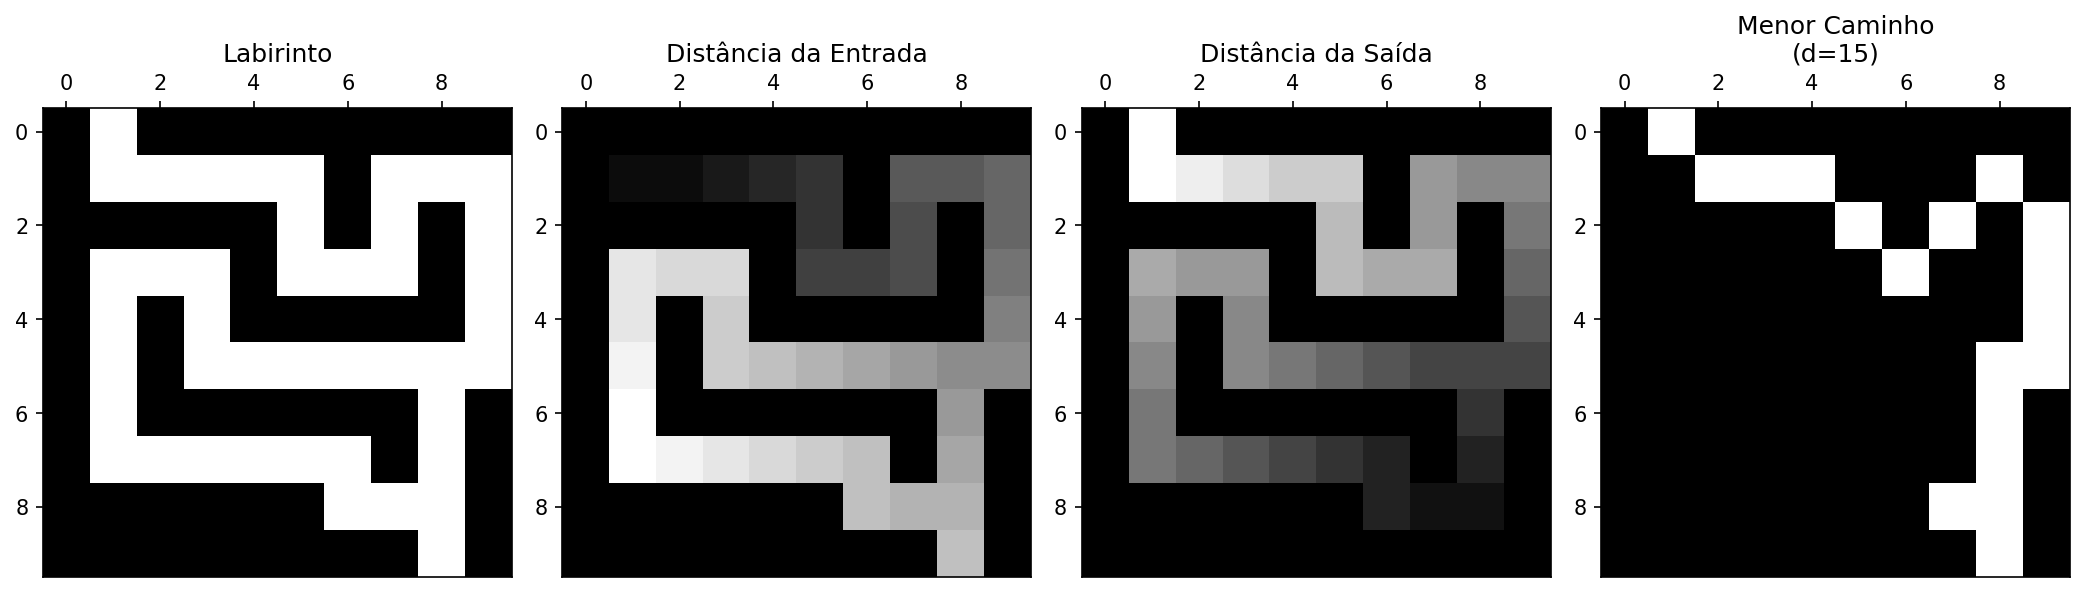

**Figura 4.22:** Menor caminho geodésico em um labirinto. As distâncias geodésicas são calculadas a partir da entrada e da saída usando mm.gdist. Os pixels cujo somatório das duas distâncias é igual à distância mínima entre os marcadores pertencem a um caminho ótimo.


In [ ]:
import numpy as np

# 1 = corredor, 0 = parede
g = np.array([
 [0,1,0,0,0,0,0,0,0,0],
 [0,1,1,1,1,1,0,1,1,1],
 [0,0,0,0,0,1,0,1,0,1],
 [0,1,1,1,0,1,1,1,0,1],
 [0,1,0,1,0,0,0,0,0,1],
 [0,1,0,1,1,1,1,1,1,1],
 [0,1,0,0,0,0,0,0,1,0],
 [0,1,1,1,1,1,1,0,1,0],
 [0,0,0,0,0,0,1,1,1,0],
 [0,0,0,0,0,0,0,0,1,0]
], dtype=np.uint8)

# marcador da entrada
entrada = np.zeros_like(g, dtype=np.uint8)
entrada[0,1] = 1

# marcador da saída
saida = np.zeros_like(g, dtype=np.uint8)
saida[9,8] = 1

# distâncias geodésicas
D1 = mm.gdist(g, entrada)
D2 = mm.gdist(g, saida)

# soma das distâncias
S = D1 + D2

# menor valor válido da soma
dmin = np.min(S[S > 0])

# pixels pertencentes a um caminho ótimo
caminho = (S == dmin)

print("Distância geodésica mínima:", dmin)

mm.show(
    [g, D1, D2, caminho],
    titles=[
        "Labirinto",
        "Distância da Entrada",
        "Distância da Saída",
        f"Menor Caminho\n(d={dmin})"
    ],
    cols=4,
    figsize=(14,4),
    axis=True
)

### 4.4.4 Segmentação por *Watershed*

O algoritmo ***Watershed*** interpreta uma imagem em níveis de cinza como uma superfície topográfica, na qual valores elevados correspondem a montanhas e valores baixos correspondem a vales ou bacias de drenagem (*catchment basins*). No contexto da segmentação baseada em marcadores, os máximos da Transformada de Distância são frequentemente utilizados para identificar regiões internas aos objetos, fornecendo sementes confiáveis para o processo de inundação.

A segmentação é então realizada por uma simulação conceitual de inundação progressiva a partir desses marcadores. À medida que as bacias associadas a diferentes sementes se expandem, regiões vizinhas eventualmente entram em contato. Nesse instante são construídas barreiras virtuais, denominadas *watershed lines*, que passam a delimitar os objetos da cena. Esse mecanismo permite separar objetos adjacentes ou parcialmente sobrepostos, mesmo quando eles formam uma única componente conexa após a limiarização.

A implementação didática apresentada neste capítulo explora inicialmente o conceito de crescimento de regiões (*region growing*) confinado por uma máscara binária, conforme detalhado no algoritmo interativo da [Figura 4.23](#fig-04-sim-alg-watershed2).

> ### 📝 Versão didática versus implementação clássica
>
> A função `mm.watershed0` não implementa o algoritmo *watershed* clássico. Seu objetivo é ilustrar, de forma simplificada, a propagação de marcadores por crescimento de regiões (*region growing*), permitindo visualizar como diferentes sementes competem pela ocupação do espaço disponível. O crescimento é delimitado por uma máscara binária de suporte e monitorado por um controle de estagnação, gerando um resultado semelhante a uma partição de Voronoi restrita à geometria dos objetos de entrada.
>
> Já a função `mm.watershed` utiliza a implementação otimizada do OpenCV (`cv2.watershed`), que realiza a inundação sobre uma superfície topográfica definida pela imagem de entrada. Nesse caso, a propagação dos marcadores é influenciada pelos valores dos pixels, fazendo com que as linhas de separação se formem naturalmente sobre as cristas do relevo.

In [ ]:
# @title { display-mode: "form" }
# Prefixo exclusivo para evitar conflito com outras células do notebook
PREFIX = "wat0"

from IPython.display import HTML
HTML(f'''
<style>
*{{box-sizing:border-box;margin:0;padding:0}}
body{{font-family:var(--font-sans)}}
.{PREFIX}-tabs{{display:flex;gap:6px;margin-bottom:20px;flex-wrap:wrap}}
.{PREFIX}-tab{{padding:6px 14px;border-radius:20px;font-size:13px;cursor:pointer;border:0.5px solid var(--color-border-secondary);background:var(--color-background-primary);color:var(--color-text-secondary);transition:all .15s;white-space:nowrap}}
.{PREFIX}-tab.active{{background:var(--color-text-primary);color:var(--color-background-primary);border-color:transparent}}
.{PREFIX}-panel{{display:none}}.{PREFIX}-panel.active{{display:block}}

.algo-wrap{{background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.algo-header{{padding:14px 20px;border-bottom:0.5px solid var(--color-border-tertiary);display:flex;align-items:center;gap:10px}}
.algo-icon{{width:32px;height:32px;border-radius:var(--border-radius-md);display:flex;align-items:center;justify-content:center;font-size:16px;background:#EBF7F2;color:#0F6E56}}
.algo-title{{font-size:14px;font-weight:500;color:var(--color-text-primary);text-align:left}}
.algo-sub{{font-size:12px;color:var(--color-text-secondary);margin-top:1px;text-align:left}}
.algo-body{{padding:20px;text-align:left}}

.step{{display:flex;gap:12px;margin-bottom:14px;align-items:flex-start}}
.step:last-child{{margin-bottom:0}}
.step-num{{min-width:24px;height:24px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0;margin-top:1px}}
.step-text{{font-size:13.5px;line-height:1.65;color:var(--color-text-primary);text-align:left}}
.step-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 6px;border-radius:4px;color:var(--color-text-primary)}}
.step-sub{{margin-top:8px;border-left:2px solid var(--color-border-secondary);padding-left:12px;display:flex;flex-direction:column;gap:5px}}
.step-sub-item{{font-size:13px;color:var(--color-text-secondary);line-height:1.55;text-align:left}}
.step-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.while-box{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);padding:11px 13px;margin-top:8px;text-align:left}}
.while-head{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.06em;margin-bottom:7px}}
.note{{margin-top:16px;padding-top:12px;border-top:0.5px solid var(--color-border-tertiary);font-size:12px;color:var(--color-text-secondary);font-style:italic;line-height:1.5;text-align:left}}

.num-teal{{background:#E1F5EE;color:#0F6E56}}
.num-purple{{background:#EEEDFE;color:#534AB7}}
.num-amber{{background:#FAEEDA;color:#854F0B}}
.num-coral{{background:#FAECE7;color:#993C1D}}
.num-blue{{background:#E6F1FB;color:#185FA5}}
.num-gray{{background:var(--color-background-secondary);color:var(--color-text-secondary)}}

.card-step{{display:flex;border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);overflow:hidden;margin-bottom:8px}}
.card-step:last-child{{margin-bottom:0}}
.card-badge{{min-width:48px;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:500;flex-shrink:0}}
.card-content{{padding:10px 14px;flex:1;text-align:left}}
.card-label{{font-size:10px;font-weight:500;letter-spacing:.08em;text-transform:uppercase;margin-bottom:3px}}
.card-text{{font-size:13.5px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.card-text code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}
.card-sub{{margin-top:6px;display:flex;flex-direction:column;gap:3px}}
.card-sub-item{{font-size:12.5px;color:var(--color-text-secondary);padding-left:10px;border-left:2px solid var(--color-border-secondary);line-height:1.5;text-align:left}}
.card-sub-item code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 4px;border-radius:3px;color:var(--color-text-primary)}}

.tl{{position:relative;padding:4px 0 4px 36px;text-align:left}}
.tl-line{{position:absolute;left:11px;top:20px;bottom:20px;width:1.5px;background:var(--color-border-secondary);border-radius:2px}}
.tl-step{{display:flex;gap:0;margin-bottom:18px;position:relative}}
.tl-step:last-child{{margin-bottom:0}}
.tl-dot-wrap{{position:absolute;left:-36px;top:2px;display:flex;flex-direction:column;align-items:center;gap:3px}}
.tl-dot{{width:14px;height:14px;border-radius:50%;border:2px solid var(--color-border-secondary);background:var(--color-background-primary);transition:all .2s;z-index:1}}
.tl-step:hover .tl-dot{{background:var(--color-text-primary);border-color:var(--color-text-primary)}}
.tl-num{{font-size:9px;color:var(--color-text-secondary);font-weight:500;letter-spacing:.04em}}
.tl-title{{font-size:13.5px;font-weight:500;color:var(--color-text-primary);margin-bottom:3px;text-align:left}}
.tl-desc{{font-size:13px;color:var(--color-text-secondary);line-height:1.6;text-align:left}}
.tl-desc code{{font-family:var(--font-mono);font-size:12px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}

.code-wrap{{background:var(--color-background-secondary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-lg);overflow:hidden}}
.code-bar{{background:var(--color-background-secondary);padding:10px 16px;display:flex;align-items:center;justify-content:space-between;border-bottom:0.5px solid var(--color-border-tertiary)}}
.code-lang{{font-size:11px;font-weight:500;color:var(--color-text-secondary);text-transform:uppercase;letter-spacing:.08em}}
.code-body{{padding:18px 20px;overflow-x:auto;text-align:left}}
.code-body pre{{font-family:var(--font-mono);font-size:13px;line-height:1.75;color:var(--color-text-primary);margin:0;white-space:pre;text-align:left}}
.kw{{color:#7C3AED}} .fn{{color:#0369A1}} .cm{{color:#6B7280;font-style:italic}} .st{{color:#059669}} .num-lit{{color:#DC2626}}

.ann-line{{display:flex;align-items:flex-start;gap:10px;margin-bottom:8px;padding:10px 12px;background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);text-align:left}}
.ann-badge{{min-width:20px;height:20px;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:500;flex-shrink:0;margin-top:1px}}
.ann-text{{font-size:13px;line-height:1.6;color:var(--color-text-primary);text-align:left}}
.ann-text code{{font-family:var(--font-mono);font-size:11.5px;background:var(--color-background-secondary);padding:1px 5px;border-radius:3px;color:var(--color-text-primary)}}

.metric-grid{{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:10px;margin-top:16px}}
.metric-card{{background:var(--color-background-primary);border:0.5px solid var(--color-border-tertiary);border-radius:var(--border-radius-md);padding:12px 14px;text-align:left}}
.metric-title{{font-size:11px;font-weight:500;text-transform:uppercase;letter-spacing:.07em;margin-bottom:6px}}
.metric-formula{{font-family:var(--font-mono);font-size:12px;color:var(--color-text-primary);margin-bottom:4px}}
.metric-desc{{font-size:12px;color:var(--color-text-secondary);line-height:1.5}}
</style>

<h2 class="sr-only" style="position:absolute;left:-9999px">Algoritmo Didático do Watershed Limitado por Máscara — painel interativo</h2>

<div class="{PREFIX}-tabs" id="{PREFIX}-tabs-container">
  <div class="{PREFIX}-tab" data-idx="0"><i class="ti ti-list-numbers" aria-hidden="true"></i> Passo a passo</div>
  <div class="{PREFIX}-tab" data-idx="1"><i class="ti ti-cards" aria-hidden="true"></i> Cards</div>
  <div class="{PREFIX}-tab" data-idx="2"><i class="ti ti-timeline" aria-hidden="true"></i> Linha do tempo</div>
  <div class="{PREFIX}-tab" data-idx="3"><i class="ti ti-code" aria-hidden="true"></i> Código Python</div>
  <div class="{PREFIX}-tab active" data-idx="4"><i class="ti ti-git-branch" aria-hidden="true"></i> Fluxograma</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-0">
<div class="algo-wrap">
  <div class="algo-header">
    <div class="algo-icon"><i class="ti ti-bucket" aria-hidden="true"></i></div>
    <div><div class="algo-title">Crescimento de Regiões Confinado por Máscara</div><div class="algo-sub">Inundação concorrente com restrição geométrica de suporte e sincronização síncrona por malha</div></div>
  </div>
  <div class="algo-body">
    <div class="step"><div class="step-num num-teal">1</div><div class="step-text">Rotular os marcadores sementes em <code>f</code> via <code>mm.label0(f, b)</code>, instanciar a malha dinâmica <code>g ← f.copy()</code> e binarizar a <code>mask</code>.</div></div>
    <div class="step">
      <div class="step-num num-coral">2</div>
      <div class="step-text">
        Enquanto houver pixels não rotulados (<code>while True</code>), reiniciar o controle de atividade <code>mudou ← False</code> e varrer a imagem:
        <div class="step-sub">
          <div class="step-sub-item">Identificar se a coordenada atual é um vazio contido no escopo: <code>g[x,y] == 0 and mask[x,y]</code>.</div>
          <div class="step-sub-item">Avaliar a vizinhança estrutural em <code>mm._viz(f, b, x, y)</code> baseada no estado síncrono estável <code>f</code>.</div>
          <div class="step-sub-item">Se um vizinho possuir rótulo dominante (<code>g[x,y] < f[vy,vx]</code>), a célula em <code>g</code> absorve esse identificador e marca-se <code>mudou ← True</code>.</div>
        </div>
      </div>
    </div>
    <div class="step"><div class="step-num num-purple">3</div><div class="step-text">Verificar ponto fixo: caso uma varredura completa não expanda nenhuma fronteira (<code>not mudou</code>), interrompe-se o laço (<code>break</code>).</div></div>
    <div class="step"><div class="step-num num-blue">4</div><div class="step-text">Atualizar o estado de referência de forma síncrona para a próxima iteração: <code>f ← g.copy()</code>.</div></div>
    <div class="step"><div class="step-num num-blue">5</div><div class="step-text">Se <code>op == 'region'</code>, retornar o mapa de bacias <code>g</code>; caso contrário, extrair as cristas divisórias via <code>mm.gradm(g)</code>.</div></div>
    <div class="note">A sincronização <code>f = g.copy()</code> ao final de cada ciclo impede o crescimento assimétrico ou dependente da ordem da varredura raster (propagação em estilo Jacobi).</div>
  </div>
</div>

<div class="metric-grid">
  <div class="metric-card">
    <div class="metric-title" style="color:#0F6E56">Escopo Geométrico</div>
    <div class="metric-formula">mask[x,y] > 0</div>
    <div class="metric-desc">Restrição binária rígida impedindo o avanço periférico de rótulos.</div>
  </div>
  <div class="metric-card">
    <div class="metric-title" style="color:#993C1D">Estabilização</div>
    <div class="metric-formula">if not mudou: break</div>
    <div class="metric-desc">Evita loops infinitos interrompendo ao saturar o domínio da máscara.</div>
  </div>
  <div class="metric-card">
    <div class="metric-title" style="color:#185FA5">Mapeamento Jacobi</div>
    <div class="metric-formula">f = g.copy()</div>
    <div class="metric-desc">Sincronização em bloco após inspeção de todas as coordenadas.</div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-1">
  <div class="card-step">
    <div class="card-badge num-teal">01</div>
    <div class="card-content">
      <div class="card-label" style="color:#0F6E56">Inicialização</div>
      <div class="card-text">Geração dos identificadores iniciais pelo mapeamento de componentes conexas e binarização da máscara de suporte.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-coral">02</div>
    <div class="card-content">
      <div class="card-label" style="color:#993C1D">Expansão Concorrente</div>
      <div class="card-text">Varredura 2D inspecionando vazios internos autorizados. A malha de trabalho <code>g</code> absorve os rótulos lidos da referência estável <code>f</code>.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-purple">03</div>
    <div class="card-content">
      <div class="card-label" style="color:#534AB7">Ponto Fixo Local</div>
      <div class="card-text">A flag <code>mudou</code> monitora mudanças estruturais. Se nenhuma frente avançar, o laço de inundação é finalizado via <code>break</code>.</div>
    </div>
  </div>
  <div class="card-step">
    <div class="card-badge num-blue">04</div>
    <div class="card-content">
      <div class="card-label" style="color:#185FA5">Sincronização e Saída</div>
      <div class="card-text">Atualização em bloco do estado referencial. A saída pode ser moldada como partições regionais ou linhas de cristas (linhas de watershed).</div>
    </div>
  </div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-2">
<div class="tl">
  <div class="tl-line"></div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">01</span></div>
    <div><div class="tl-title">Condicionamento Prévio</div><div class="tl-desc">Rotulagem preliminar de marcadores e isolamento booleano do domínio.</div></div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">02</span></div>
    <div>
      <div class="tl-title">Laço Síncrono Iterativo</div>
      <div class="while-box">
        <div class="while-head">while True</div>
        <div class="step-sub" style="border-color:var(--color-border-tertiary)">
          <div class="step-sub-item">Redefinição de flag: <code>mudou = False</code></div>
          <div class="step-sub-item">Crescimento condicional: se <code>g[x,y] == 0</code> e estiver na máscara, expande lendo <code>f</code></div>
          <div class="step-sub-item">Controle de estabilidade: <code>if not mudou: break</code></div>
          <div class="step-sub-item">Atualização síncrona: <code>f = g.copy()</code></div>
        </div>
      </div>
    </div>
  </div>
  <div class="tl-step">
    <div class="tl-dot-wrap"><div class="tl-dot"></div><span class="tl-num">03</span></div>
    <div><div class="tl-title">Extração Topológica</div><div class="tl-desc">Retorno condicional das bacias preenchidas ou cálculo morfológico do gradiente de transição.</div></div>
  </div>
</div>
</div>

<div class="{PREFIX}-panel" id="{PREFIX}-p-3">
<div class="code-wrap">
  <div class="code-bar">
    <span class="code-lang"><i class="ti ti-brand-python" aria-hidden="true" style="font-size:14px;vertical-align:-2px;margin-right:5px"></i>mm_watershed.py</span>
    <span style="font-size:11px;color:var(--color-text-secondary)">Algoritmo com Restrição de Máscara</span>
  </div>
  <div class="code-body">
<pre><span class="kw">def</span> <span class="fn">watershed0</span>(f, mask=<span class="fn">None</span>, b=np.zeros((<span class="num-lit">3</span>,<span class="num-lit">3</span>),dtype=<span class="st">'uint8'</span>), op=<span class="st">'region'</span>):
    f = mm.label0(f, b)
    g = f.copy()
    mask = np.ones_like(f) <span class="kw">if</span> mask <span class="kw">is</span> <span class="fn">None</span> <span class="kw">else</span> (mask > <span class="num-lit">0</span>)
    
    <span class="kw">while</span> <span class="fn">True</span>:
        mudou = <span class="fn">False</span>
        <span class="kw">for</span> x <span class="kw">in</span> <span class="fn">range</span>(f.shape[<span class="num-lit">0</span>]):
            <span class="kw">for</span> y <span class="kw">in</span> <span class="fn">range</span>(f.shape[<span class="num-lit">1</span>]):
                <span class="kw">if</span> g[x,y] == <span class="num-lit">0</span> <span class="kw">and</span> mask[x,y]:
                    <span class="kw">for</span> vy,vx,bv <span class="kw">in</span> mm._viz(f, b, x, y):
                        <span class="kw">if</span> bv <span class="kw">and g[x,y] < f[vy,vx]</span>: 
                            g[x,y] = f[vy,vx]
                            mudou = <span class="fn">True</span>
        <span class="kw">if</span> <span class="kw">not</span> mudou: 
            <span class="kw">break</span>
        f = g.copy()
        
    <span class="kw">return</span> g <span class="kw">if</span> op == <span class="st">'region'</span> <span class="kw">else</span> mm.gradm(g, mm.secross())</pre>
  </div>
</div>

<div style="margin-top:16px;display:flex;flex-direction:column;gap:8px;text-align:left">
  <div class="ann-line"><div class="ann-badge num-teal">1</div><div class="ann-text"><code>mask = (mask &gt; 0)</code> — Converte a imagem de suporte informada para um mapa Booleano indexável.</div></div>
  <div class="ann-line"><div class="ann-badge num-coral">2</div><div class="ann-text"><code>g[x,y] == 0 and mask[x,y]</code> — Filtro ativo: pixels fora da máscara (fundo zero) são ignorados de imediato, confinando as frentes de expansão.</div></div>
  <div class="ann-line"><div class="ann-badge num-purple">3</div><div class="ann-text"><code>if not mudou: break</code> — Mecanismo de escape. Quando todos os espaços internos permitidos forem preenchidos ou estabilizados contra a barreira, o laço aborta de forma limpa.</div></div>
</div>
</div>

<div class="{PREFIX}-panel active" id="{PREFIX}-p-4">
<svg viewBox="0 0 580 840" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:580px;display:block;margin:0 auto">
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#888780"/></marker>
    <marker id="arr-b" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#185FA5"/></marker>
    <marker id="arr-r" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#993C1D"/></marker>
    <marker id="arr-g" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#0F6E56"/></marker>
    <marker id="arr-p" markerWidth="8" markerHeight="8" refX="6" refY="3" orient="auto"><path d="M1,1 L1,5 L7,3 Z" fill="#534AB7"/></marker>
  </defs>

  <ellipse cx="280" cy="36" rx="60" ry="22" fill="#E1F5EE" stroke="#0F6E56" stroke-width="1"/>
  <text x="280" y="41" text-anchor="middle" font-size="13" font-weight="500" fill="#085041">início</text>

  <rect x="130" y="85" width="300" height="52" rx="6" fill="#E1F5EE" stroke="#9FE1CB" stroke-width="1"/>
  <text x="280" y="104" text-anchor="middle" font-size="12" font-weight="500" fill="#0F6E56">rotular sementes e normalizar máscara</text>
  <text x="280" y="121" text-anchor="middle" font-size="11" fill="#085041">f ← mm.label0(f, b) ; g ← f.copy() ; mask ← mask > 0</text>

  <polygon points="280,166 390,196 280,226 170,196" fill="#E6F1FB" stroke="#85B7EB" stroke-width="1"/>
  <text x="280" y="201" text-anchor="middle" font-size="12" fill="#0C447C">True?</text>

  <rect x="150" y="256" width="260" height="40" rx="6" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="281" text-anchor="middle" font-size="12" fill="#712B13">reiniciar ciclo: mudou ← False</text>

  <rect x="120" y="326" width="320" height="72" rx="6" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="345" text-anchor="middle" font-size="12" font-weight="500" fill="#993C1D">varredura espacial e expansão</text>
  <text x="280" y="364" text-anchor="middle" font-size="11.5" fill="#712B13">se g[x,y] == 0 e mask[x,y] e f[vy,vx] > g[x,y]:</text>
  <text x="280" y="382" text-anchor="middle" font-size="11.5" font-weight="500" fill="#712B13">g[x,y] ← f[vy,vx] ; mudou ← True</text>

  <polygon points="280,430 380,460 280,490 180,460" fill="#FAECE7" stroke="#F0997B" stroke-width="1"/>
  <text x="280" y="465" text-anchor="middle" font-size="11.5" fill="#712B13">not mudou?</text>

  <rect x="150" y="520" width="260" height="40" rx="6" fill="#E6F1FB" stroke="#85B7EB" stroke-width="1"/>
  <text x="280" y="545" text-anchor="middle" font-size="12" fill="#0C447C">sincronizar malha de ref: f ← g.copy()</text>

  <polygon points="280,600 390,630 280,660 170,630" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="280" y="635" text-anchor="middle" font-size="12" fill="#3C3489">op == 'region'?</text>

  <rect x="70" y="695" width="170" height="40" rx="6" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="155" y="719" text-anchor="middle" font-size="11.5" fill="#3C3489">retornar g ( bacias )</text>

  <rect x="320" y="695" width="200" height="40" rx="6" fill="#EEEDFE" stroke="#AFA9EC" stroke-width="1"/>
  <text x="420" y="719" text-anchor="middle" font-size="11.5" fill="#3C3489">retornar mm.gradm(g)</text>

  <ellipse cx="280" cy="790" rx="55" ry="22" fill="#EAF3DE" stroke="#97C459" stroke-width="1"/>
  <text x="280" y="795" text-anchor="middle" font-size="13" font-weight="500" fill="#27500A">fim</text>

  <line x1="280" y1="58" x2="280" y2="85" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  <line x1="280" y1="137" x2="280" y2="166" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
  
  <line x1="280" y1="226" x2="280" y2="256" stroke="#185FA5" stroke-width="1.2" marker-end="url(#arr-b)"/>
  <text x="295" y="240" font-size="11" fill="#185FA5">sim</text>

  <line x1="280" y1="296" x2="280" y2="326" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <line x1="280" y1="398" x2="280" y2="430" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  
  <line x1="280" y1="490" x2="280" y2="520" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <text x="295" y="504" font-size="11" fill="#993C1D">não</text>

  <path d="M 150,540 L 45,540 L 45,196 L 170,196" fill="none" stroke="#185FA5" stroke-width="1.2" marker-end="url(#arr-b)"/>

  <path d="M 380,460 L 460,460 L 460,580 L 280,580 L 280,600" fill="none" stroke="#993C1D" stroke-width="1.2" marker-end="url(#arr-r)"/>
  <text x="420" y="450" text-anchor="middle" font-size="11" fill="#993C1D">sim (break)</text>

  <path d="M 390,196 L 500,196 L 500,580 L 280,580" fill="none" stroke="#185FA5" stroke-width="1.2"/>
  <text x="445" y="186" font-size="11" fill="#185FA5">não</text>

  <line x1="170" y1="630" x2="155" y2="630" stroke="#534AB7" stroke-width="1.2"/>
  <line x1="155" y1="630" x2="155" y2="695" stroke="#534AB7" stroke-width="1.2" marker-end="url(#arr-p)"/>
  <text x="140" y="620" font-size="11" fill="#534AB7">sim</text>

  <line x1="390" y1="630" x2="420" y2="630" stroke="#534AB7" stroke-width="1.2"/>
  <line x1="420" y1="630" x2="420" y2="695" stroke="#534AB7" stroke-width="1.2" marker-end="url(#arr-p)"/>
  <text x="402" y="620" font-size="11" fill="#534AB7">não</text>

  <line x1="155" y1="735" x2="155" y2="755" stroke="#888780" stroke-width="1.2"/>
  <line x1="155" y1="755" x2="280" y2="755" stroke="#888780" stroke-width="1.2"/>
  <line x1="420" y1="735" x2="420" y2="755" stroke="#888780" stroke-width="1.2"/>
  <line x1="420" y1="755" x2="280" y2="755" stroke="#888780" stroke-width="1.2"/>
  <line x1="280" y1="755" x2="280" y2="768" stroke="#888780" stroke-width="1.2" marker-end="url(#arr)"/>
</svg>
</div>

<script>
(function() {{
  var container = document.getElementById('{PREFIX}-tabs-container');
  if (!container) return;
  
  var tabs = container.querySelectorAll('.{PREFIX}-tab');
  var panels = [
    document.getElementById('{PREFIX}-p-0'),
    document.getElementById('{PREFIX}-p-1'),
    document.getElementById('{PREFIX}-p-2'),
    document.getElementById('{PREFIX}-p-3'),
    document.getElementById('{PREFIX}-p-4')
  ];

  tabs.forEach(function(tab) {{
    tab.onclick = function() {{
      var idx = parseInt(this.getAttribute('data-idx'));
      
      tabs.forEach(function(t) {{ t.classList.remove('active'); }});
      panels.forEach(function(p) {{ if(p) p.classList.remove('active'); }});
      
      this.classList.add('active');
      if(panels[idx]) panels[idx].classList.add('active');
    }};
  }});
}})();
</script>
''')

**Figura 4.23:** Algoritmo Didático de *Watershed* por Crescimento de Regiões Limitado por Máscara.


A [Figura 4.24](#fig-04-sim-04-watershed) apresenta um simulador iterativo que ilustra a propagação dos marcadores pela região de interesse. Cada marcador atua como uma fonte de inundação que expande sua área de influência até encontrar regiões provenientes de outras sementes. No algoritmo do OpenCV, os pixels pertencentes às linhas divisoras são identificados pelo valor `-1`, representando as fronteiras entre bacias adjacentes. 

In [ ]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="sim-04-watershed" style="background-color:#fbf7ee;border-radius:18px;border:1px solid #e4dcc8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

<style>
  #sim-04-watershed * { box-sizing: border-box; margin: 0; padding: 0; }
  #sim-04-watershed canvas { display: block; max-width: 100%; height: auto; border-radius: 8px; border: 1px solid #e4dcc8; cursor: crosshair; background: #ffffff; }
  #sim-04-watershed button { font-size: 11px; padding: 6px 12px; border-radius: 8px; border: 1px solid #e4dcc8; background: #f1ead7; color: #5e5a4a; cursor: pointer; display: inline-flex; align-items: center; justify-content: center; gap: 5px; transition: all 0.15s ease; font-weight: 600; }
  #sim-04-watershed button:hover { background: #e8dfcf; }
  #sim-04-watershed button.ws_active { background: #26241d !important; border-color: #26241d !important; color: #7ee7c6 !important; }
  #sim-04-watershed .ws_pill { font-size: 10px; font-weight: 700; padding: 3px 10px; border-radius: 40px; border: 1px solid #e4dcc8; background: #26241d; color: #7ee7c6; font-family: monospace; }
  .ws_panel { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 12px; padding: 12px; }
  .ws_grid_stats { display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-bottom: 14px; }
  .ws_stat_box { background: #fafaf7; border: 1px solid #e9e3d3; border-radius: 10px; padding: 10px; text-align: center; }
  .ws_stat_label { font-size: 9.5px; color: #8a8371; text-transform: uppercase; letter-spacing: 0.04em; margin-bottom: 2px; font-weight: 700; }
  .ws_stat_value { font-size: 16px; font-weight: 700; font-family: monospace; color: #26241d; }
  
  .ws_se_grid { display: grid; grid-template-columns: repeat(3, 1fr); gap: 4px; max-width: 110px; margin: 6px auto; }
  .ws_se_btn { padding: 6px!important; font-size: 10px!important; font-family: monospace; font-weight: 700; }
  .ws_se_btn.ws_off { color: #8a8371!important; background: #fafaf7!important; border-color: #e4dcc8!important; font-weight: normal; }
  
  .ws_tool_grid { display: grid; grid-template-columns: 1fr 1fr; gap: 6px; margin-top: 6px; }
  .ws_color_dot { width: 10px; height: 10px; border-radius: 2px; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>

<!-- Cabeçalho -->
<div style="background:#f1ead7;padding:8px 16px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #e4dcc8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-weight:600;color:#26241d;">💧 Simulador: Segmentação por Watershed</span>
  <span class="ws_pill">Propagação com Elemento Estruturante (b)</span>
</div>

<div style="padding:16px;background:#ffffff;">

  <!-- Estatísticas -->
  <div class="ws_grid_stats">
    <div class="ws_stat_box">
      <div class="ws_stat_label">Área (Máscara)</div>
      <div id="ws_statPx" class="ws_stat_value" style="color:#8a8371;">0</div>
    </div>
    <div class="ws_stat_box">
      <div class="ws_stat_label">Marcadores</div>
      <div id="ws_statSeeds" class="ws_stat_value" style="color:#27ae60;">0</div>
    </div>
    <div class="ws_stat_box">
      <div class="ws_stat_label">Preenchimento</div>
      <div id="ws_statFill" class="ws_stat_value" style="color:#2980b9;">0%</div>
    </div>
    <div class="ws_stat_box">
      <div class="ws_stat_label">Iteração (k)</div>
      <div id="ws_statStep" class="ws_stat_value" style="color:#c0392b;">–</div>
    </div>
  </div>

  <!-- Layout Principal em 2 Colunas -->
  <div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
    
    <!-- Canvas -->
    <div style="flex:2; min-width:260px; background:#fafaf7; border:1px solid #e9e3d3; border-radius:12px; padding:12px; text-align:center;">
      <canvas id="ws_Canvas" style="margin:0 auto;"></canvas>
      <div style="font-size:10px; color:#8a8371; margin-top:8px;">
        🖱️ Arraste para desenhar/apagar a máscara ou as sementes
      </div>
    </div>

    <!-- Painel Lateral de Ferramentas -->
    <div style="flex:1; min-width:200px; display:flex; flex-direction:column; gap:12px;">
      
      <!-- Ferramentas de Desenho -->
      <div class="ws_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Ferramentas
        </div>
        <div class="ws_tool_grid">
          <button id="ws_tool_mask" class="ws_active" data-tool="mask">
            <span class="ws_color_dot" style="background:#e4dcc8;"></span> Máscara
          </button>
          <button id="ws_tool_erase" data-tool="erase">
            <span class="ws_color_dot" style="background:#fafaf7; border-style:dashed;"></span> Apagar
          </button>
          <button id="ws_tool_s2" data-tool="s2">
            <span class="ws_color_dot" style="background:#2980b9;"></span> Sem. 1
          </button>
          <button id="sim04_ws_tool_s3" data-tool="s3">
            <span class="ws_color_dot" style="background:#27ae60;"></span> Sem. 2
          </button>
          <button id="sim04_ws_tool_s4" data-tool="s4" style="grid-column: span 2;">
            <span class="ws_color_dot" style="background:#b9770e;"></span> Sem. 3
          </button>
        </div>
      </div>

      <!-- Elemento Estruturante (b) -->
      <div class="ws_panel" style="text-align:center;">
        <div style="font-size:11px; font-weight:700; margin-bottom:2px; text-align:left; color:#5e5a4a;">
          Elemento Estruturante (b)
        </div>
        <div class="ws_se_grid">
          <button id="ws_se_0_0" class="ws_se_btn ws_off" data-se="0,0">0</button>
          <button id="ws_se_0_1" class="ws_se_btn ws_active" data-se="0,1">1</button>
          <button id="sim04_ws_se_0_2" class="ws_se_btn ws_off" data-se="0,2">0</button>
          
          <button id="sim04_ws_se_1_0" class="ws_se_btn ws_active" data-se="1,0">1</button>
          <button class="ws_se_btn" style="background:#e4dcc8; cursor:not-allowed; color:#8a8371;" disabled>1</button>
          <button id="sim04_ws_se_1_2" class="ws_se_btn ws_active" data-se="1,2">1</button>
          
          <button id="sim04_ws_se_2_0" class="ws_se_btn ws_off" data-se="2,0">0</button>
          <button id="sim04_ws_se_2_1" class="ws_se_btn ws_active" data-se="2,1">1</button>
          <button id="sim04_ws_se_2_2" class="ws_se_btn ws_off" data-se="2,2">0</button>
        </div>
        <div style="display:flex; gap:4px; margin-top:8px;">
          <button data-se-preset="cross" style="flex:1; font-size:9.5px;">Cruz (C-4)</button>
          <button data-se-preset="square" style="flex:1; font-size:9.5px;">Quadr. (C-8)</button>
        </div>
      </div>

      <!-- Modo de Visualização -->
      <div class="ws_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Visualização
        </div>
        <div style="display:flex; gap:6px;">
          <button id="ws_btnLabel" class="ws_active" data-mode="label" style="flex:1; justify-content:center;">Final</button>
          <button id="ws_btnAnim" data-mode="anim" style="flex:1; justify-content:center;">Animado</button>
        </div>
      </div>

      <!-- Controles de Animação -->
      <div id="ws_animCtrl" class="ws_panel" style="display:none;">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Inundação Passo a Passo
        </div>
        <div style="display:flex; gap:6px; margin-bottom:8px;">
          <button data-action="prev" style="flex:1; justify-content:center;">◀</button>
          <button id="ws_btnPlay" data-action="play" style="flex:1; justify-content:center;">▶</button>
          <button data-action="next" style="flex:1; justify-content:center;">▶▶</button>
        </div>
        <div style="display:flex; align-items:center; gap:8px;">
          <label style="font-size:9.5px; color:#8a8371; font-weight:700;">Vel.</label>
          <input type="range" id="ws_speedSlider" min="1" max="10" value="6" style="flex:1; max-width:160px; height:4px; cursor:pointer;">
        </div>
      </div>

      <!-- Exemplos Iniciais -->
      <div class="ws_panel">
        <div style="font-size:11px; font-weight:700; margin-bottom:6px; color:#5e5a4a;">
          Exemplos Iniciais
        </div>
        <div style="display:flex; flex-direction:column; gap:5px;">
          <button data-preset="moedas" style="justify-content:flex-start;">🪙 Moedas Tocando</button>
          <button data-preset="celulas" style="justify-content:flex-start;">🦠 Aglomerado de 3</button>
        </div>
      </div>

      <!-- Botão de Limpeza -->
      <button data-action="clear" style="justify-content:center; border-color:#f5b7b1; color:#c0392b; background:#fdecea;">
        🗑️ Limpar Tudo
      </button>

    </div>

  </div>

</div>
</div>

<script>
(function(){
  function initSim04Watershed(root){
    if (!root || root.dataset.initDone) return;
    root.dataset.initDone = "1";

    const ws_COLS = 16, ws_ROWS = 14, ws_CELL = 20, ws_PAD = 10;
    const ws_W = ws_COLS * ws_CELL + ws_PAD * 2, ws_H = ws_ROWS * ws_CELL + ws_PAD * 2;
    const ws_cv = root.querySelector('#ws_Canvas');
    ws_cv.width = ws_W; 
    ws_cv.height = ws_H;
    const ws_ctx = ws_cv.getContext('2d');

    const ws_COLORS = {
      0:  { fill: 'transparent', text: '#8a8371', stroke: '#e4dcc8' },
      1:  { fill: '#fafaf7',     text: '#8a8371', stroke: '#e4dcc8' },
      2:  { fill: '#ebf4fd',     text: '#2980b9', stroke: '#a9cce3' },
      3:  { fill: '#eafaf1',     text: '#27ae60', stroke: '#a3e4d7' },
      4:  { fill: '#fef5e7',     text: '#b9770e', stroke: '#f8c471' }
    };

    let ws_grid = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
    let ws_markers = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
    
    let ws_b = [
      [false, true,  false],
      [true,  true,  true],
      [false, true,  false]
    ];
    
    let ws_currentTool = 'mask'; 
    let ws_mode = 'label';
    let ws_painting = false;

    let ws_animSteps = [];
    let ws_animIdx = 0;
    let ws_playing = false;
    let ws_playTimer = null;

    function ws_compute() {
      let steps = [];
      
      let current = Array.from({length:ws_ROWS}, (_, r) => 
        Array.from({length:ws_COLS}, (_, c) => {
          if (ws_markers[r][c] > 1) return ws_markers[r][c];
          if (ws_grid[r][c] === 1) return 1;
          return 0;
        })
      );
      
      const copy = arr => arr.map(row => [...row]);
      steps.push({ g: copy(current), k: 0 });

      let k = 0;
      while (true) {
        k++;
        let nextG = copy(current);
        let changed = false;

        for (let r = 0; r < ws_ROWS; r++) {
          for (let c = 0; c < ws_COLS; c++) {
            if (current[r][c] === 1) {
              let labels = new Set();
              
              for (let dr = -1; dr <= 1; dr++) {
                for (let dc = -1; dc <= 1; dc++) {
                  if (dr === 0 && dc === 0) continue;
                  if (ws_b[dr+1][dc+1]) { 
                    let nr = r + dr, nc = c + dc;
                    if (nr >= 0 && nr < ws_ROWS && nc >= 0 && nc < ws_COLS) {
                      let val = current[nr][nc];
                      if (val > 1) labels.add(val);
                    }
                  }
                }
              }

              if (labels.size === 1) {
                nextG[r][c] = [...labels][0];
                changed = true;
              } else if (labels.size > 1) {
                let labelsArr = [...labels];
                nextG[r][c] = labelsArr[Math.floor(Math.random() * labelsArr.length)];
                changed = true;
              }
            }
          }
        }

        if (!changed) {
          steps.push({ g: copy(nextG), k: k, done: true });
          break;
        }
        steps.push({ g: copy(nextG), k: k });
        current = nextG;
      }
      
      return { final: current, steps };
    }

    function ws_drawState(matrix, stepInfo) {
      ws_ctx.clearRect(0, 0, ws_W, ws_H);
      let area = 0, filled = 0, numSeeds = new Set();

      for (let r=0; r<ws_ROWS; r++) {
        for (let c=0; c<ws_COLS; c++) {
          const x = ws_PAD + c * ws_CELL, y = ws_PAD + r * ws_CELL;
          const val = matrix[r][c];
          
          if (ws_grid[r][c] === 1) area++;
          if (ws_markers[r][c] > 1) numSeeds.add(ws_markers[r][c]);
          if (val > 1) filled++;

          const col = ws_COLORS[val] || ws_COLORS[0];
          ws_ctx.fillStyle = col.fill; 
          ws_ctx.fillRect(x+1, y+1, ws_CELL-2, ws_CELL-2);
          
          if (val > 1) {
            ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 1; ws_ctx.setLineDash([]);
            ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
            ws_ctx.fillStyle = col.text;
            ws_ctx.font = 'bold 10px monospace';
            ws_ctx.textAlign = 'center'; ws_ctx.textBaseline = 'middle';
            ws_ctx.fillText('S' + (val-1), x+ws_CELL/2, y+ws_CELL/2);
          } else if (val === 1) {
            ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 1; ws_ctx.setLineDash([2,2]);
            ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
          } else {
            ws_ctx.strokeStyle = col.stroke; ws_ctx.lineWidth = 0.5; ws_ctx.setLineDash([]);
            ws_ctx.strokeRect(x+0.5, y+0.5, ws_CELL-1, ws_CELL-1);
          }

          if (r===0) { ws_ctx.fillStyle='#8a8371'; ws_ctx.font='8px monospace'; ws_ctx.textAlign='center'; ws_ctx.fillText(c, x+ws_CELL/2, ws_PAD/2); }
          if (c===0) { ws_ctx.fillStyle='#8a8371'; ws_ctx.font='8px monospace'; ws_ctx.textAlign='center'; ws_ctx.fillText(r, ws_PAD/2, y+ws_CELL/2); }
        }
      }

      let pct = area === 0 ? 0 : Math.round((filled / area) * 100);
      root.querySelector('#ws_statPx').textContent = area;
      root.querySelector('#ws_statSeeds').textContent = numSeeds.size;
      root.querySelector('#ws_statFill').textContent = pct + '%';
      
      if (stepInfo) {
        root.querySelector('#ws_statStep').textContent = stepInfo.done ? 'Concluído' : stepInfo.k;
      } else {
        root.querySelector('#ws_statStep').textContent = 'Finalizado';
      }
    }

    function ws_updateSEUI() {
      for (let r=0; r<3; r++) {
        for (let c=0; c<3; c++) {
          if(r===1 && c===1) continue;
          const btn = root.querySelector('#ws_se_' + r + '_' + c);
          if(!btn) continue;
          if(ws_b[r][c]) {
            btn.textContent = '1';
            btn.className = 'ws_se_btn ws_active';
          } else {
            btn.textContent = '0';
            btn.className = 'ws_se_btn ws_off';
          }
        }
      }
    }

    window.ws_toggleSE = function(r, c) {
      if(r===1 && c===1) return;
      ws_b[r][c] = !ws_b[r][c];
      ws_updateSEUI();
      ws_refresh();
    };

    window.ws_setPresetSE = function(type) {
      for (let r=0; r<3; r++) for (let c=0; c<3; c++) ws_b[r][c] = false;
      ws_b[1][1] = true;
      if (type === 'cross') {
        ws_b[0][1] = ws_b[1][0] = ws_b[1][2] = ws_b[2][1] = true;
      } else if (type === 'square') {
        for (let r=0; r<3; r++) for (let c=0; c<3; c++) ws_b[r][c] = true;
      }
      ws_updateSEUI();
      ws_refresh();
    };

    function ws_refresh() {
      const res = ws_compute();
      if (ws_mode === 'anim') {
        ws_animSteps = res.steps;
        ws_animIdx = 0;
        ws_drawState(ws_animSteps[0].g, ws_animSteps[0]);
      } else {
        ws_drawState(res.final, null);
      }
    }

    function ws_setTool(t) {
      ws_currentTool = t;
      ['mask','erase','s2','s3','s4'].forEach(id => {
        const el = root.querySelector('#ws_tool_' + id);
        if (el) el.classList.toggle('ws_active', id === t);
      });
    }

    function ws_setMode(m) {
      ws_mode = m;
      ws_stopPlay();
      root.querySelector('#ws_btnLabel').classList.toggle('ws_active', m==='label');
      root.querySelector('#ws_btnAnim').classList.toggle('ws_active', m==='anim');
      root.querySelector('#ws_animCtrl').style.display = m==='anim' ? 'block' : 'none';
      ws_refresh();
    }

    function ws_animStep(d) {
      ws_animIdx = Math.max(0, Math.min(ws_animSteps.length-1, ws_animIdx+d));
      ws_drawState(ws_animSteps[ws_animIdx].g, ws_animSteps[ws_animIdx]);
    }

    function ws_togglePlay() {
      if (ws_playing) ws_stopPlay(); else ws_startPlay();
    }

    function ws_startPlay() {
      if (ws_animSteps.length === 0) return;
      ws_playing = true;
      root.querySelector('#ws_btnPlay').textContent = '⏸';
      function tick() {
        if (ws_animIdx >= ws_animSteps.length-1) { ws_stopPlay(); return; }
        ws_animIdx++;
        ws_drawState(ws_animSteps[ws_animIdx].g, ws_animSteps[ws_animIdx]);
        const spd = +root.querySelector('#ws_speedSlider').value;
        const delay = Math.round(1100 - spd * 100);
        ws_playTimer = setTimeout(tick, delay);
      }
      tick();
    }

    function ws_stopPlay() {
      ws_playing = false;
      if (ws_playTimer) { clearTimeout(ws_playTimer); ws_playTimer = null; }
      root.querySelector('#ws_btnPlay').textContent = '▶';
    }

    function ws_clearGrid() {
      ws_grid = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      ws_markers = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
      ws_stopPlay();
      ws_refresh();
    }

    const ws_PRESETS = {
      moedas: () => {
        let g = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
        let m = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
        for(let r=3; r<=10; r++) for(let c=2; c<=7; c++) g[r][c] = 1;
        g[3][2]=0; g[3][7]=0; g[10][2]=0; g[10][7]=0; 
        for(let r=4; r<=11; r++) for(let c=6; c<=12; c++) g[r][c] = 1;
        g[4][6]=0; g[4][12]=0; g[11][6]=0; g[11][12]=0;
        m[6][4] = 2;
        m[8][9] = 3;
        return {g, m};
      },
      celulas: () => {
        let g = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
        let m = Array.from({length:ws_ROWS}, () => new Array(ws_COLS).fill(0));
        for(let r=2; r<=12; r++) for(let c=3; c<=12; c++) {
           if((r>=3 && r<=11) || (c>=4 && c<=11)) g[r][c] = 1;
        }
        g[2][3]=g[2][12]=g[12][3]=g[12][12]=0;
        m[4][6] = 2;
        m[10][5] = 3;
        m[7][10] = 4;
        return {g, m};
      }
    };

    function ws_loadPreset(name) {
      const {g, m} = ws_PRESETS[name]();
      ws_grid = g; ws_markers = m;
      ws_stopPlay();
      ws_refresh();
    }

    function ws_cellAt(e) {
      const rect = ws_cv.getBoundingClientRect();
      const sx = ws_W / rect.width, sy = ws_H / rect.height;
      const raw = e.touches ? e.touches[0] : e;
      const c = Math.floor(((raw.clientX - rect.left) * sx - ws_PAD) / ws_CELL);
      const r = Math.floor(((raw.clientY - rect.top) * sy - ws_PAD) / ws_CELL);
      return {r, c};
    }

    function ws_applyTool(r, c) {
      if (ws_currentTool === 'mask') {
        ws_grid[r][c] = 1;
        if (ws_markers[r][c] > 0) ws_markers[r][c] = 0;
      } else if (ws_currentTool === 'erase') {
        ws_grid[r][c] = 0;
        ws_markers[r][c] = 0;
      } else {
        let seedVal = parseInt(ws_currentTool.replace('s',''));
        ws_grid[r][c] = 1;
        ws_markers[r][c] = seedVal;
      }
    }

    ws_cv.addEventListener('mousedown', function(e){
      const {r, c} = ws_cellAt(e);
      if (r<0 || r>=ws_ROWS || c<0 || c>=ws_COLS) return;
      ws_painting = true;
      ws_applyTool(r, c);
      ws_refresh();
    });

    ws_cv.addEventListener('mousemove', function(e){
      if (!ws_painting) return;
      const {r, c} = ws_cellAt(e);
      if (r<0 || r>=ws_ROWS || c<0 || c>=ws_COLS) return;
      ws_applyTool(r, c);
      ws_refresh();
    });
    
    document.addEventListener('mouseup', () => ws_painting = false);

    root.querySelectorAll('[data-tool]').forEach(btn => {
      btn.addEventListener('click', function() {
        ws_setTool(this.getAttribute('data-tool'));
      });
    });

    root.querySelectorAll('[data-se]').forEach(btn => {
      btn.addEventListener('click', function() {
        const parts = this.getAttribute('data-se').split(',');
        ws_toggleSE(parseInt(parts[0], 10), parseInt(parts[1], 10));
      });
    });

    root.querySelectorAll('[data-se-preset]').forEach(btn => {
      btn.addEventListener('click', function() {
        ws_setPresetSE(this.getAttribute('data-se-preset'));
      });
    });

    root.querySelectorAll('[data-mode]').forEach(btn => {
      btn.addEventListener('click', function() {
        ws_setMode(this.getAttribute('data-mode'));
      });
    });

    root.querySelectorAll('[data-preset]').forEach(btn => {
      btn.addEventListener('click', function() {
        ws_loadPreset(this.getAttribute('data-preset'));
      });
    });

    root.querySelectorAll('[data-action]').forEach(btn => {
      btn.addEventListener('click', function() {
        const act = this.getAttribute('data-action');
        if(act === 'clear') ws_clearGrid();
        if(act === 'prev') ws_animStep(-1);
        if(act === 'next') ws_animStep(1);
        if(act === 'play') ws_togglePlay();
      });
    });

    ws_updateSEUI();
    ws_loadPreset('moedas');
  }

  function tryInitSim04Watershed(){
    var root = document.getElementById('sim-04-watershed');
    if (root) initSim04Watershed(root); else setTimeout(tryInitSim04Watershed, 200);
  }
  tryInitSim04Watershed();
})();
</script>
""")

**Figura 4.24:** Simulador interativo do Algoritmo *Watershed* por propagação morfológica. Desenhe a máscara, posicione os marcadores e ajuste o Elemento Estruturante para observar a inundação. Quando as bacias se encontram simultaneamente, o empate é resolvido assumindo uma das regiões de forma aleatória.


#### *Pipeline* Morfológico do *Watershed*

O *watershed* baseado em marcadores normalmente integra um fluxo mais amplo de segmentação. Em imagens reais, etapas de pré-processamento são frequentemente necessárias para melhorar o contraste, reduzir ruídos e gerar marcadores confiáveis. Esse fluxo completo está resumido na [Tabela 4.6](#tbl-04-watershed-pipeline-real).

<a id="tbl-04-watershed-pipeline-real"></a>

**Tabela 4.6:** *Pipeline* completo do *watershed* baseado em marcadores para imagens reais.

| Etapa | Operação | Finalidade |
| --- | --- | --- |
| 1 | CLAHE + Suavização | Realce de contraste e redução de ruído |
| 2 | Limiarização | Separação inicial entre objeto e fundo |
| 3 | Abertura/Fechamento | Remoção de ruídos e pequenas imperfeições |
| 4 | Dilatação da Máscara | Identificação do Fundo Certo (*Sure Background*) |
| 5 | Transformada de Distância + Limiar | Identificação do Objeto Certo (*Sure Foreground*) |
| 6 | Região Incerta | Diferença entre Fundo Certo e Objeto Certo |
| 7 | `cv2.watershed` | Propagação dos marcadores pela região incerta |


Para enfatizar exclusivamente os conceitos de Transformada de Distância, marcadores e inundação topográfica, o exemplo da [Figura 4.25](#fig-04-watershed-didatico) utiliza uma imagem binária sintética e adota um fluxo simplificado, resumido na [Tabela 4.7](#tbl-04-watershed-pipeline-simples).

<a id="tbl-04-watershed-pipeline-simples"></a>

**Tabela 4.7:** *Pipeline* simplificado utilizado no exemplo didático da [Figura 4.25](#fig-04-watershed-didatico).

| Etapa | Operação | Finalidade |
| --- | --- | --- |
| 1 | Transformada de Distância | Construção da superfície topográfica |
| 2 | Limiar da TD | Extração dos marcadores (*Sure Foreground*) |
| 3 | Dilatação | Determinação do Fundo Certo (*Sure Background*) |
| 4 | Região Incerta | Diferença entre fundo e marcadores |
| 5 | `cv2.watershed` | Propagação dos marcadores e geração das fronteiras |


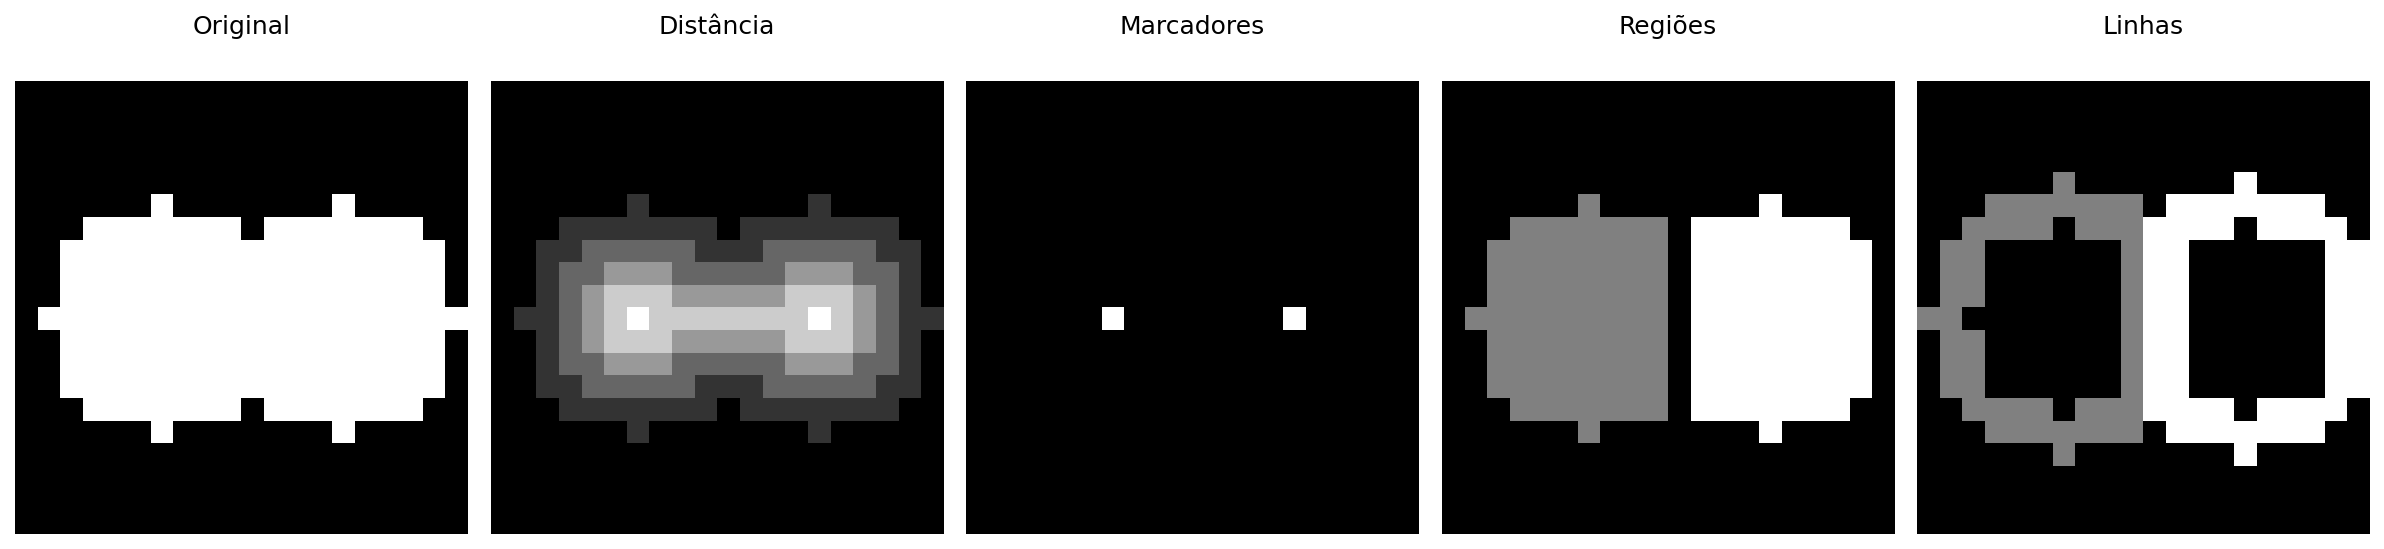

**Figura 4.25:** *Pipeline* *watershed* delimitado por máscara em imagem binária 20×20.


In [ ]:
import cv2

# 1. Imagem sintética e Transformada de Distância
f_sint = np.zeros((20, 20), dtype=np.uint8)
cv2.circle(f_sint, (6,  10), 5, 255, -1)
cv2.circle(f_sint, (14, 10), 5, 255, -1)
dist = mm.dist(f_sint)

# 2. Marcadores (picos da distância)
m = (dist > 0.8 * dist.max()).astype(np.uint8) * 255

# 3. Execução do Watershed0 condicional (m=marcadores primeiro, mask=f_sint)
w_reg  = mm.watershed0(m, mask=f_sint, op='region')
w_line = mm.watershed0(m, mask=f_sint, op='line')

#w_reg  = mm.watershedB(m, mask=f_sint, op='region')
#w_line = mm.watershedB(m, mask=f_sint, op='line')

w_reg  = mm.watershed(m, mask=f_sint, op='region')
w_line = mm.watershed(m, mask=f_sint, op='line')

# 4. Exibição dos resultados
mm.show([f_sint, dist, m, w_reg, w_line], cols=5, figsize=(16, 4),
        titles=["Original", "Distância", "Marcadores", "Regiões", "Linhas"])

**Aplicação em moedas sobrepostas:**

Objetos detectados: 12


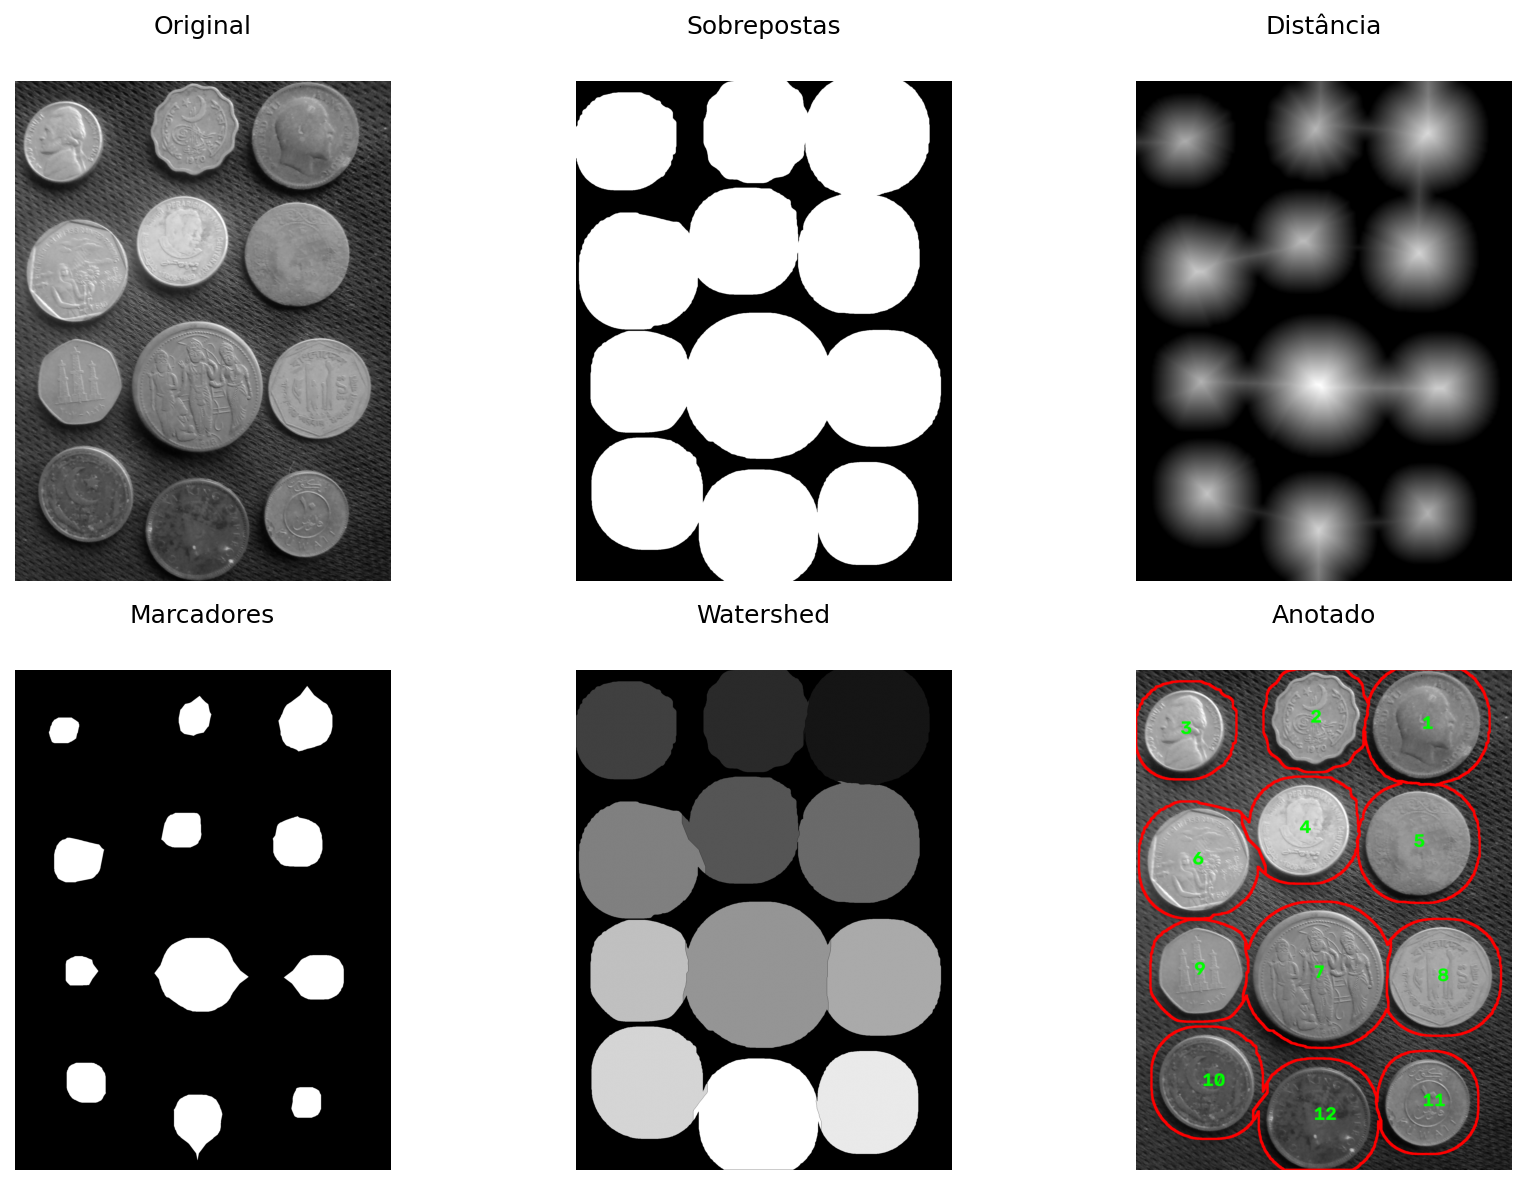

**Figura 4.26:** *Pipeline* *Watershed* para separação de moedas sobrepostas: da máscara binária dilatada até os contornos finais anotados sobre a imagem original.


In [ ]:
img_base = img_coins_gray

# 1. Simular moedas sobrepostas/conectadas (usando a máscara binária base)
img_sobrepostas = mm.dil(img_final, mm.sebox(40))

# 2. Abertura morfológica para limpar ruídos
opening = mm.open(img_sobrepostas, mm.sebox(2))

# 3. Transformada de Distância
dist = mm.dist(opening)
dist_vis=(255*(dist/dist.max())).astype(np.uint8) if dist.max() > 0 else dist.astype(np.uint8)

# 4. Picos seguros (Marcadores das moedas)
picos = (dist > 0.5 * dist.max()).astype(np.uint8) * 255

# 5. Execução do Watershed (Ajustado para usar a nova assinatura)
# Passamos 'opening' direto em mask, pois ela delimita o escopo de expansão das moedas
ws_region = mm.watershed(picos, mask=opening, op='region')
ws_line   = mm.watershed(picos, mask=opening, op='line')

# 6. Contagem de objetos (Ignora fundo 0)
labels = np.unique(ws_region)
labels = labels[labels > 0]
print(f"Objetos detectados: {len(labels)}")

# 7. Anotação Final
img_annotated = cv2.cvtColor(img_base, cv2.COLOR_GRAY2BGR)

for idx, label_id in enumerate(labels):
    mask_reg = (ws_region == label_id).astype(np.uint8)
    if mask_reg.sum() < 500: continue
    
    cy, cx = np.mean(np.where(mask_reg), axis=1).astype(int)
    cv2.putText(img_annotated, str(idx + 1), (cx - 25, cy + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 3.2, (0, 255, 0), 8, cv2.LINE_AA)

# Desenha as linhas de separação em vermelho
mask_ann = mm.dil(ws_line, np.ones((11, 11), np.uint8))
img_annotated[mask_ann > 0 ] = [255, 0, 0]

# Exibição
mm.show(
    [img_base, img_sobrepostas, dist_vis, picos, ws_region, img_annotated],
    titles=["Original", "Sobrepostas", "Distância", "Marcadores", "Watershed", "Anotado"],
    cols=3, rows=2, figsize=(12, 8)
)

## 4.5 Extração de Componentes e Descritores de Forma

Após a segmentação e o refinamento morfológico, o próximo passo consiste em identificar individualmente cada objeto presente na imagem e extrair suas propriedades geométricas. Essa etapa é fundamental para tarefas de medição, classificação e reconhecimento de padrões.

Um **componente conexo** é um conjunto maximal de pixels pertencentes ao objeto que permanecem mutuamente conectados segundo uma relação de conectividade previamente definida (4- ou 8-conectividade). Após a rotulação, cada componente recebe um identificador único, permitindo que suas características sejam analisadas individualmente.

O OpenCV oferece duas abordagens complementares para essa análise, resumidas na [Tabela 4.8](#tbl-04-componentes-vs-contornos).

<a id="tbl-04-componentes-vs-contornos"></a>

**Tabela 4.8:** Comparação entre as abordagens baseadas em componentes conexos e em contornos.

| | `connectedComponentsWithStats` | `findContours` |
|---|---|---|
| **Retorna** | rótulo por pixel e estatísticas por componente | sequência de pontos que descreve a borda |
| **Descritores diretos** | área, *bounding box* e centróide | perímetro, forma e hierarquia |
| **Objetos em contato** | tende a fundir regiões conectadas | tende a produzir um único contorno externo |
| **Uso típico** | contagem, filtragem e rotulação | análise geométrica e descritores de forma |


### 4.5.1 Rotulação e Estatísticas de Componentes

A função `cv2.connectedComponentsWithStats` realiza simultaneamente a rotulação dos componentes conexos e a extração de descritores básicos de cada região. O operador retorna:

- uma imagem de rótulos (`labels`);
- estatísticas geométricas (`stats`);
- coordenadas dos centróides (`centroids`).

As estatísticas incluem área, largura, altura e posição da *bounding box* mínima alinhada aos eixos da imagem.

A [Figura 4.27](#fig-04-componentes) ilustra a aplicação desse operador após o *pipeline* de segmentação das moedas. Cada componente conexo recebe uma cor distinta e sua área é anotada diretamente sobre a imagem.

Componentes detectados (excluindo fundo): 12

  ID     Área     cx     cy      w      h
------------------------------------------
   1   231969   1484    280    553    542
   2   158967    917    250    453    468
   3   139229    250    312    433    419
   4   175550    857    821    474    465
   5   222882   1442    889    539    531
   6   210043    316    977    527    516
   7   343376    934   1559    667    665
   8   213641   1555   1574    530    515
   9   147880    328   1543    432    438
  10   187280    363   2111    487    492
  11   150110   1487   2215    433    444
  12   215387    932   2292    528    522


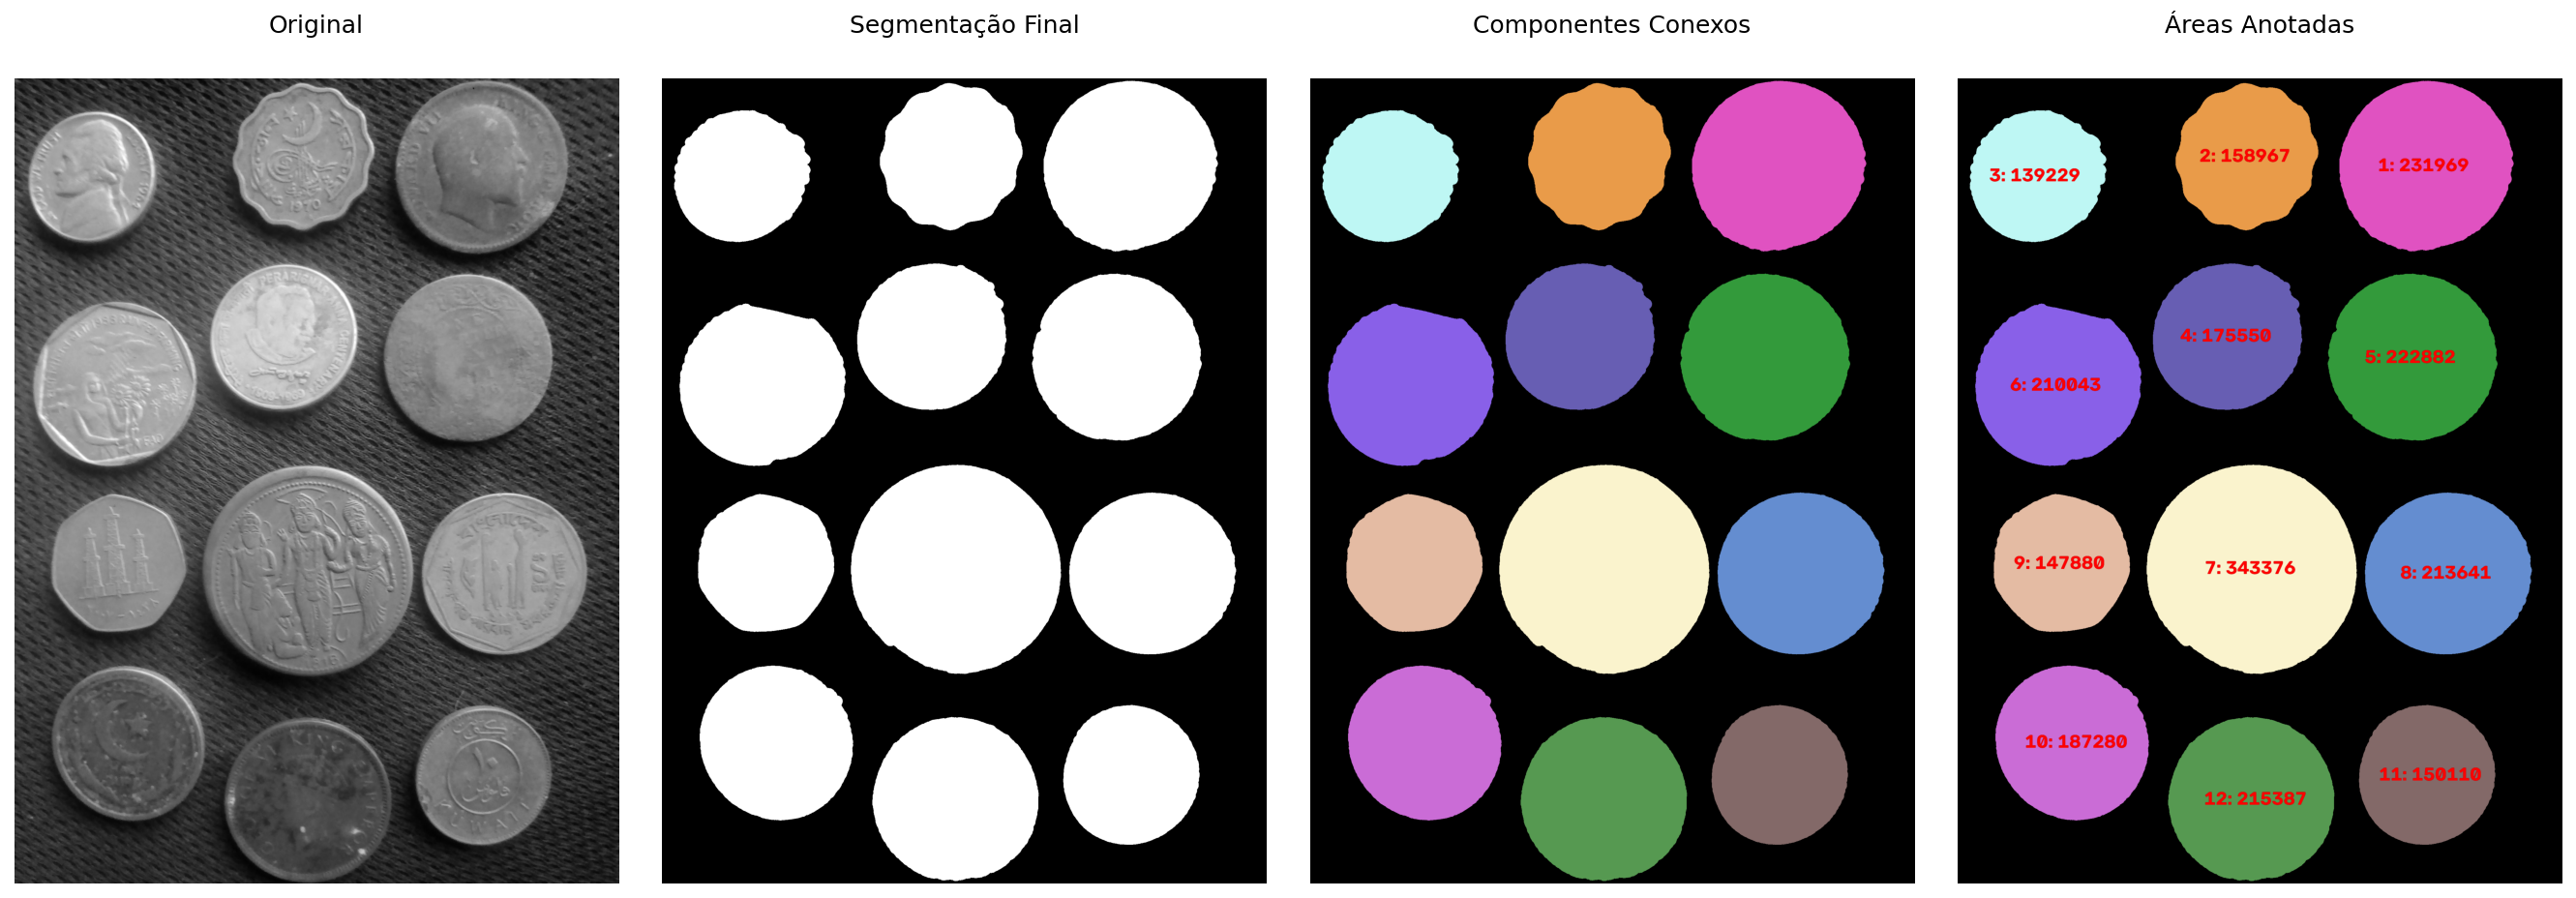

**Figura 4.27:** Componentes conexos extraídos após o *pipeline* CLAHE → Otsu → limpeza morfológica. Cada objeto é colorido com cor distinta e anotado com sua área em pixels.


In [ ]:
# 1. Rotulagem e estatísticas
n, labels, stats, centroids = cv2.connectedComponentsWithStats(
    img_final, connectivity=8
)

# 2. Coloração dos componentes
np.random.seed(4)
colors    = np.random.randint(50, 255, (n, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]                          # fundo preto
img_colored   = colors[labels]
img_annotated = img_colored.copy()

# 3. Tabela de descritores
print(f"Componentes detectados (excluindo fundo): {n - 1}")
print(f"\n{'ID':>4} {'Área':>8} {'cx':>6} {'cy':>6} {'w':>6} {'h':>6}")
print("-" * 42)
for i in range(1, n):
    area = stats[i, cv2.CC_STAT_AREA]
    cx, cy = int(centroids[i, 0]), int(centroids[i, 1])
    w, h   = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
    print(f"{i:>4} {area:>8} {cx:>6} {cy:>6} {w:>6} {h:>6}")
    for cor, esp in [((0,0,0), 10), ((255,0,0), 5)]:
        cv2.putText(img_annotated, f"{i}: {area}",
                    (cx - 150, cy + 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.0, cor, esp, cv2.LINE_AA)

mm.show(
    [img_coins_gray, img_final, img_colored, img_annotated],
    titles=["Original", "Segmentação Final", "Componentes Conexos", "Áreas Anotadas"],
    cols=4, figsize=(18, 6)
)

### 4.5.2 Descritores de Forma

Enquanto `connectedComponentsWithStats` opera sobre regiões, `cv2.findContours` atua diretamente sobre suas fronteiras. O operador retorna, para cada objeto, uma sequência ordenada de pontos que descreve seu contorno.

A partir dessa representação é possível calcular descritores geométricos que não são fornecidos diretamente pela rotulação de componentes:

- **Área** (`cv2.contourArea`)

- **Perímetro** (`cv2.arcLength`);

- **Circularidade** ($C = \frac{4\pi A}{P^2}$, onde $A$ é a área e $P$ o perímetro);

- **Aproximação poligonal** (`cv2.approxPolyDP`);

- **Fecho convexo** (*convex hull*);

- **Hierarquia de contornos**, permitindo representar relações pai-filho entre regiões e seus buracos internos.

A circularidade assume valor máximo igual a 1 para um círculo perfeito e diminui à medida que o objeto se torna mais alongado ou apresenta irregularidades em sua borda.

A [Figura 4.28](#fig-04-contornos) apresenta os contornos extraídos das moedas segmentadas, juntamente com os valores de circularidade calculados para cada objeto.

Contornos detectados: 12

  ID     Área  Perímetro  Circularidade
------------------------------------------
   1   214626     1769.6          0.861
   2   149480     1465.1          0.875
   3   186570     1654.9          0.856
   4   147252     1458.6          0.870
   5   212886     1756.3          0.867
   6   342424     2232.5          0.863
   7   209282     1767.7          0.842
   8   222108     1809.7          0.852
   9   174854     1616.4          0.841
  10   138602     1471.5          0.804
  11   158306     1538.7          0.840
  12   231181     1847.4          0.851


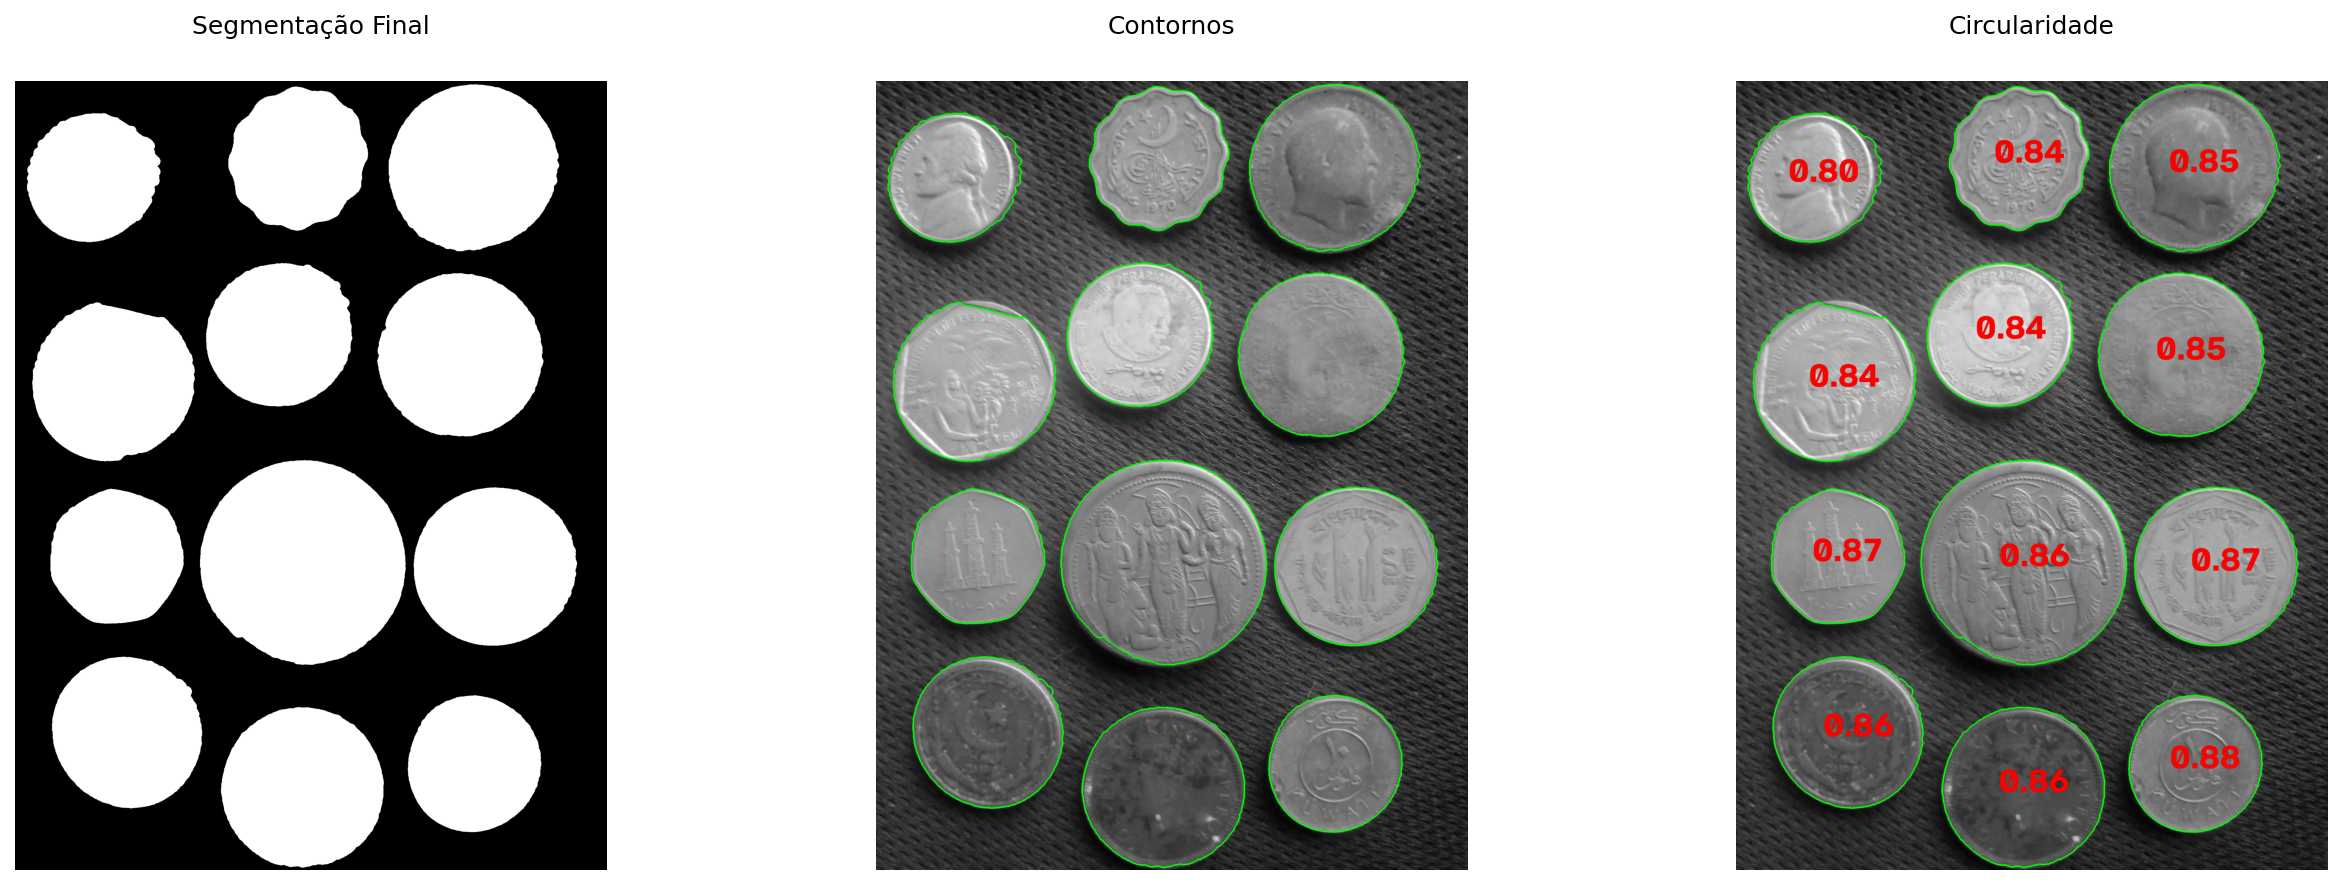

**Figura 4.28:** Contornos extraídos com *findContours*. Cada moeda é anotada com sua circularidade — valores próximos de 1 confirmam forma circular.


In [ ]:
contornos, hierarquia = cv2.findContours(
    img_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

img_contornos  = cv2.cvtColor(img_coins_gray, cv2.COLOR_GRAY2BGR)
img_circulares = img_contornos.copy()

print(f"Contornos detectados: {len(contornos)}")
print(f"\n{'ID':>4} {'Área':>8} {'Perímetro':>10} {'Circularidade':>14}")
print("-" * 42)

for i, cnt in enumerate(contornos, start=1):
    area  = cv2.contourArea(cnt)
    perim = cv2.arcLength(cnt, closed=True)
    circ  = (4 * np.pi * area / perim**2) if perim > 0 else 0
    M     = cv2.moments(cnt)
    cx    = int(M["m10"] / M["m00"]) if M["m00"] > 0 else 0
    cy    = int(M["m01"] / M["m00"]) if M["m00"] > 0 else 0

    print(f"{i:>4} {area:>8.0f} {perim:>10.1f} {circ:>14.3f}")

    cv2.drawContours(img_contornos,  [cnt], -1, (0, 255, 0), 3)
    cv2.drawContours(img_circulares, [cnt], -1, (0, 255, 0), 3)
    for cor, esp in [((0,0,0), 8), ((255,0,0), 3)]:
        cv2.putText(img_circulares, f"{circ:.2f}",
                    (cx - 80, cy + 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 3.6, cor, esp, cv2.LINE_AA)

mm.show(
    [img_final, img_contornos, img_circulares],
    titles=["Segmentação Final", "Contornos", "Circularidade"],
    cols=3, figsize=(18, 6)
)

### 4.5.3 Conexão com Detecção de Objetos Moderna

Os descritores extraídos nas seções anteriores — especialmente *bounding boxes*, centróides, áreas e medidas de forma — estabelecem uma ponte natural entre a segmentação morfológica clássica e os sistemas modernos de detecção de objetos. Embora as técnicas estudadas neste capítulo utilizem operações sobre pixels e regiões segmentadas, muitas das representações produzidas são diretamente compatíveis com os formatos empregados em modelos contemporâneos de visão computacional.

Detectores baseados em aprendizado profundo, como a família YOLO (*You Only Look Once*) (REDMON et al., 2016), operam diretamente sobre imagens coloridas e produzem, para cada objeto detectado, uma *bounding box* descrita pelo centro $(cx,cy)$ e pelas dimensões $(w,h)$, além de uma classe e uma pontuação de confiança. Essa representação compartilha a mesma estrutura geométrica básica obtida por `connectedComponentsWithStats`, embora seja produzida por um modelo aprendido e não por segmentação explícita.

A [Figura 4.29](#fig-04-bbox) ilustra como as *bounding boxes* obtidas por morfologia podem ser exportadas no formato YOLO para compor conjuntos de dados utilizados no treinamento ou na avaliação de detectores.

 cls     cx_n     cy_n      w_n      h_n  ← formato YOLO
------------------------------------------------------
   0   0.7753   0.1102   0.2880   0.2117
   0   0.4784   0.0984   0.2359   0.1828
   0   0.1331   0.1225   0.2255   0.1637
   0   0.4464   0.3217   0.2469   0.1816
   0   0.7523   0.3471   0.2807   0.2074
   0   0.1664   0.3812   0.2745   0.2016
   0   0.4862   0.6104   0.3474   0.2598
   0   0.8115   0.6154   0.2760   0.2012
   0   0.1724   0.6023   0.2250   0.1711
   0   0.1893   0.8258   0.2536   0.1922
   0   0.7763   0.8652   0.2255   0.1734
   0   0.4854   0.8953   0.2750   0.2039

Anotação salva em moedas.txt


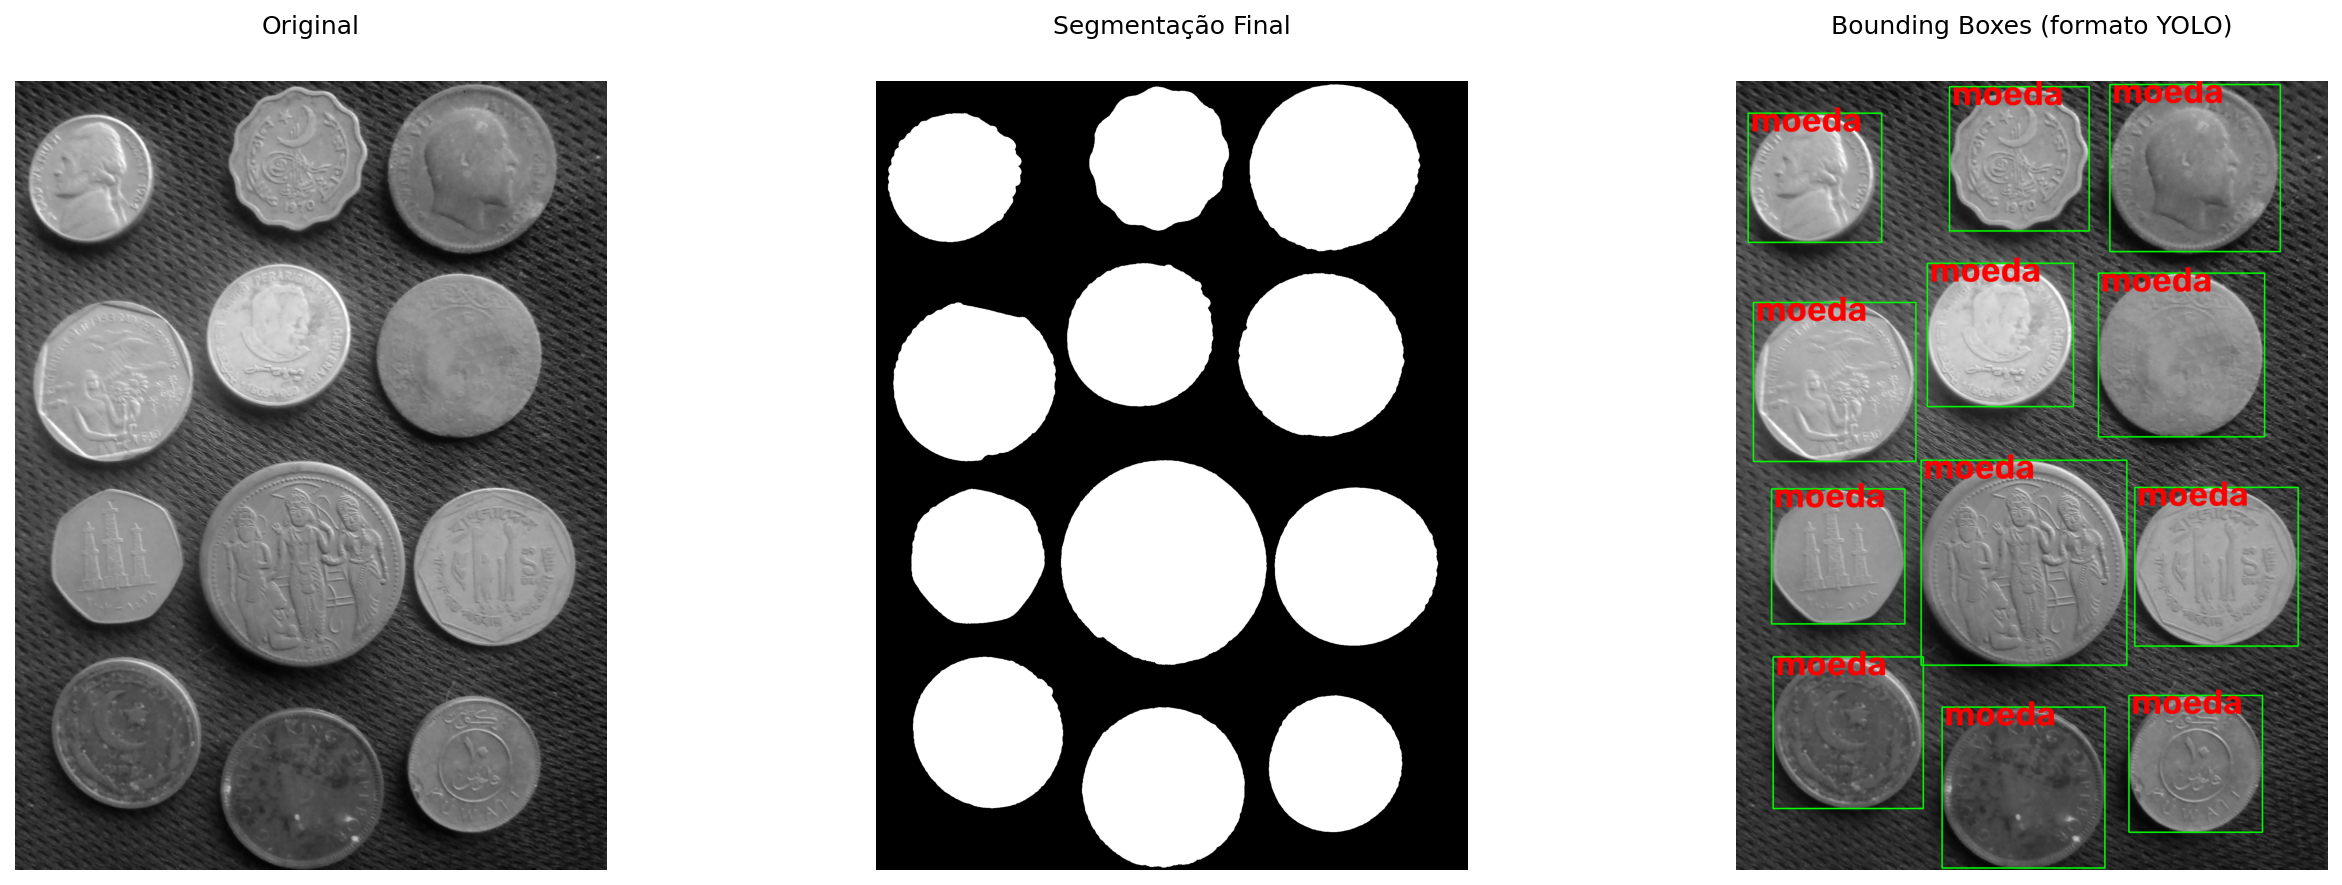

**Figura 4.29:** *Bounding boxes* derivadas dos componentes conexos sobrepostas à imagem original. As anotações são exportadas no formato YOLO (*classe cx cy w h*), com coordenadas normalizadas para o intervalo [0,1].


In [ ]:
H_img, W_img = img_coins_gray.shape
img_bbox = cv2.cvtColor(img_coins_gray, cv2.COLOR_GRAY2BGR)

CLASSE = 0   # 0 = moeda (única categoria neste exemplo)

print(f"{'cls':>4} {'cx_n':>8} {'cy_n':>8} {'w_n':>8} {'h_n':>8}  ← formato YOLO")
print("-" * 54)

yolo_linhas = []
for i in range(1, n):
    x0 = stats[i, cv2.CC_STAT_LEFT]
    y0 = stats[i, cv2.CC_STAT_TOP]
    w  = stats[i, cv2.CC_STAT_WIDTH]
    h  = stats[i, cv2.CC_STAT_HEIGHT]

    cx_n = (x0 + w / 2) / W_img
    cy_n = (y0 + h / 2) / H_img
    w_n  = w / W_img
    h_n  = h / H_img

    yolo_linhas.append(f"{CLASSE} {cx_n:.4f} {cy_n:.4f} {w_n:.4f} {h_n:.4f}")
    print(f"{CLASSE:>4} {cx_n:>8.4f} {cy_n:>8.4f} {w_n:>8.4f} {h_n:>8.4f}")

    cv2.rectangle(img_bbox, (x0, y0), (x0 + w, y0 + h), (0, 255, 0), 4)
    cv2.putText(img_bbox, f"moeda", (x0 + 8, y0 + 60),
                cv2.FONT_HERSHEY_SIMPLEX, 3.8, (255, 0, 0), 5, cv2.LINE_AA)

# Exportar arquivo de anotação no formato YOLO
with open("moedas.txt", "w") as f:
    f.write("\n".join(yolo_linhas))
print("\nAnotação salva em moedas.txt")

mm.show(
    [img_coins_gray, img_final, img_bbox],
    titles=["Original", "Segmentação Final", "Bounding Boxes (formato YOLO)"],
    cols=3, figsize=(18, 6)
)

O formato YOLO armazena cada objeto em uma linha contendo cinco campos:

$$
\texttt{classe}\;\;\texttt{cx}\;\;\texttt{cy}\;\;\texttt{w}\;\;\texttt{h}
$$

onde $(cx,cy)$ representa o centro da *bounding box* e $(w,h)$ suas dimensões. Todos os valores geométricos são normalizados para o intervalo $[0,1]$ em relação à largura e à altura da imagem. A **classe** é um identificador inteiro associado a uma categoria definida pelo conjunto de dados (por exemplo, `0 → moeda`). Quando há múltiplas categorias — como moeda de ouro (`0`), moeda de prata (`1`) e disco plástico (`2`) — basta atribuir o identificador correspondente a cada objeto antes da exportação, mantendo exatamente o mesmo formato de anotação. No exemplo anterior, essas informações foram armazenadas no arquivo `moedas.txt`.

O fluxo apresentado neste capítulo — segmentação → rotulação → extração de *bounding boxes* — corresponde conceitualmente à etapa de **anotação** (*labeling*) empregada na construção de conjuntos de treinamento para detectores modernos. Ferramentas especializadas, como Label Studio e Roboflow, automatizam esse processo em imagens complexas, mas a lógica fundamental permanece a mesma: associar a cada objeto uma região de interesse e uma classe. Em cenários controlados, com fundo uniforme e objetos bem separados, técnicas morfológicas podem inclusive gerar anotações automaticamente ou servir como ponto de partida para a rotulação manual, reduzindo significativamente o esforço de construção do conjunto de dados. Em aplicações reais mais complexas, entretanto, a validação humana continua sendo necessária para garantir a qualidade das anotações.

> ### 📝 Avaliação: IoU (*Intersection over Union*)
>
> Uma forma simples de avaliar a qualidade de uma segmentação consiste em compará-la com uma máscara de referência (*ground truth*). A métrica mais utilizada para essa finalidade é a **IoU** (*Intersection over Union*):
>
> <a id="eq-04-iou"></a>
$$
> \text{IoU}=
> \frac{|A\cap B|}
> {|A\cup B|}
> \tag{4.16}
$$

>
> onde $A$ representa a segmentação produzida pelo algoritmo e $B$ a segmentação de referência.
>
> O valor da IoU varia entre 0 e 1. Quanto maior o valor, maior a sobreposição entre as máscaras. Uma IoU igual a 1 indica correspondência perfeita entre a segmentação obtida e a referência.
>
> A mesma métrica também é amplamente utilizada em detecção de objetos, sendo aplicada às *bounding boxes* previstas e anotadas. Nessa área, valores de IoU superiores a 0,5 são frequentemente adotados como critério mínimo para considerar uma detecção correta.

> ### 💡 Além da Morfologia
>
> As técnicas estudadas neste capítulo segmentam objetos explorando conectividade espacial, operações morfológicas e relevo topográfico. Existem, entretanto, abordagens alternativas baseadas em agrupamento de características, como o algoritmo *k-means*, modelos de mistura Gaussiana (GMM) e métodos mais recentes baseados em aprendizado profundo. Essas técnicas serão retomadas na Parte II do livro, dedicada à Visão Computacional.

## 4.6 Resumo

Neste capítulo foram apresentadas as principais técnicas de segmentação e morfologia matemática, concluindo o estudo do PDI no domínio espacial.

* **Pré-processamento e limiarização:** A combinação entre equalização adaptativa CLAHE e o método de Otsu mostrou-se eficaz para induzir separação bimodal no histograma e simplificar a binarização de imagens com iluminação não uniforme.
* **Erosão e dilatação:** Operadores morfológicos fundamentais baseados na busca por mínimos e máximos locais em uma vizinhança definida pelo elemento estruturante $B$. São operadores duais pelo complemento e foram implementados por meio das funções `mm.ero` e `mm.dil`.
* **Abertura e fechamento:** Composições de erosão e dilatação que permitem remover ruídos, suavizar contornos e preencher pequenas lacunas, preservando a estrutura global dos objetos.
* **Reconstrução morfológica:** Processo geodésico iterativo que propaga um marcador dentro dos limites impostos por uma máscara, constituindo a base de operadores como `mm.clohole` e `mm.edgeoff`.
* **Pipeline de limpeza binária:** Fluxo consolidado composto por CLAHE → Otsu → abertura → `mm.clohole` → abertura restrita → `mm.edgeoff`, produzindo máscaras adequadas para análise quantitativa.
* **Morfologia em tons de cinza:** Extensão algébrica baseada em mínimos e máximos ponderados, viabilizando operadores como gradiente morfológico e filtros *top-hat* para realce de estruturas locais.
* **Transformada de Distância e Watershed:** A Transformada de Distância permitiu gerar marcadores automáticos para o algoritmo *watershed*, possibilitando a separação de objetos adjacentes ou parcialmente sobrepostos.
* **Componentes conexos e descritores:** A rotulação de regiões (`cv2.connectedComponentsWithStats`) e a extração de contornos (`cv2.findContours`) permitiram calcular descritores geométricos como área, centróide, perímetro, circularidade e *bounding boxes*.
* **Conexão com Visão Computacional Moderna:** As *bounding boxes* extraídas por morfologia foram exportadas no formato YOLO, evidenciando a ligação entre técnicas clássicas de segmentação e sistemas modernos de detecção de objetos.

O Capítulo 5 introduzirá técnicas de processamento no **domínio da frequência**, abordando a **Transformada de Fourier**, filtragem espectral e os fundamentos da **compressão de imagens**, incluindo DCT, JPEG e *wavelets*.

## 4.7 🤖 Uso do Gemini Notebook como Tutor Complementar

Nesta edição, o uso do **Gemini Notebook** é incentivado como ferramenta complementar de aprendizagem. Baseado em inteligência artificial, o sistema utiliza exclusivamente os documentos fornecidos pelo autor como fonte de conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem adotada ao longo deste capítulo.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR Gemini Notebook: CAPÍTULO 04](https://notebooklm.google.com/notebook/5dafcbfa-ad58-44f9-9707-4f761b0a6c70)
>
> #### 🌐 Idioma e Linguagem de Programação
>
> O projeto deste capítulo no Gemini Notebook foi construído apenas com o texto em **português** e os exemplos de código em **Python**. Se você está estudando pela edição em inglês ou francês, ou acompanhando a trilha em C++, as respostas do tutor podem não corresponder exatamente à versão que você está lendo.
>
> #### ⚠️ Aviso sobre Conteúdo Gerado por IA
>
> Embora seja uma ferramenta valiosa de apoio aos estudos, o Gemini Notebook pode eventualmente produzir respostas incompletas, imprecisas ou incorretas. Recomenda-se validar as informações consultando o material do capítulo, livros, artigos científicos e outras fontes acadêmicas confiáveis. Sempre que possível, execute e experimente os exemplos práticos apresentados ao longo do texto para consolidar a compreensão dos conceitos.

## 4.8 Lista de Exercícios

1. **(10%)** Implemente manualmente o critério de Otsu sem utilizar `cv2.threshold`. Calcule a variância interclasses $\sigma_B^2(T)$ para todos os limiares $T \in [0,255]$ usando `mm.hist`, identifique o limiar ótimo $T^*$ e compare o resultado com o valor obtido pelo OpenCV. Plote $\sigma_B^2$ em função de $T$ e destaque o ponto de máximo.

2. **(15%)** Aplique limiarização adaptativa com blocos de tamanho 11, 31 e 51 a uma imagem contendo iluminação não uniforme. Compare os resultados com a limiarização global de Otsu e discuta as vantagens e limitações de cada abordagem.

3. **(15%)** Execute o *pipeline watershed* da imagem de moedas variando o limiar aplicado à Transformada de Distância ($0.3$, $0.5$ e $0.7$ vezes o valor máximo). Explique como esse parâmetro influencia a geração dos marcadores, a separação de objetos adjacentes e a ocorrência de sobre-segmentação.

4. **(15%)** Utilizando `mm.drawImg`, construa uma demonstração visual passo a passo da erosão de uma imagem binária 7×7 com elemento estruturante quadrado 3×3. Para cada posição analisada, indique se o elemento estruturante está completamente contido no objeto e justifique o valor atribuído ao pixel de saída.

5. **(15%)** Demonstre experimentalmente a dualidade entre erosão e dilatação verificando a identidade $(A \ominus B)^c = A^c \oplus \hat{B}$
   utilizando `mm.ero`, `mm.dil` e `mm.bnot`. Calcule a diferença pixel a pixel entre os dois lados da equação e apresente o resultado utilizando `mm.histImg` ou visualização equivalente.

6. **(15%)** Implemente manualmente o gradiente morfológico utilizando apenas `mm.ero` e `mm.dil`, comparando o resultado com `cv2.morphologyEx(img, cv2.MORPH_GRADIENT, B)`. Avalie o efeito de diferentes elementos estruturantes (quadrado 3×3, disco 5×5 e linha 1×9) sobre a detecção de bordas.

7. **(15%)** Construa um *pipeline* completo para contagem e classificação de moedas por tamanho (pequena, média e grande) utilizando área e circularidade como descritores. Gere uma máscara de referência (*ground truth*) manualmente e calcule a métrica IoU (*Intersection over Union*) para avaliar a qualidade da segmentação. Apresente os resultados em tabela e por meio de visualizações produzidas com `mm.show`.

## Referências do Capítulo


A fundamentação teórica deste capítulo baseia-se nas seguintes obras:
* Gonzalez e Woods (2018) para os conceitos de segmentação, limiarização de Otsu, Transformada de Distância, *watershed*, morfologia matemática e descritores de forma.
* Matheron (1975) e Serra (1982) para a fundamentação teórica original, formulação algébrica e desenvolvimento da Morfologia Matemática.
* Szeliski (2022) para segmentação baseada em regiões, rotulação de componentes conexos, *watershed* baseado em marcadores e avaliação de segmentação por meio da métrica IoU.
* Bradski e Kaehler (2008) para a utilização prática da biblioteca OpenCV, incluindo funções como `cv2.distanceTransform`, `cv2.watershed`, `cv2.connectedComponentsWithStats` e `cv2.findContours`.
* Redmon et al. (2016) para a introdução aos detectores modernos da família YOLO e sua relação com descritores geométricos como *bounding boxes* extraídas por segmentação.
* Singh et al. (2024) para a construção de labirintos complexos baseados em ciclos hamiltonianos sobre mosaicos quasicristalinos, utilizados como exemplo de aplicação da Transformada de Distância Geodésica e de algoritmos de busca de caminhos.
* Zampirolli et al. (2025) para a implementação dos operadores morfológicos, transformadas geodésicas e resolução de labirintos por propagação de distâncias em domínios restritos.

BRADSKI, Gary; KAEHLER, Adrian. **Learning OpenCV: Computer vision with the OpenCV library**. " O'Reilly Media, Inc.", 2008.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

LOTUFO, R.A.; ZAMPIROLLI, F.A. **Fast multidimensional parallel Euclidean distance transform based on mathematical morphology**. 2001.

MATHERON, G. **Random Sets and Integral Geometry**. New York, John Wiley \& Sons, 1975.

REDMON, Joseph *et al*. **You Only Look Once: Unified, Real-Time Object Detection**. 2016.

SERRA, Jean. **Image Analysis and Mathematical Morphology**. London, Academic Press, 1982.

SINGH, S.; LLOYD, J.; FLICKER, F. **Hamiltonian Cycles on Ammann-Beenker Tilings**. 2024.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

ZAMPIROLLI, Francisco de Assis *et al*. **Teaching Hands-On Digital Image Processing with morph.py: Methods and Comprehensive Results**. 2025.

*Referência não encontrada para: staticmethod*